✅  Saved plot (no legend): /Users/yannik/Documents/Uni/Oxford/PhD/prism_convex/prism/prism/plotting_paper/plots/BETTING_GAME_CONVEX/n=10,p=0.55/BETTING_GAME_CONVEX_n=10,p=0.55.pdf
✅  Saved runtime plot: /Users/yannik/Documents/Uni/Oxford/PhD/prism_convex/prism/prism/plotting_paper/plots/BETTING_GAME_CONVEX/n=10,p=0.55/BETTING_GAME_CONVEX_n=10,p=0.55_runtime.pdf
✅  Saved runtime (processed episodes) plot: /Users/yannik/Documents/Uni/Oxford/PhD/prism_convex/prism/prism/plotting_paper/plots/BETTING_GAME_CONVEX/n=10,p=0.55/BETTING_GAME_CONVEX_n=10,p=0.55_runtime_processed.pdf
✅  Saved legend: /Users/yannik/Documents/Uni/Oxford/PhD/prism_convex/prism/prism/plotting_paper/plots/BETTING_GAME_CONVEX/n=10,p=0.55/BETTING_GAME_CONVEX_n=10,p=0.55_legend.pdf
✅  Saved plot (no legend): /Users/yannik/Documents/Uni/Oxford/PhD/prism_convex/prism/prism/plotting_paper/plots/BETTING_GAME_CONVEX/n=150,p=0.55/BETTING_GAME_CONVEX_n=150,p=0.55.pdf
✅  Saved runtime plot: /Users/yannik/Documents/Uni/Oxford/PhD/

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator, LogLocator, MaxNLocator
from pathlib import Path

# ─── (0) GLOBAL STYLING VIA rcParams ────────────────────────────────────────
plt.rcParams.update({
    'text.usetex': True,
    'text.latex.preamble': r'\usepackage{amsmath,amssymb}',
    # Serif font (Times New Roman preferred)
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Times', 'DejaVu Serif', 'Serif'],
    # Base font size (will be overridden for labels/ticks below)
    'font.size': 12,
    'axes.titlesize': 16,
    'axes.labelsize': 16,
    # Tick styling
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 8,
    'ytick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.minor.size': 4,
    'xtick.major.width': 1.2,
    'ytick.major.width': 1.2,
    'xtick.minor.width': 1.0,
    'ytick.minor.width': 1.0,
    # Axis line width
    'axes.linewidth': 1.5,
    # Legend
    'legend.fontsize': 14,
    'legend.frameon': True,
    'legend.framealpha': 0.8,
    'legend.fancybox': True,
    # Grid
    'axes.grid': True,
    'grid.color': '#bbbbbb',
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    # Savefig (explicit DPI in code too)
    'savefig.format': 'pdf',
    'savefig.bbox': 'standard',
    'mathtext.fontset': 'stix',      # STIX looks like Times
    'mathtext.default': 'regular',   # not italic by default
})

# ─── (1) PATH CONFIGURATION ───────────────────────────────────────────────────
input_root = Path('/Users/yannik/Documents/Uni/Oxford/PhD/prism_convex/prism/prism/plotting_paper_with_ellipsoids/results_learning/parametric_convex')
if not input_root.exists():
    raise FileNotFoundError(f"No such folder: {input_root}")

output_root = input_root / "plots"
output_root.mkdir(parents=True, exist_ok=True)

# ─── (2) PLOTTING PARAMETERS ───────────────────────────────────────────────────
FIGSIZE     = (7.4, 5.2)         # Slightly shorter along y
DPI         = 300               # High DPI for crisp output
LIGHTRED      = '#F1E1DE'
OFFWHITE      = '#FBF4EC'
AZURE         = '#F0FFFF'
ANTIQUEWHITE  = '#FAEBD7'
BRICKRED      = '#A63A2B'
COLOR1        = '#D58E63'
ALIZARIN      = '#D96B4D'
PIGMENT       = '#7C4A21'
FALLBACK_COLORS = ['#7A6A58', '#6E7F80', '#8C6F5E', '#6D6488']
ALGO_STYLES = {
    'imdp_full':        {'label': '$\\mathcal{P}_I$', 'color': COLOR1, 'fill': '#F4DDD1'},
    'lpinterval_exact': {'label': '$\\mathcal{P}_{\\Lambda(\\mathcal{U})}$', 'color': BRICKRED, 'fill': LIGHTRED},
    'lpinterval_fast':  {'label': '$\\mathcal{P}_{\\Theta(\\mathcal{U})}$', 'color': ALIZARIN, 'fill': '#F2D6CD'},
    'parconvex_full':   {'label': '$\\mathcal{P}_{R(\\mathcal{U})}$', 'color': PIGMENT, 'fill': '#F1DDB8'},
    'imdp_none':        {'label': 'IMDP', 'color': '#7A6A58', 'fill': ANTIQUEWHITE},
}
LINESTYLES  = {'performance': '-', 'guarantee': (0, (5, 2.2))}
LEGEND_RCPARAMS = {
    'text.usetex': True,
    'text.latex.preamble': r'\usepackage{amsmath,amssymb}',
    'font.family': 'serif',
    'font.serif': ['Computer Modern Roman', 'CMU Serif', 'Latin Modern Roman', 'DejaVu Serif'],
}
SHOW_INLINE = 0   # We will skip inline display to avoid low-res blurriness

# ─── (3) UTILITY TO FIND “performance” / “guarantee” COLUMNS ───────────────────
def canonical_algo_key(algo_name):
    u = algo_name.upper()
    if 'IMDP' in u and 'FULL_TYING' in u and 'NO_TYING' not in u:
        return 'imdp_full'
    if 'IMDP' in u and 'NO_TYING' in u:
        return 'imdp_none'
    if 'CPINTERVAL_EXACT' in u or 'LPINTERVAL_EXACT' in u:
        return 'lpinterval_exact'
    if 'CPINTERVAL_FAST' in u or 'LPINTERVAL_FAST' in u or 'LPINTERVAL_FAST)' in u:
        return 'lpinterval_fast'
    if 'PARCONVEX' in u and 'FULL_TYING' in u:
        return 'parconvex_full'
    return algo_name.lower()

def pretty_algo_label(algo_name):
    key = canonical_algo_key(algo_name)
    if key in ALGO_STYLES:
        return ALGO_STYLES[key]['label']
    return algo_name.replace('_', ' ')

def style_for_algo(algo_name, fallback_idx=0):
    key = canonical_algo_key(algo_name)
    if key in ALGO_STYLES:
        return ALGO_STYLES[key]
    return {
        'label': pretty_algo_label(algo_name),
        'color': FALLBACK_COLORS[fallback_idx % len(FALLBACK_COLORS)],
        'fill': OFFWHITE,
    }

def algo_sort_key(algo_name):
    order = {
        'imdp_full': 0,
        'lpinterval_exact': 1,
        'lpinterval_fast': 2,
        'parconvex_full': 3,
        'imdp_none': 4,
    }
    key = canonical_algo_key(algo_name)
    return (order.get(key, 100), pretty_algo_label(algo_name))

def value_ylabel(env_name):
    if env_name.startswith('AIRCRAFT'):
        return r'$\mathbb{P}(\neg\,\mathrm{crash}\,\mathsf{U}\,\mathrm{goal})$'
    if env_name == 'BETTING_GAME_PARALLEL':
        return r'$\mathbb{E}(\mathrm{F}^{=T}\,\mathrm{money})$'
    return 'Value'

def find_col(columns, *keywords):
    """
    Return the first column name that contains ALL of the given keywords (case‐insensitive).
    """
    for c in columns:
        low = c.lower()
        if all(kw.lower() in low for kw in keywords):
            return c
    return None

# ─── (3.5) INFINITY CAPS (tight, sign-aware, small extra space) ───────────────
def apply_infinity_caps(ax, y_min, y_max, has_pos_inf, has_neg_inf, inverted=False, log_scale=False,
                        finite_pad=1.03, cap_pad=1.08):
    """
    Tight limits to finite data + small padding. If ±∞ exist, extend only the
    corresponding side a little more and label that side with ∞ / −∞.
    """
    if log_scale:
        y_min = max(y_min, np.nextafter(0, 1))

        # small breathing room even without infinities
        low_lim  = y_min / finite_pad
        high_lim = y_max * finite_pad

        if has_pos_inf:
            next_dec = 10.0 ** np.ceil(np.log10(y_max))
            high_lim = min(y_max * cap_pad, next_dec / 1.001)
        if has_neg_inf:
            prev_dec = 10.0 ** np.floor(np.log10(y_min))
            low_lim  = max(y_min / cap_pad, prev_dec * 1.001)
    else:
        span = max(y_max - y_min, 1.0)
        low_lim  = y_min - (span * (finite_pad - 1.0))
        high_lim = y_max + (span * (finite_pad - 1.0))
        if has_pos_inf:
            high_lim = y_max + (span * (cap_pad - 1.0))
        if has_neg_inf:
            low_lim  = y_min - (span * (cap_pad - 1.0))

    # Apply limits (respect inversion)
    if not inverted:
        ax.set_ylim(low_lim, high_lim)
    else:
        ax.set_ylim(high_lim, low_lim)

    # Build tick labels with caps as needed (use scientific 10^k on log)
    ticks = [t for t in ax.get_yticks() if (min(low_lim, high_lim) < t < max(low_lim, high_lim))]

    def _fmt(t):
        if log_scale:
            k = np.log10(float(t))
            if abs(k - round(k)) < 1e-9:   # only exact decades -> 10^k
                return rf"$10^{int(round(k))}$"
            return f"{float(t):g}"
        return f"{t:g}"

    labels = [_fmt(t) for t in ticks]
    if has_neg_inf:
        ticks  = [low_lim] + ticks
        labels = ["−∞"] + labels
    if has_pos_inf:
        ticks  = ticks + [high_lim]
        labels = labels + ["∞"]

    ax.set_yticks(ticks)
    ax.set_yticklabels(labels)

# ─── (4) MAIN LOOP: ENV → PARAM → SEEDS → AGGREGATE & PLOT ─────────────────────
plot_count = 0

for env_dir in sorted(input_root.iterdir()):
    if not env_dir.is_dir():
        continue
    env_name = env_dir.name

    for param_dir in sorted(env_dir.iterdir()):
        if not param_dir.is_dir():
            continue
        param_name = param_dir.name

        seed_dirs = [d for d in sorted(param_dir.iterdir()) if d.is_dir()]
        if not seed_dirs:
            continue

        # 4a) Group CSVs by algo: combos[algo_name] = [list of seed CSV paths]
        combos = {}
        for seed_dir in seed_dirs:
            for csv_path in seed_dir.glob(f"{env_name}_*.csv"):
                stem = csv_path.stem
                prefix = env_name + "_"
                algo_name = stem[len(prefix):] if stem.startswith(prefix) else stem
                combos.setdefault(algo_name, []).append(csv_path)

        if not combos:
            continue

        # 4b) Create one high-DPI figure for this (env, param)
        fig, ax = plt.subplots(figsize=FIGSIZE, dpi=DPI)
        first_algo = True
        is_minimization = False

        # Collect for limits and deferred plotting (so we can paint ∞ as part of the line)
        finite_vals_all = []
        series = []  # dict(color, x, perf_mean, perf_std, guar_mean, guar_std, p_pos, p_neg, g_pos, g_neg)

        # 4c) Loop over each algorithm in this env/param
        for i, algo_name in enumerate(sorted(combos.keys(), key=algo_sort_key)):
            csv_list = sorted(combos[algo_name])
            if not csv_list:
                continue

            # (4c.i) Read seeds into raw_dfs
            raw_dfs = []
            perf_col = guar_col = None

            for csv_path in csv_list:
                df = pd.read_csv(csv_path).rename(columns=str.strip)
                if "Episode" not in df.columns:
                    raise KeyError(f"'Episode' column not found in {csv_path.name}")

                # map textual infinities to ±inf
                df = df.replace(
                    ["Infinity", "Inf", "inf", "+Inf", "-Inf", "+Infinity", "-Infinity"],
                    [np.inf, np.inf, np.inf, np.inf, -np.inf, np.inf, -np.inf],
                )

                df = df.sort_values("Episode").set_index("Episode")

                if perf_col is None and guar_col is None:
                    perf_col = find_col(df.columns, "performance")
                    guar_col = find_col(df.columns, "guarantee")
                    if perf_col is None or guar_col is None:
                        print(f"⚠️  Skipping '{algo_name}' under {env_name}/{param_name}: "
                              f"missing perf/guar columns in {csv_path.name}")
                        perf_col = guar_col = None

                if perf_col is None or guar_col is None:
                    raw_dfs = []
                    break

                raw_dfs.append(df[[perf_col, guar_col]])

            if not raw_dfs:
                continue

            # (4c.ii) Union of episodes
            all_eps = np.sort(np.unique(np.concatenate([df.index.values for df in raw_dfs])))
            num_eps = len(all_eps)
            num_seeds = len(raw_dfs)

            # Matrices for interpolation (NaN -> use nanmean/std)
            perf_mat = np.full((num_eps, num_seeds), np.nan, dtype=float)
            guar_mat = np.full((num_eps, num_seeds), np.nan, dtype=float)

            # Track where any seed had +∞ / −∞
            perf_pos_inf_any = np.zeros(num_eps, dtype=bool)
            perf_neg_inf_any = np.zeros(num_eps, dtype=bool)
            guar_pos_inf_any = np.zeros(num_eps, dtype=bool)
            guar_neg_inf_any = np.zeros(num_eps, dtype=bool)

            # (4c.iii) Interpolate per seed, ignoring non-finite
            for col_idx, df_seed in enumerate(raw_dfs):
                seed_x    = df_seed.index.values.astype(float)
                seed_perf = df_seed[perf_col].to_numpy(dtype=float)
                seed_guar = df_seed[guar_col].to_numpy(dtype=float)

                # record ±∞ by sign
                if np.any(~np.isfinite(seed_perf)):
                    perf_pos_inf_any |= np.isin(all_eps, seed_x[np.isposinf(seed_perf)])
                    perf_neg_inf_any |= np.isin(all_eps, seed_x[np.isneginf(seed_perf)])
                if np.any(~np.isfinite(seed_guar)):
                    guar_pos_inf_any |= np.isin(all_eps, seed_x[np.isposinf(seed_guar)])
                    guar_neg_inf_any |= np.isin(all_eps, seed_x[np.isneginf(seed_guar)])

                finite_p = np.isfinite(seed_perf)
                if finite_p.sum() >= 2:
                    perf_mat[:, col_idx] = np.interp(all_eps, seed_x[finite_p], seed_perf[finite_p], left=np.nan, right=np.nan)

                finite_g = np.isfinite(seed_guar)
                if finite_g.sum() >= 2:
                    guar_mat[:, col_idx] = np.interp(all_eps, seed_x[finite_g], seed_guar[finite_g], left=np.nan, right=np.nan)

            # (4c.iv) Aggregate
            perf_mean = np.nanmean(perf_mat, axis=1)
            perf_std  = np.nanstd (perf_mat, axis=1) * 0.5
            guar_mean = np.nanmean(guar_mat, axis=1)
            guar_std  = np.nanstd (guar_mat, axis=1)

            # collect finite values for tight limits
            if np.isfinite(perf_mean).any():
                finite_vals_all.append(perf_mean[np.isfinite(perf_mean)])
            if np.isfinite(guar_mean).any():
                finite_vals_all.append(guar_mean[np.isfinite(guar_mean)])

            # (4c.v) Minimization detection
            if first_algo:
                idx = np.where(np.isfinite(perf_mean))[0]
                if idx.size >= 2 and perf_mean[idx[-1]] < perf_mean[idx[0]]:
                    is_minimization = True
                first_algo = False

            style = style_for_algo(algo_name, i)
            display_label = style['label']

            series.append(dict(
                color=style['color'],
                fill_color=style['fill'],
                x=all_eps,
                perf_mean=perf_mean, perf_std=perf_std,
                guar_mean=guar_mean, guar_std=guar_std,
                p_pos=perf_pos_inf_any, p_neg=perf_neg_inf_any,
                g_pos=guar_pos_inf_any, g_neg=guar_neg_inf_any,
                legend_label=display_label,
                legend_label=display_label,
                label_perf=f"{display_label} Performance",
                label_guar=f"{display_label} Guarantee",
            ))

        # (5) FINALIZE AXES, GRID, LEGEND, TITLE
        ax.set_xscale("log")
        if env_name == 'BETTING_GAME_PARALLEL':
            ax.set_xlim(1e2, 1e5)
        #ax.set_yscale("log")
        # keep x logarithmic, but use readable linear y ticks
        ax.xaxis.set_major_locator(LogLocator(base=10, subs=(1.0,), numticks=100))
        ax.xaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2,10)*0.1, numticks=100))
        ax.yaxis.set_major_locator(MaxNLocator(nbins=6))
        ax.yaxis.set_minor_locator(AutoMinorLocator(2))
        if is_minimization:
            ax.invert_yaxis()

        # Prepare markers for ∞ placement
        y_top_marker = None
        y_bottom_marker = None

        # Tighten y strictly to finite data; extend only where ±∞ exist
        has_pos_inf = any(s["p_pos"].any() or s["g_pos"].any() for s in series)
        has_neg_inf = any(s["p_neg"].any() or s["g_neg"].any() for s in series)

        if finite_vals_all:
            finite_vals_all = np.concatenate(finite_vals_all)
            finite_vals_all = finite_vals_all[np.isfinite(finite_vals_all)]
            if finite_vals_all.size > 0:
                y_min = float(np.nanmin(finite_vals_all))
                y_max = float(np.nanmax(finite_vals_all))
                apply_infinity_caps(
                    ax, y_min, y_max,
                    has_pos_inf=has_pos_inf,
                    has_neg_inf=has_neg_inf,
                    inverted=is_minimization,
                    log_scale=False,
                    finite_pad=1.03,
                    cap_pad=1.08
                )

        # Determine the cap-adjacent y used for plotting ∞ as part of the line
        # (just read back from limits that were set)
        ymin_cur, ymax_cur = ax.get_ylim()
        if not is_minimization:
            y_bottom_marker = ymin_cur
            y_top_marker    = ymax_cur
        else:
            y_top_marker    = ymin_cur
            y_bottom_marker = ymax_cur

        # Now draw the lines; where we saw ±∞, peg to the corresponding cap
        for s in series:
            color = s["color"]; fill_color = s["fill_color"]; x = s["x"]
            perf_y = s["perf_mean"].copy()
            guar_y = s["guar_mean"].copy()
            if has_pos_inf:
                perf_y[s["p_pos"]] = y_top_marker
                guar_y[s["g_pos"]] = y_top_marker
            if has_neg_inf:
                perf_y[s["p_neg"]] = y_bottom_marker
                guar_y[s["g_neg"]] = y_bottom_marker

            # Lines
            ax.plot(x, perf_y, color=color, linestyle=LINESTYLES["performance"], linewidth=2.2, label='_nolegend_')
            ax.plot(x, guar_y, color=color, linestyle=LINESTYLES["guarantee"],   linewidth=2.2, label='_nolegend_')

            # Shaded bands only where finite
            mp = np.isfinite(s["perf_mean"]) & np.isfinite(s["perf_std"])
            if np.any(mp):
                ax.fill_between(x[mp],
                                (s["perf_mean"] - s["perf_std"])[mp],
                                (s["perf_mean"] + s["perf_std"])[mp],
                                color=fill_color, alpha=0.22)
            mg = np.isfinite(s["guar_mean"]) & np.isfinite(s["guar_std"])
            if np.any(mg):
                ax.fill_between(x[mg],
                                (s["guar_mean"] - s["guar_std"])[mg],
                                (s["guar_mean"] + s["guar_std"])[mg],
                                color=fill_color, alpha=0.18)

        # Styling
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_color('black')
            spine.set_linewidth(2)
        ax.grid(which='major', linestyle='-', linewidth=0.7, alpha=0.6)
        ax.grid(which='minor', linestyle=':', linewidth=0.5, alpha=0.6)
        ax.tick_params(axis='y', which='both', labelsize=21, pad=6)
        ax.tick_params(axis='x', which='both', labelsize=23, pad=9)

        ax.set_xlabel("Episode", fontsize=28, labelpad=10)
        ax.set_ylabel(value_ylabel(env_name), fontsize=28, labelpad=10)

        fig.subplots_adjust(left=0.20, right=0.96, bottom=0.17, top=0.97)

        # (6) SAVE
        save_dir = output_root / env_name / param_name
        save_dir.mkdir(parents=True, exist_ok=True)
        out_pdf = save_dir / (f"{env_name}_{param_name}"[0:250] + ".pdf")
        fig.savefig(out_pdf, dpi=DPI)
        print(f"✅  Saved plot: {out_pdf}")

        legend_handles = [
            plt.Line2D([0], [0], color='gray', lw=2.2, linestyle='-'),
            plt.Line2D([0], [0], color='gray', lw=2.2, linestyle=LINESTYLES['guarantee']),
        ]
        legend_labels = ['Performance', 'Guarantee']
        label_styles = {}
        for s in series:
            label_styles.setdefault(s['legend_label'], s['color'])
        preferred_labels = [
            '$\\mathcal{P}_I$',
            '$\\mathcal{P}_{\\Theta(\\mathcal{U})}$',
            '$\\mathcal{P}_{\\Lambda(\\mathcal{U})}$',
            '$\\mathcal{P}_{R(\\mathcal{U})}$',
        ]
        for label in preferred_labels:
            if label not in label_styles:
                continue
            legend_handles.append(plt.Line2D([0], [0], color=label_styles[label], lw=2.2, linestyle='-'))
            legend_labels.append(label)
        if legend_handles:
            with plt.rc_context(LEGEND_RCPARAMS):
                fig_leg, ax_leg = plt.subplots(figsize=(14.8, 1.5), dpi=DPI)
                ax_leg.axis('off')
                leg = ax_leg.legend(
                    legend_handles, legend_labels,
                    loc='center',
                    ncol=6,
                    frameon=True,
                    framealpha=0.9,
                    borderpad=0.6,
                    handlelength=1.7,
                    columnspacing=1.4,
                    fontsize=14,
                )
                leg.get_frame().set_facecolor('#F7EDEB')
                leg.get_frame().set_edgecolor('#8E8E8E')
                leg.get_frame().set_linewidth(0.6)
                fig_leg.canvas.draw()
                renderer = fig_leg.canvas.get_renderer()
                legend_bbox = leg.get_window_extent(renderer).expanded(1.02, 1.12)
                legend_bbox = legend_bbox.transformed(fig_leg.dpi_scale_trans.inverted())
                legend_pdf = save_dir / (f"{env_name}_{param_name}"[0:250] + "_legend.pdf")
                fig_leg.savefig(legend_pdf, dpi=DPI, bbox_inches=legend_bbox)
                plt.close(fig_leg)
                print(f"✅  Saved legend: {legend_pdf}")

        plt.close(fig)
        plot_count += 1
        if plot_count <= SHOW_INLINE:
            fig.show()

✅  Saved plot: /Users/yannik/Documents/Uni/Oxford/PhD/prism_convex/prism/prism/plotting_paper_with_ellipsoids/results_learning/parametric_convex/plots/BETTING_GAME_CONVEX/n=10,p=0.55/BETTING_GAME_CONVEX_n=10,p=0.55.pdf


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ─── (0) GLOBAL STYLING VIA rcParams ────────────────────────────────────────
plt.rcParams.update({
    'text.usetex': True,
    'text.latex.preamble': r'\usepackage{amsmath,amssymb}',
    # Serif font (Times New Roman preferred)
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Times', 'DejaVu Serif', 'Serif'],
    # Base font size (will be overridden for labels/ticks below)
    'font.size': 12,
    'axes.titlesize': 16,
    'axes.labelsize': 16,
    # Tick styling
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 8,
    'ytick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.minor.size': 4,
    'xtick.major.width': 1.2,
    'ytick.major.width': 1.2,
    'xtick.minor.width': 1.0,
    'ytick.minor.width': 1.0,
    # Axis line width
    'axes.linewidth': 1.5,
    # Legend
    'legend.fontsize': 14,
    'legend.frameon': True,
    'legend.framealpha': 0.8,
    'legend.fancybox': True,
    # Grid
    'axes.grid': True,
    'grid.color': '#bbbbbb',
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    # Savefig (explicit DPI in code too)
    'savefig.format': 'pdf',
    'savefig.bbox': 'standard',
})

# ─── (1) PATH CONFIGURATION ───────────────────────────────────────────────────
input_root = Path('/Users/yannik/Downloads/plotting/results')
if not input_root.exists():
    raise FileNotFoundError(f"No such folder: {input_root}")

output_root = Path.cwd() / "plots"
output_root.mkdir(parents=True, exist_ok=True)

# ─── (2) PLOTTING PARAMETERS ───────────────────────────────────────────────────
FIGSIZE     = (6.6, 5.0)        # Slightly shorter along y
DPI         = 300                # High DPI for crisp output
LIGHTRED      = '#F1E1DE'
OFFWHITE      = '#FBF4EC'
AZURE         = '#F0FFFF'
ANTIQUEWHITE  = '#FAEBD7'
BRICKRED      = '#A63A2B'
COLOR1        = '#D58E63'
ALIZARIN      = '#D96B4D'
PIGMENT       = '#7C4A21'
FALLBACK_COLORS = ['#7A6A58', '#6E7F80', '#8C6F5E', '#6D6488']
ALGO_STYLES = {
    'imdp_full':        {'label': '$\\mathcal{P}_I$', 'color': COLOR1, 'fill': '#F4DDD1'},
    'lpinterval_exact': {'label': '$\\mathcal{P}_{\\Lambda(\\mathcal{U})}$', 'color': BRICKRED, 'fill': LIGHTRED},
    'lpinterval_fast':  {'label': '$\\mathcal{P}_{\\Theta(\\mathcal{U})}$', 'color': ALIZARIN, 'fill': '#F2D6CD'},
    'parconvex_full':   {'label': '$\\mathcal{P}_{R(\\mathcal{U})}$', 'color': PIGMENT, 'fill': '#F1DDB8'},
    'imdp_none':        {'label': 'IMDP', 'color': '#7A6A58', 'fill': ANTIQUEWHITE},
}
LINESTYLES  = {'performance': '-', 'guarantee': (0, (5, 2.2))}
LEGEND_RCPARAMS = {
    'text.usetex': True,
    'text.latex.preamble': r'\usepackage{amsmath,amssymb}',
    'font.family': 'serif',
    'font.serif': ['Computer Modern Roman', 'CMU Serif', 'Latin Modern Roman', 'DejaVu Serif'],
}
SHOW_INLINE = 0   # We will skip inline display to avoid low-res blurriness

# ─── (3) UTILITY TO FIND “performance” / “guarantee” COLUMNS ───────────────────
def canonical_algo_key(algo_name):
    u = algo_name.upper()
    if 'IMDP' in u and 'FULL_TYING' in u and 'NO_TYING' not in u:
        return 'imdp_full'
    if 'IMDP' in u and 'NO_TYING' in u:
        return 'imdp_none'
    if 'CPINTERVAL_EXACT' in u or 'LPINTERVAL_EXACT' in u:
        return 'lpinterval_exact'
    if 'CPINTERVAL_FAST' in u or 'LPINTERVAL_FAST' in u or 'LPINTERVAL_FAST)' in u:
        return 'lpinterval_fast'
    if 'PARCONVEX' in u and 'FULL_TYING' in u:
        return 'parconvex_full'
    return algo_name.lower()

def pretty_algo_label(algo_name):
    key = canonical_algo_key(algo_name)
    if key in ALGO_STYLES:
        return ALGO_STYLES[key]['label']
    return algo_name.replace('_', ' ')

def style_for_algo(algo_name, fallback_idx=0):
    key = canonical_algo_key(algo_name)
    if key in ALGO_STYLES:
        return ALGO_STYLES[key]
    return {
        'label': pretty_algo_label(algo_name),
        'color': FALLBACK_COLORS[fallback_idx % len(FALLBACK_COLORS)],
        'fill': OFFWHITE,
    }

def algo_sort_key(algo_name):
    order = {
        'imdp_full': 0,
        'lpinterval_exact': 1,
        'lpinterval_fast': 2,
        'parconvex_full': 3,
        'imdp_none': 4,
    }
    key = canonical_algo_key(algo_name)
    return (order.get(key, 100), pretty_algo_label(algo_name))

def value_ylabel(env_name):
    if env_name.startswith('AIRCRAFT'):
        return r'$\mathbb{P}(\neg\,\mathrm{crash}\,\mathsf{U}\,\mathrm{goal})$'
    if env_name == 'BETTING_GAME_PARALLEL':
        return r'$\mathbb{E}(\mathrm{F}^{=T}\,\mathrm{money})$'
    return 'Value'

def find_col(columns, *keywords):
    """
    Return the first column name that contains ALL of the given keywords (case‐insensitive).
    """
    for c in columns:
        low = c.lower()
        if all(kw.lower() in low for kw in keywords):
            return c
    return None

# ─── (4) MAIN LOOP: ENV → PARAM → SEEDS → AGGREGATE & PLOT ─────────────────────
plot_count = 0
last_guarantee_data = []

for env_dir in sorted(input_root.iterdir()):
    if not env_dir.is_dir():
        continue
    env_name = env_dir.name

    for param_dir in sorted(env_dir.iterdir()):
        if not param_dir.is_dir():
            continue
        param_name = param_dir.name

        seed_dirs = [d for d in sorted(param_dir.iterdir()) if d.is_dir()]
        if not seed_dirs:
            continue

        # 4a) Group CSVs by algorithm
        combos = {}
        for seed_dir in seed_dirs:
            for csv_path in seed_dir.glob(f"{env_name}_*.csv"):
                stem = csv_path.stem
                prefix = env_name + "_"
                algo = stem[len(prefix):] if stem.startswith(prefix) else stem
                combos.setdefault(algo, []).append(csv_path)

        if not combos:
            continue

        # 4b) Create figure
        fig, ax = plt.subplots(figsize=FIGSIZE, dpi=DPI)
        first_algo = True
        is_minimization = False
        guarantee_data = []

        # 4c) Plot each algorithm
        for i, algo_name in enumerate(sorted(combos.keys(), key=algo_sort_key)):
            csv_list = sorted(combos[algo_name])
            raw_dfs, perf_col, guar_col = [], None, None

            for csv_path in csv_list:
                df = pd.read_csv(csv_path).rename(columns=str.strip)
                if 'Episode' not in df.columns:
                    raise KeyError(f"'Episode' column not found in {csv_path.name}")
                df = df.sort_values('Episode').set_index('Episode')

                if perf_col is None and guar_col is None:
                    perf_col = find_col(df.columns, 'performance')
                    guar_col = find_col(df.columns, 'guarantee')
                    if perf_col is None or guar_col is None:
                        perf_col = guar_col = None

                if perf_col is None or guar_col is None:
                    raw_dfs = []
                    break

                raw_dfs.append(df[[perf_col, guar_col]])

            if not raw_dfs:
                continue

            all_eps = np.sort(np.unique(np.concatenate([df.index.values for df in raw_dfs])))
            perf_mat = np.zeros((len(all_eps), len(raw_dfs)))
            guar_mat = np.zeros_like(perf_mat)

            for idx, df_seed in enumerate(raw_dfs):
                perf_mat[:, idx] = np.interp(all_eps, df_seed.index.values, df_seed[perf_col])
                guar_mat[:, idx] = np.interp(all_eps, df_seed.index.values, df_seed[guar_col])

            perf_mean, perf_std = perf_mat.mean(1), perf_mat.std(1) * 0.5
            guar_mean, guar_std = guar_mat.mean(1), guar_mat.std(1)
            style = style_for_algo(algo_name, i)
            display_label = style['label']
            guarantee_data.append((display_label, style['color'], all_eps, guar_mean))

            if first_algo:
                is_minimization = perf_mean[-1] < perf_mean[0]
                first_algo = False

            color = style['color']
            fill_color = style['fill']
            # Performance
            ax.plot(all_eps, perf_mean, color=color, linestyle=LINESTYLES['performance'], lw=2.2,
                    label=f"{display_label} Performance")
            ax.fill_between(all_eps, perf_mean-perf_std, perf_mean+perf_std, color=fill_color, alpha=0.22)
            # Guarantee
            ax.plot(all_eps, guar_mean, color=color, linestyle=LINESTYLES['guarantee'], lw=2.2,
                    label=f"{display_label} Guarantee")
            ax.fill_between(all_eps, guar_mean-guar_std, guar_mean+guar_std, color=fill_color, alpha=0.18)

        # 5) Draw threshold line and intersection dots
        finals = [g[-1] for _, _, _, g in guarantee_data]
        if finals:
            thr = min(finals)
            eps_min = min(np.min(x) for _, _, x, _ in guarantee_data)
            eps_max = max(np.max(x) for _, _, x, _ in guarantee_data)
            ax.hlines(thr, eps_min, eps_max, colors='tomato', linestyles='--', lw=2,
                      label='Min final guarantee')
            for name, color, xvals, g in guarantee_data:
                mask = (g <= thr) if is_minimization else (g >= thr)
                idx = np.argmax(mask)
                if mask[idx]:
                    ax.plot(xvals[idx], thr, 'o', color=color)

        # 6) Finalize axes and save
        ax.set_xscale('log')
        if env_name == 'BETTING_GAME_PARALLEL':
            ax.set_xlim(1e2, 1e5)
        if is_minimization:
            ax.invert_yaxis()
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_color('black')
            spine.set_linewidth(1.5)
        ax.grid(which='major', linestyle='-', lw=0.7, alpha=0.6)
        ax.grid(which='minor', linestyle=':', lw=0.5, alpha=0.6)
        ax.tick_params(axis='y', which='both', labelsize=21, pad=6)
        ax.tick_params(axis='x', which='both', labelsize=23, pad=9)
        ax.set_xlabel('Episode', fontsize=28, labelpad=5)
        ax.set_ylabel(value_ylabel(env_name), fontsize=28, labelpad=0)
        fig.subplots_adjust(left=0.20, right=0.96, bottom=0.17, top=0.97)

        save_dir = output_root / env_name / param_name
        save_dir.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_dir / f"{env_name}_{param_name}.pdf", dpi=DPI)
        plt.close(fig)
        plot_count += 1

        # keep last data for legend
        last_guarantee_data = guarantee_data

# ─── (8) LEGEND-ONLY PLOT (updated snippet) ────────────────────────────────────
if last_guarantee_data:
    handles = [
        plt.Line2D([0], [0], color='gray', lw=4, linestyle='-'),
        plt.Line2D([0], [0], color='gray', lw=4, linestyle='--'),
    ]
    labels = ['Performance', 'Guarantee']
    label_styles = {name: color for name, color, _, _ in last_guarantee_data}
    preferred_labels = [
        '$\\mathcal{P}_I$',
        '$\\mathcal{P}_{\\Theta(\\mathcal{U})}$',
        '$\\mathcal{P}_{\\Lambda(\\mathcal{U})}$',
        '$\\mathcal{P}_{R(\\mathcal{U})}$',
    ]
    for name in preferred_labels:
        if name not in label_styles:
            continue
        handles.append(plt.Line2D([0], [0], color=label_styles[name], lw=4))
        labels.append(name)

    with plt.rc_context(LEGEND_RCPARAMS):
        fig_leg, ax_leg = plt.subplots(figsize=(14.8, 1.5))
        ax_leg.axis('off')
        leg = ax_leg.legend(handles, labels, ncol=6, frameon=False, loc='center')

        fig_leg.canvas.draw()
        renderer = fig_leg.canvas.get_renderer()
        bbox = leg.get_frame().get_window_extent(renderer)

        # figure dimensions in pixels
        fig_w, fig_h = fig_leg.get_size_inches() * fig_leg.dpi

        # compute x in figure‐coords right after the 4th of 6 entries
        sep_x = (bbox.x0 + (bbox.width * (4.22/6))) / fig_w

        # draw a vertical line in figure coordinates
        fig_leg.add_artist(
            plt.Line2D(
                [sep_x, sep_x], [0.44, 0.56],
                transform=fig_leg.transFigure,
                color='black', lw=1.2
            )
        )

        fig_leg.tight_layout()
        legend_path = output_root / 'legend.pdf'
        fig_leg.savefig(legend_path, dpi=DPI, bbox_inches='tight')
        plt.close(fig_leg)
    print(f"✅  Saved legend: {legend_path}")


✅  Saved legend: /Users/yannik/Downloads/plotting/plots/legend.pdf


KeyboardInterrupt: 

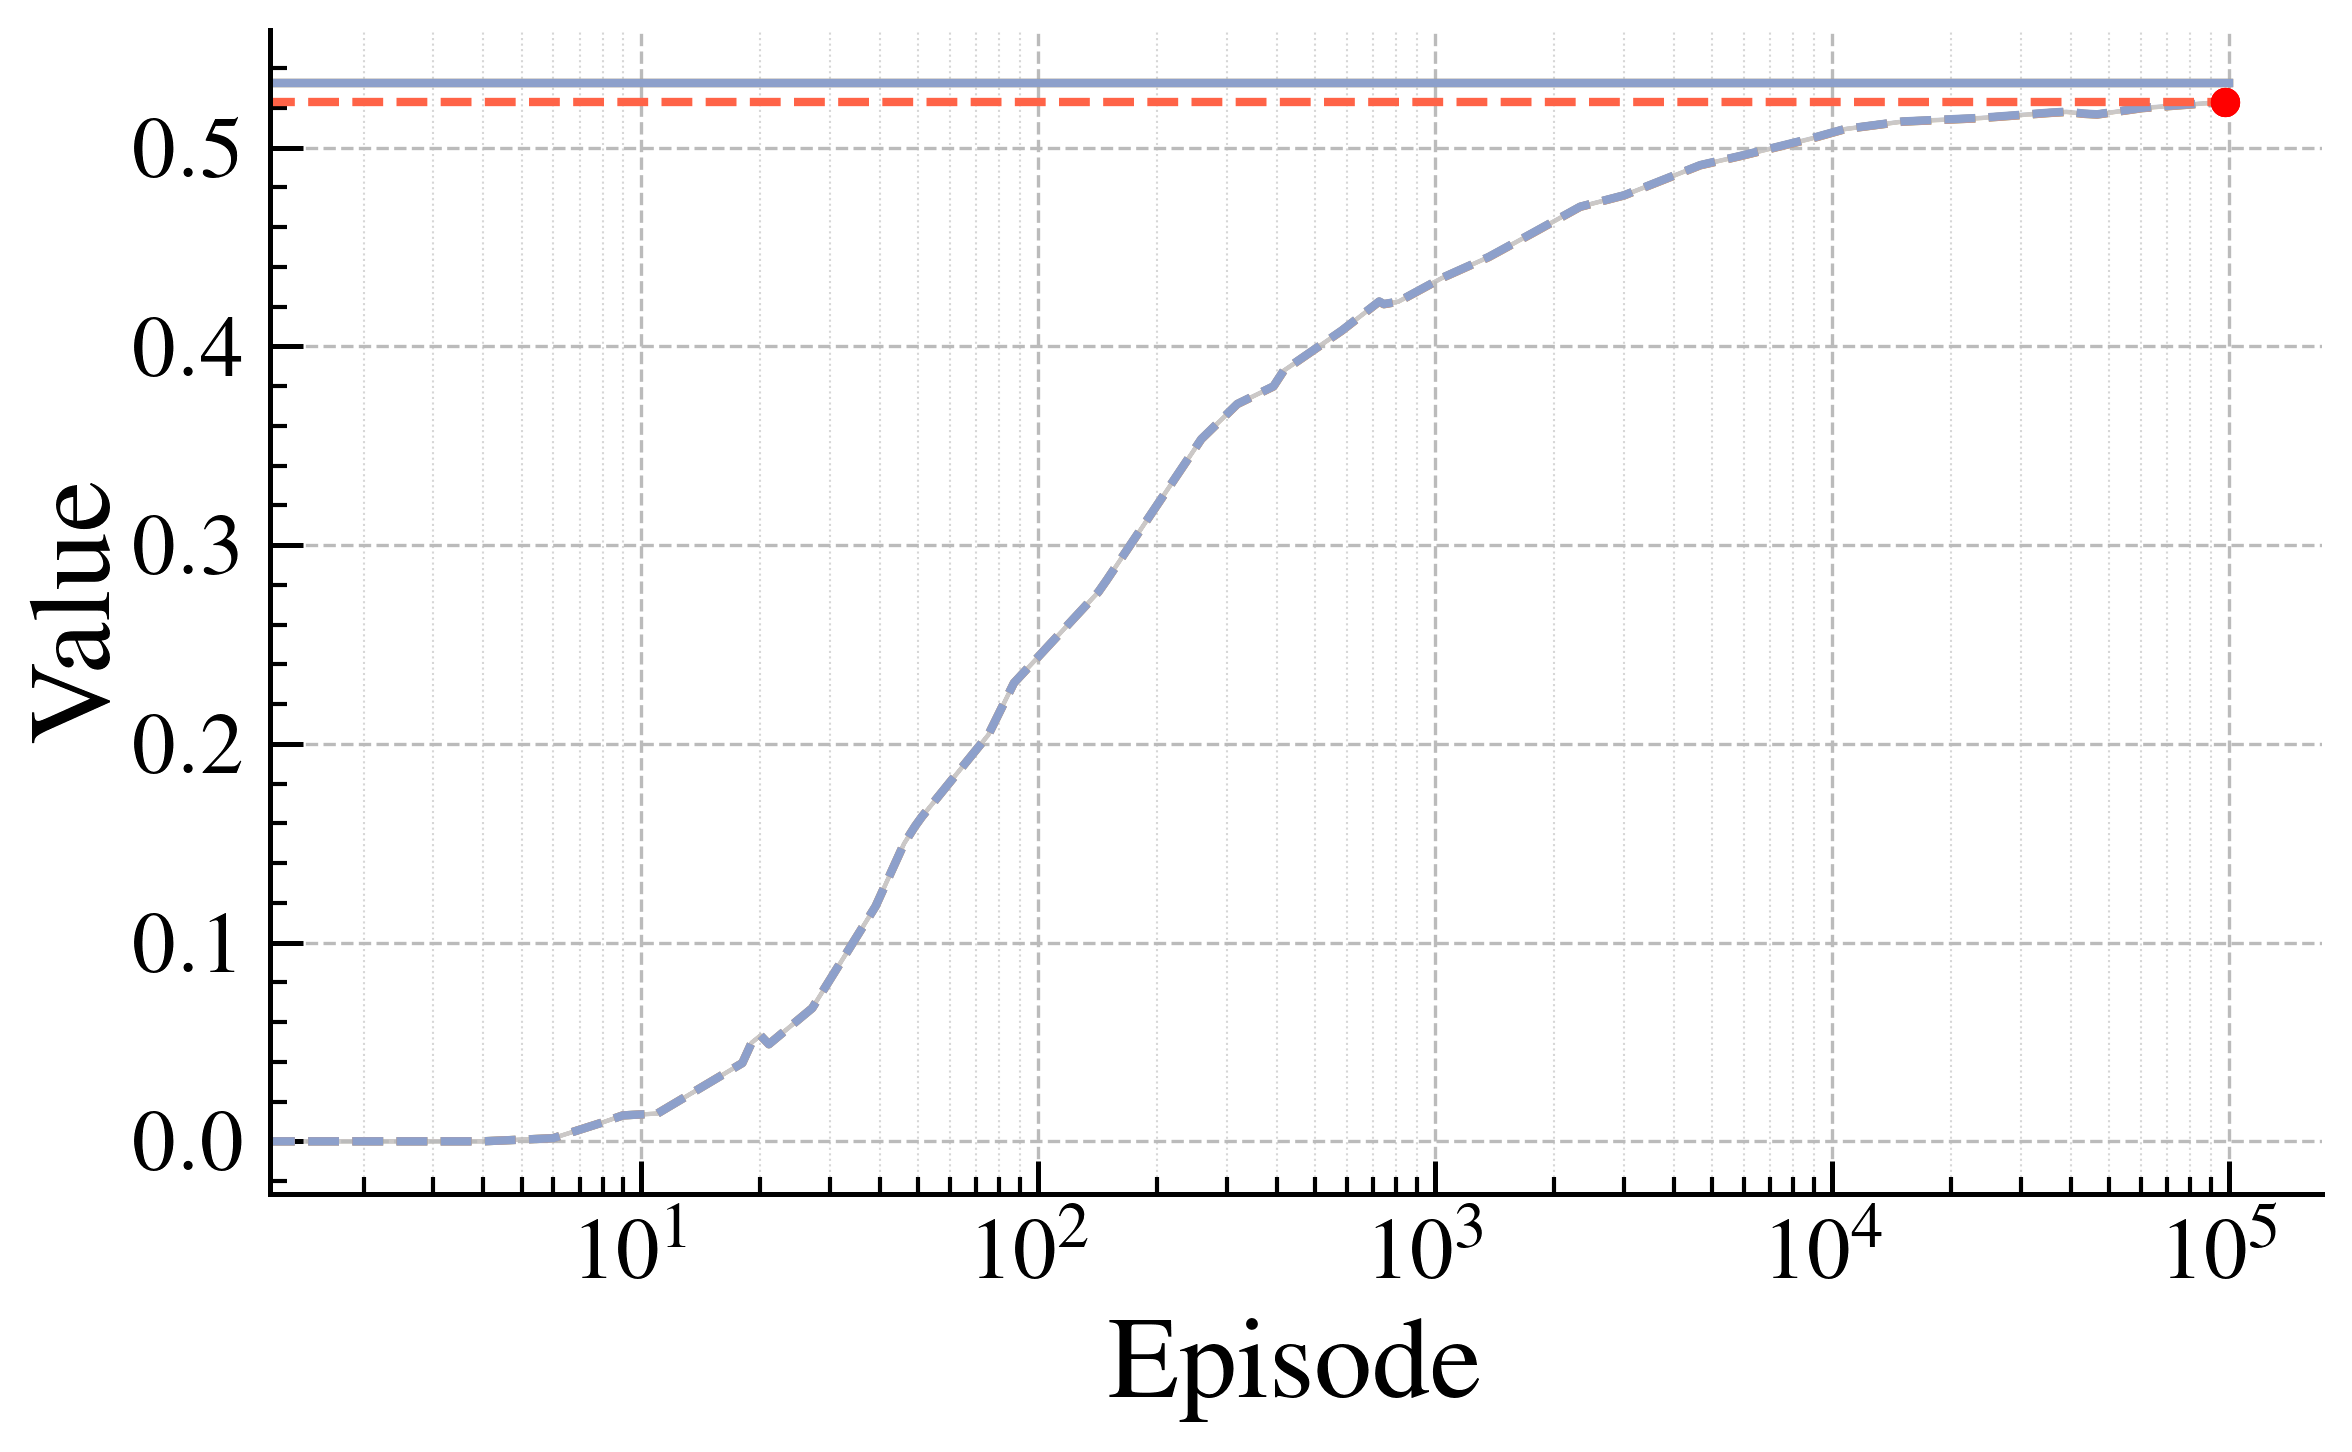

In [113]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ─── (0) GLOBAL STYLING VIA rcParams ────────────────────────────────────────
plt.rcParams.update({
    'text.usetex': True,
    'text.latex.preamble': r'\usepackage{amsmath,amssymb}',
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Times', 'DejaVu Serif', 'Serif'],
    'font.size': 12,
    'axes.titlesize': 16,
    'axes.labelsize': 16,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 8,
    'ytick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.minor.size': 4,
    'xtick.major.width': 1.2,
    'ytick.major.width': 1.2,
    'xtick.minor.width': 1.0,
    'ytick.minor.width': 1.0,
    'axes.linewidth': 1.5,
    'legend.fontsize': 14,
    'legend.frameon': True,
    'legend.framealpha': 0.8,
    'legend.fancybox': True,
    'axes.grid': True,
    'grid.color': '#bbbbbb',
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'savefig.format': 'pdf',
    'savefig.bbox': 'standard',
})

# ─── (1) PATH CONFIGURATION ───────────────────────────────────────────────────
input_root = Path('/Users/yannik/Documents/Uni/Oxford/PhD/prism_convex/prism/prism/plotting/results/parametric_convex')
if not input_root.exists():
    raise FileNotFoundError(f"No such folder: {input_root}")

output_root = Path.cwd() / "plots"
output_root.mkdir(parents=True, exist_ok=True)

# ─── (2) PLOTTING PARAMETERS ───────────────────────────────────────────────────
FIGSIZE     = (6.6, 5.0)
DPI         = 300
LIGHTRED      = '#F1E1DE'
OFFWHITE      = '#FBF4EC'
AZURE         = '#F0FFFF'
ANTIQUEWHITE  = '#FAEBD7'
BRICKRED      = '#A63A2B'
COLOR1        = '#D58E63'
ALIZARIN      = '#D96B4D'
PIGMENT       = '#7C4A21'
FALLBACK_COLORS = ['#7A6A58', '#6E7F80', '#8C6F5E', '#6D6488']
ALGO_STYLES = {
    'imdp_full':        {'label': '$\\mathcal{P}_I$', 'color': COLOR1, 'fill': '#F4DDD1'},
    'lpinterval_exact': {'label': '$\\mathcal{P}_{\\Lambda(\\mathcal{U})}$', 'color': BRICKRED, 'fill': LIGHTRED},
    'lpinterval_fast':  {'label': '$\\mathcal{P}_{\\Theta(\\mathcal{U})}$', 'color': ALIZARIN, 'fill': '#F2D6CD'},
    'parconvex_full':   {'label': '$\\mathcal{P}_{R(\\mathcal{U})}$', 'color': PIGMENT, 'fill': '#F1DDB8'},
    'imdp_none':        {'label': 'IMDP', 'color': '#7A6A58', 'fill': ANTIQUEWHITE},
}
LINESTYLES  = {'performance': '-', 'guarantee': (0, (5, 2.2))}
LEGEND_RCPARAMS = {
    'text.usetex': True,
    'text.latex.preamble': r'\usepackage{amsmath,amssymb}',
    'font.family': 'serif',
    'font.serif': ['Computer Modern Roman', 'CMU Serif', 'Latin Modern Roman', 'DejaVu Serif'],
}

# ─── (3) UTILITY TO FIND “performance” / “guarantee” COLUMNS ───────────────────
def canonical_algo_key(algo_name):
    u = algo_name.upper()
    if 'IMDP' in u and 'FULL_TYING' in u and 'NO_TYING' not in u:
        return 'imdp_full'
    if 'IMDP' in u and 'NO_TYING' in u:
        return 'imdp_none'
    if 'CPINTERVAL_EXACT' in u or 'LPINTERVAL_EXACT' in u:
        return 'lpinterval_exact'
    if 'CPINTERVAL_FAST' in u or 'LPINTERVAL_FAST' in u or 'LPINTERVAL_FAST)' in u:
        return 'lpinterval_fast'
    if 'PARCONVEX' in u and 'FULL_TYING' in u:
        return 'parconvex_full'
    return algo_name.lower()

def pretty_algo_label(algo_name):
    key = canonical_algo_key(algo_name)
    if key in ALGO_STYLES:
        return ALGO_STYLES[key]['label']
    return algo_name.replace('_', ' ')

def style_for_algo(algo_name, fallback_idx=0):
    key = canonical_algo_key(algo_name)
    if key in ALGO_STYLES:
        return ALGO_STYLES[key]
    return {
        'label': pretty_algo_label(algo_name),
        'color': FALLBACK_COLORS[fallback_idx % len(FALLBACK_COLORS)],
        'fill': OFFWHITE,
    }

def algo_sort_key(algo_name):
    order = {
        'imdp_full': 0,
        'lpinterval_exact': 1,
        'lpinterval_fast': 2,
        'parconvex_full': 3,
        'imdp_none': 4,
    }
    key = canonical_algo_key(algo_name)
    return (order.get(key, 100), pretty_algo_label(algo_name))

def value_ylabel(env_name):
    if env_name.startswith('AIRCRAFT'):
        return r'$\mathbb{P}(\neg\,\mathrm{crash}\,\mathsf{U}\,\mathrm{goal})$'
    if env_name == 'BETTING_GAME_PARALLEL':
        return r'$\mathbb{E}(\mathrm{F}^{=T}\,\mathrm{money})$'
    return 'Value'

def find_col(columns, *keywords):
    for c in columns:
        low = c.lower()
        if all(kw.lower() in low for kw in keywords):
            return c
    return None

# ─── (4) MAIN LOOP: ENV → PARAM → SEEDS → AGGREGATE & PLOT ─────────────────────
plot_count = 0
last_guarantee_data = []

for env_dir in sorted(input_root.iterdir()):
    if not env_dir.is_dir():
        continue
    env_name = env_dir.name

    for param_dir in sorted(env_dir.iterdir()):
        if not param_dir.is_dir():
            continue
        param_name = param_dir.name

        seed_dirs = [d for d in sorted(param_dir.iterdir()) if d.is_dir()]
        if not seed_dirs:
            continue

        # Group CSVs by algorithm
        combos = {}
        for seed_dir in seed_dirs:
            for csv_path in seed_dir.glob(f"{env_name}_*.csv"):
                stem = csv_path.stem
                prefix = env_name + "_"
                algo = stem[len(prefix):] if stem.startswith(prefix) else stem
                combos.setdefault(algo, []).append(csv_path)

        if not combos:
            continue

        # Containers for runtime and guarantee data
        runtime_data = []
        guarantee_data = []

        # Performance & Guarantee plot
        fig, ax = plt.subplots(figsize=FIGSIZE, dpi=DPI)
        first_algo = True
        is_minimization = False

        for i, algo_name in enumerate(sorted(combos.keys(), key=algo_sort_key)):
            csv_list = sorted(combos[algo_name])
            raw_perf, raw_guar, raw_time = [], [], []
            perf_col = guar_col = None

            # Read per-seed series
            for csv_path in csv_list:
                df = pd.read_csv(csv_path).rename(columns=str.strip)
                df = df.sort_values('Episode').set_index('Episode')

                if perf_col is None and guar_col is None:
                    perf_col = find_col(df.columns, 'performance')
                    guar_col = find_col(df.columns, 'guarantee')

                if perf_col is None or guar_col is None or 'Total Runtime' not in df.columns:
                    raw_perf = raw_guar = raw_time = []
                    break

                raw_perf.append(df[perf_col])
                raw_guar.append(df[guar_col])
                raw_time.append(df['Total Runtime'])

            if not raw_perf:
                continue

            # Align to common episode grid
            all_eps = np.sort(np.unique(np.concatenate([s.index.values for s in raw_perf])))
            perf_mat = np.zeros((len(all_eps), len(raw_perf)))
            guar_mat = np.zeros_like(perf_mat)
            time_mat = np.zeros_like(perf_mat)

            for idx, (s_perf, s_guar, s_time) in enumerate(zip(raw_perf, raw_guar, raw_time)):
                perf_mat[:, idx] = np.interp(all_eps, s_perf.index.values, s_perf.values)
                guar_mat[:, idx] = np.interp(all_eps, s_guar.index.values, s_guar.values)
                time_mat[:, idx] = np.interp(all_eps, s_time.index.values, s_time.values)

            perf_mean, perf_std = perf_mat.mean(1), perf_mat.std(1) * 0.5
            guar_mean, guar_std = guar_mat.mean(1), guar_mat.std(1)
            time_mean, time_std = time_mat.mean(1), time_mat.std(1) * 0.8

            style = style_for_algo(algo_name, i)
            display_label = style['label']
            guarantee_data.append((display_label, style['color'], all_eps, guar_mean))
            runtime_data.append((display_label, style['color'], style['fill'], all_eps, time_mean, time_std))

            if first_algo:
                is_minimization = perf_mean[-1] < perf_mean[0]
                first_algo = False

            color = style['color']
            fill_color = style['fill']
            ax.plot(all_eps, perf_mean, color=color, linestyle=LINESTYLES['performance'], lw=2,
                    label=f"{display_label} Performance")
            ax.fill_between(all_eps, perf_mean-perf_std, perf_mean+perf_std, color=fill_color, alpha=0.22)
            ax.plot(all_eps, guar_mean, color=color, linestyle=LINESTYLES['guarantee'], lw=2,
                    label=f"{display_label} Guarantee")
            ax.fill_between(all_eps, guar_mean-guar_std, guar_mean+guar_std, color=fill_color, alpha=0.18)

        # Threshold line & markers
        if guarantee_data:
            thr = min(g[-1] for _, _, _, g in guarantee_data)
            eps_min = min(np.min(x) for _, _, x, _ in guarantee_data)
            eps_max = max(np.max(x) for _, _, x, _ in guarantee_data)
            ax.hlines(thr, eps_min, eps_max, colors='tomato', linestyles='--', lw=2,
                      label='Min final guarantee')
            for name, color, x, g in guarantee_data:
                mask = (g <= thr) if is_minimization else (g >= thr)
                idx = np.argmax(mask)
                if mask[idx]:
                    ax.plot(x[idx], thr, 'o', color=color)

        ax.set_xscale('log')
        if env_name == 'BETTING_GAME_PARALLEL':
            ax.set_xlim(1e2, 1e5)
        #ax.set_yscale('log')
        if is_minimization:
            ax.invert_yaxis()
        
        ax.minorticks_on()
        ax.grid(which='minor', axis='x', linestyle=':', linewidth=0.5, alpha=0.6)
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_color('black')
            spine.set_linewidth(1.5)
        ax.tick_params(axis='y', which='both', labelsize=21, pad=6)
        ax.tick_params(axis='x', which='both', labelsize=23, pad=9)
        ax.set_xlabel('Episode', fontsize=28, labelpad=5)
        ax.set_ylabel(value_ylabel(env_name), fontsize=28, labelpad=0)
        fig.subplots_adjust(left=0.20, right=0.96, bottom=0.17, top=0.97)

        save_dir = output_root / env_name / param_name
        save_dir.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_dir / f"{env_name}_{param_name}.pdf", dpi=DPI)
        plt.close(fig)
        plot_count += 1

        # ─── (4d) RUNTIME PLOT WITH LOG-LOG & STD BANDS ──────────────────────
        fig_rt, ax_rt = plt.subplots(figsize=FIGSIZE, dpi=DPI)
        for label, color, fill_color, x, rt_mean, rt_std in runtime_data:
            ax_rt.plot(x, rt_mean, color=color, lw=2.2, label=label)
            ax_rt.fill_between(x, rt_mean-rt_std, rt_mean+rt_std, color=fill_color, alpha=0.22)

        ax_rt.set_xscale('log')
        if env_name == 'BETTING_GAME_PARALLEL':
            ax_rt.set_xlim(1e2, 1e5)
        ax_rt.set_yscale('log')
        ax_rt.minorticks_on()
    # draw minor grid lines only on the x-axis
        ax_rt.grid(which='minor', axis='x', linestyle=':', linewidth=0.5, alpha=0.6)
        for spine in ax_rt.spines.values():
            spine.set_visible(True)
            spine.set_color('black')
            spine.set_linewidth(1.5)
            # ← NEW: enable minor ticks & draw minor grid
        ax_rt.tick_params(axis='y', which='both', labelsize=21, pad=6)
        ax_rt.tick_params(axis='x', which='both', labelsize=23, pad=9)
        ax_rt.set_xlabel('Episode', fontsize=28, labelpad=5)
        ax_rt.set_ylabel('Total Runtime (s)', fontsize=28, labelpad=5)
        fig_rt.subplots_adjust(left=0.20, right=0.96, bottom=0.17, top=0.97)
        fig_rt.savefig(save_dir / f"{env_name}_{param_name}_runtime.pdf", dpi=DPI)
        plt.close(fig_rt)

        last_guarantee_data = guarantee_data

# ─── (8) LEGEND-ONLY PLOT ─────────────────────────────────────────────────────
if last_guarantee_data:
    handles = [
        plt.Line2D([0], [0], color='gray', lw=4, linestyle='-'),
        plt.Line2D([0], [0], color='gray', lw=4, linestyle='--'),
    ]
    labels = ['Performance', 'Guarantee']
    label_styles = {name: color for name, color, _, _ in last_guarantee_data}
    preferred_labels = [
        '$\\mathcal{P}_I$',
        '$\\mathcal{P}_{\\Theta(\\mathcal{U})}$',
        '$\\mathcal{P}_{\\Lambda(\\mathcal{U})}$',
        '$\\mathcal{P}_{R(\\mathcal{U})}$',
    ]
    for name in preferred_labels:
        if name not in label_styles:
            continue
        handles.append(plt.Line2D([0], [0], color=label_styles[name], lw=4))
        labels.append(name)
    with plt.rc_context(LEGEND_RCPARAMS):
        fig_leg, ax_leg = plt.subplots(figsize=(14.8, 1.5))
        ax_leg.axis('off')
        leg = ax_leg.legend(handles, labels, ncol=6, frameon=False, loc='center')
        fig_leg.canvas.draw()
        renderer = fig_leg.canvas.get_renderer()
        bbox = leg.get_frame().get_window_extent(renderer)
        fig_w, fig_h = fig_leg.get_size_inches() * fig_leg.dpi
        sep_x = (bbox.x0 + (bbox.width * (4.22/6))) / fig_w
        fig_leg.add_artist(
            plt.Line2D(
                [sep_x, sep_x], [0.44, 0.56],
                transform=fig_leg.transFigure, 
                color='black', lw=1.2
            )
        )
        fig_leg.tight_layout()
        legend_path = output_root / 'legend.pdf'
        fig_leg.savefig(legend_path, dpi=DPI, bbox_inches='tight')
        plt.close(fig_leg) 
    print(f"✅  Saved legend: {legend_path}")

In [114]:
import re
from pathlib import Path
import yaml

# ─── CONFIG ──────────────────────────────────────────────────────────────────
INPUT_ROOT = Path('/Users/yannik/Documents/Uni/Oxford/PhD/prism_convex/prism/prism/plotting_paper/results_uniform_solving/parametric_convex')
OUTPUT_ROOT = Path.cwd() / 'plots'
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
OUT_TEX = OUTPUT_ROOT / 'benchmark_stats_table.tex'

INCLUDE_PROPERTY = True  # set False to drop the "Property" column
DEBUG_LIST = False       # set True to print a few discovered YAMLs per param

# Preferred benchmark name mapping
BENCHMARK_NAME_MAP = {
    'UAV': 'UAV',
    'UAV_CONVEX': 'UAV',
    'AIRCRAFT_COLLISION': 'Aircraft Collision',
    'AIRCRAFT': 'Aircraft Collision',
    'FIREWIRE': 'Firewire',
    'SEMI_AUTONOMOUS_VEHICLE': 'Semi-Auton. Vehicle',
    'SEMIAUTONOMOUS_VEHICLE': 'Semi-Auton. Vehicle',
    'BETTING_GAME': 'Betting Game',
    'BETTING_GAME_CONVEX': 'Betting Game',
    'BETTING_GAME_CONVEX_ADAPTIVE': 'Betting Game Adaptive',
    'CHAIN': 'Chain',
}

ROW_ORDER = {
    'UAV': 0,
    'Aircraft Collision': 1,
    'Firewire': 2,
    'Semi-Auton. Vehicle': 3,
    'Betting Game': 4,
    'Chain': 5,
}

# ─── HELPERS ─────────────────────────────────────────────────────────────────
def pretty_benchmark_name(env_folder_name: str) -> str:
    key = re.sub(r'[^A-Z_]', '', env_folder_name.upper())
    if env_folder_name in BENCHMARK_NAME_MAP:
        return BENCHMARK_NAME_MAP[env_folder_name]
    if key in BENCHMARK_NAME_MAP:
        return BENCHMARK_NAME_MAP[key]
    for k, v in BENCHMARK_NAME_MAP.items():
        if env_folder_name.upper().startswith(k):
            return v
    return env_folder_name.replace('_', ' ').title()

def safe_load_yaml_info(path: Path):
    """Load YAML and return the ExperimentInfo dict if present, else the dict itself, else None."""
    try:
        with open(path, 'r') as f:
            data = yaml.safe_load(f)
    except Exception as e:
        print(f"⚠️  Failed to load YAML: {path} ({e})")
        return None
    if not isinstance(data, dict):
        return None
    if 'ExperimentInfo' in data and isinstance(data['ExperimentInfo'], dict):
        return data['ExperimentInfo']
    return data

NEEDED_KEYS = {'NumStates', 'NumTransitions', 'NumParameters'}

def pick_base_info(yaml_paths):
    """Choose the first YAML that yields a dict with at least our needed keys."""
    for yp in yaml_paths:
        info = safe_load_yaml_info(yp)
        if isinstance(info, dict) and (NEEDED_KEYS <= set(info.keys())):
            return info, yp
    for yp in yaml_paths:
        info = safe_load_yaml_info(yp)
        if isinstance(info, dict):
            return info, yp
    return None, None

def find_parconvex_yaml(param_dir: Path):
    exact = sorted(param_dir.rglob('*PARCONVEX_FULL_TYING_NOBISIM.yaml'))
    if exact:
        return exact[0]
    any_par = [p for p in param_dir.rglob('*.yaml') if 'PARCONVEX' in p.name.upper()]
    if any_par:
        return sorted(any_par)[0]
    csv_match = sorted(param_dir.rglob('*PARCONVEX_FULL_TYING_NOBISIM.csv'))
    for c in csv_match:
        y = c.with_suffix('.yaml')
        if y.exists():
            return y
    return None

def detect_property(info: dict) -> str:
    t = str(info.get('Type', '')).upper()
    spec = str(info.get('Specification', '')).upper()
    if t.startswith('REW'):
        return '$\\mathbb{E}$'
    import re as _re
    if _re.search(r'\bR(?:MAX|MIN|MAXMIN|MAXMAX)?\s*=\s*\?', spec):
        return '$\\mathbb{E}$'
    return '$\\mathbb{P}$'

def tex_escape(s: str) -> str:
    # Escape LaTeX specials; leave $ as-is for math content in 'Property' (we won't escape Property below)
    return (s.replace('\\', r'\textbackslash{}')
             .replace('&', r'\&')
             .replace('%', r'\%')
             .replace('$', r'\$')
             .replace('#', r'\#')
             .replace('_', r'\_')
             .replace('{', r'\{')
             .replace('}', r'\}')
             .replace('~', r'\textasciitilde{}')
             .replace('^', r'\textasciicircum{}'))

def sort_key(row):
    base = ROW_ORDER.get(row['Benchmark'], 10000)
    return (base, row['Benchmark'], row['Param'])

def _to_int(x, default=10**18):
    """Parse integers safely for sorting (handles commas/whitespace)."""
    try:
        return int(str(x).replace(',', '').strip())
    except Exception:
        return default

# --- Rounding & truncation for parameter values ------------------------------
def _fmt_param_number(val, decimals=2):
    try:
        f = float(val)
    except Exception:
        return str(val)
    # keep integers as integers; round non-integers to fixed decimals
    if abs(f - round(f)) < 1e-12:
        return str(int(round(f)))
    return f"{round(f, decimals):.{decimals}f}"

def round_param_values(param_vals, decimals=2) -> str:
    """
    Accepts ParameterValues as str/dict/list/tuple/number and returns a compact, rounded string.
    - For strings like "n=10,p=0.083333333", rounds each numeric to given decimals.
    - For dicts, preserves key order and joins as 'k=v' pairs.
    - For lists/tuples, joins values with commas.
    """
    if param_vals is None:
        return ""
    if isinstance(param_vals, dict):
        parts = []
        for k, v in param_vals.items():  # preserves YAML order in Python 3.7+
            parts.append(f"{k}={_fmt_param_number(v, decimals)}")
        return ",".join(parts)
    if isinstance(param_vals, (list, tuple)):
        return ",".join(_fmt_param_number(v, decimals) for v in param_vals)
    if isinstance(param_vals, (int, float)):
        return _fmt_param_number(param_vals, decimals)
    s = str(param_vals).strip()
    pieces = [p.strip() for p in s.split(',') if p.strip() != ""]
    out = []
    for piece in pieces:
        if '=' in piece:
            k, v = piece.split('=', 1)
            out.append(f"{k.strip()}={_fmt_param_number(v.strip(), decimals)}")
        else:
            out.append(_fmt_param_number(piece, decimals))
    return ",".join(out)

def stringify_params_limited(param_vals, limit=2, decimals=2) -> str:
    """
    Like round_param_values, but only keeps the first `limit` parameters.
    """
    if param_vals is None:
        return ""
    if isinstance(param_vals, dict):
        items = list(param_vals.items())[:limit]
        parts = [f"{k}={_fmt_param_number(v, decimals)}" for k, v in items]
        return ",".join(parts)
    if isinstance(param_vals, (list, tuple)):
        return ",".join(_fmt_param_number(v, decimals) for v in list(param_vals)[:limit])
    if isinstance(param_vals, (int, float)):
        return _fmt_param_number(param_vals, decimals)
    s = str(param_vals).strip()
    pieces = [p.strip() for p in s.split(',') if p.strip() != ""]
    pieces = pieces[:limit]
    out = []
    for piece in pieces:
        if '=' in piece:
            k, v = piece.split('=', 1)
            out.append(f"{k.strip()}={_fmt_param_number(v.strip(), decimals)}")
        else:
            out.append(_fmt_param_number(piece, decimals))
    return ",".join(out)

# ─── SCAN ────────────────────────────────────────────────────────────────────
if not INPUT_ROOT.exists():
    raise FileNotFoundError(f"No such folder: {INPUT_ROOT}")

flat_rows = []  # one per (benchmark, param)
seen = set()

benchmarks = [d for d in sorted(INPUT_ROOT.iterdir()) if d.is_dir()]
if DEBUG_LIST:
    print(f"Found {len(benchmarks)} benchmarks under {INPUT_ROOT}")

for env_dir in benchmarks:
    env_name = env_dir.name
    bench_pretty = pretty_benchmark_name(env_name)

    params = [p for p in sorted(env_dir.iterdir()) if p.is_dir()]
    if DEBUG_LIST:
        print(f"- {env_name}: {len(params)} params")

    for param_dir in params:
        param_name = param_dir.name  # e.g., "n=10,p=0.55" (fallback for ParameterValues)
        key = (env_name, param_name)
        if key in seen:
            continue

        yaml_paths = sorted(param_dir.rglob('*.yaml'))
        if DEBUG_LIST:
            print(f"  · {param_name}: {len(yaml_paths)} yaml files")
            for p in yaml_paths[:3]:
                print(f"    - {p}")

        if not yaml_paths:
            print(f"⚠️  No YAML files under {param_dir}, skipping.")
            continue

        base_info, base_path = pick_base_info(yaml_paths)
        if not isinstance(base_info, dict):
            print(f"⚠️  Could not find a usable YAML with required keys under {param_dir}, skipping.")
            continue

        par_yaml = find_parconvex_yaml(param_dir)
        par_info = safe_load_yaml_info(par_yaml) if par_yaml else None

        num_states = base_info.get('NumStates', '')
        num_trans = base_info.get('NumTransitions', '')
        num_params = base_info.get('NumParameters', '')
        if isinstance(par_info, dict) and 'NumLearnableComponents' in par_info:
            num_expr = par_info['NumLearnableComponents']
        else:
            num_expr = base_info.get('NumLearnableComponents', '')

        prop = detect_property(base_info) if INCLUDE_PROPERTY else ''

        # Parameter values (prefer YAML, fallback to folder name)
        raw_param_vals = base_info.get('ParameterValues', param_name)

        # Decide whether to truncate (if total number of parameters > 4)
        nparams_int = _to_int(num_params, default=0)
        if nparams_int > 4:
            # show only first 2 parameters, rounded
            param_vals = stringify_params_limited(raw_param_vals, limit=2, decimals=2)
        else:
            # show all parameters, rounded
            param_vals = round_param_values(raw_param_vals, decimals=2)

        flat_rows.append({
            'Benchmark': bench_pretty,
            'Param': param_name,         # used for sorting/grouping only
            'ParamVals': param_vals,     # printed column (rounded & possibly truncated)
            'States': num_states,
            'Transitions': num_trans,
            'Parameters': num_params,
            'Expressions': num_expr,
            'Property': prop
        })
        seen.add(key)

# ─── GROUP (for multirow) ────────────────────────────────────────────────────
flat_rows.sort(key=sort_key)
grouped = {}
for r in flat_rows:
    grouped.setdefault(r['Benchmark'], []).append(r)

# Sort rows within each benchmark group by number of states (ascending)
for bench_name, rows in grouped.items():
    rows.sort(key=lambda r: _to_int(r['States']))  # use reverse=True for descending

# ─── RENDER LaTeX (with \multirow in first column) ───────────────────────────
# NOTE: Requires \usepackage{booktabs, multirow, array} in your preamble.

if INCLUDE_PROPERTY:
    header_cols = [
        (r'\textbf{Benchmark}',           r'>{\centering\arraybackslash}m{3.8cm}'),
        (r'\textbf{Param.\ Values}',      r'>{\centering\arraybackslash}m{3.0cm}'),
        (r'\textbf{$|\Theta|$}',          r'>{\centering\arraybackslash}m{1cm}'),
        (r'\textbf{$|S|$}',               r'>{\centering\arraybackslash}m{1.5cm}'),
        (r'\textbf{$|T|$}',               r'>{\centering\arraybackslash}m{1.5cm}'),
        (r'\textbf{$|\mathcal{E}|$}',     r'>{\centering\arraybackslash}m{1.5cm}'),
        (r'\textbf{Property}',            r'>{\centering\arraybackslash}m{1.5cm}'),
    ]
    col_keys = ['ParamVals', 'Parameters', 'States', 'Transitions', 'Expressions', 'Property']
else:
    header_cols = [
        (r'\textbf{Benchmark}',           r'>{\centering\arraybackslash}m{4.0cm}'),
        (r'\textbf{Param.\ Values}',      r'>{\centering\arraybackslash}m{3.0cm}'),
        (r'\textbf{\#Parameters}',        r'>{\centering\arraybackslash}m{1.5cm}'),
        (r'\textbf{\#States}',            r'>{\centering\arraybackslash}m{1.5cm}'),
        (r'\textbf{\#Transitions}',       r'>{\centering\arraybackslash}m{1.5cm}'),
        (r'\textbf{\#Expressions}',       r'>{\centering\arraybackslash}m{1.5cm}'),
    ]
    col_keys = ['ParamVals', 'Parameters', 'States', 'Transitions', 'Expressions']

col_spec = ' '.join(spec for _, spec in header_cols)
header_line = ' & '.join(h for h, _ in header_cols) + r' \\'

# Build body lines with vertical space between benchmark groups
body_lines = []
group_list = list(grouped.items())
for gi, (bench_name, rows) in enumerate(group_list):
    n = len(rows)
    bench_tex = tex_escape(bench_name)
    for idx, r in enumerate(rows):
        # Escape everything except 'Property' which may contain math like $\mathbb{E}$
        vals = []
        for k in col_keys:
            v = '' if r[k] is None else str(r[k])
            vals.append(v if k == 'Property' else tex_escape(v))
        first_cell = rf'\multirow[c]{{{n}}}{{*}}{{{bench_tex}}}' if idx == 0 else ''
        line = ' & '.join([first_cell] + vals) + r' \\'
        body_lines.append(line)
    # add spacing after each benchmark block except the last
    if gi != len(group_list) - 1:
        body_lines.append(r'\addlinespace[4pt]')

latex = []
latex.append(r'\begin{table}[t]')
latex.append(r'\centering')
latex.append(r'\caption{Salient characteristics of the evaluated benchmarks.}')
latex.append(r'\resizebox{0.93\textwidth}{!}{%')
latex.append(fr'\begin{{tabular}}{{{col_spec}}}')
latex.append(r'\toprule')
latex.append(header_line)
latex.append(r'\midrule')
latex.extend(body_lines)
latex.append(r'\bottomrule')
latex.append(r'\end{tabular}')
latex.append(r'} % end of resizebox')
latex.append(r'\label{tab:stats}')
latex.append(r'\end{table}')
latex_str = '\n'.join(latex)

with open(OUT_TEX, 'w') as f:
    f.write('% Requires \\usepackage{booktabs,multirow,array}\n' + latex_str)

print(f'✅ Wrote LaTeX table to: {OUT_TEX}')
print(f'   Benchmarks: {len(grouped)}  Rows total: {sum(len(v) for v in grouped.values())}')

✅ Wrote LaTeX table to: /Users/yannik/Documents/Uni/Oxford/PhD/prism_convex/prism/prism/plotting_paper/plots/benchmark_stats_table.tex
   Benchmarks: 12  Rows total: 32


In [122]:
import re
import math
from pathlib import Path
import pandas as pd
import numpy as np
import yaml

# ─── CONFIG ──────────────────────────────────────────────────────────────────
# CSVs (uniform solving)
INPUT_ROOT = Path('/Users/yannik/Documents/Uni/Oxford/PhD/prism_convex/prism/prism/plotting_paper/results_uniform_solving/parametric_convex')
# YAMLs (to fetch NumStates, NumParameters and ParameterValues for sorting/printing)
YAML_ROOT = Path('/Users/yannik/Documents/Uni/Oxford/PhD/prism_convex/prism/prism/plotting_paper/results_uniform_solving/parametric_convex')

OUTPUT_ROOT = Path.cwd() / 'plots'
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
OUT_TEX = OUTPUT_ROOT / 'benchmark_results_table.tex'

DEBUG_LIST = False

# Pretty benchmark names (same map you used)
BENCHMARK_NAME_MAP = {
    'UAV': 'UAV',
    'UAV_CONVEX': 'UAV',
    'AIRCRAFT_COLLISION': 'Aircraft Collision',
    'AIRCRAFT': 'Aircraft Collision',
    'FIREWIRE': 'Firewire',
    'SEMI_AUTONOMOUS_VEHICLE': 'Semi-Auton. Vehicle',
    'SEMIAUTONOMOUS_VEHICLE': 'Semi-Auton. Vehicle',
    'BETTING_GAME': 'Betting Game',
    'BETTING_GAME_CONVEX': 'Betting Game',
    'BETTING_GAME_CONVEX_ADAPTIVE': 'Betting Game Adaptive',
    'CHAIN': 'Chain',
}

# High-level row ordering by benchmark (optional)
ROW_ORDER = {
    'UAV': 0,
    'Aircraft Collision': 1,
    'Firewire': 2,
    'Semi-Auton. Vehicle': 3,
    'Betting Game': 4,
    'Betting Game Adaptive': 5,
    'Chain': 6,
}

# Canonical algorithm keys and nice display names
ALGO_DISPLAY = {
    'imdp_full':      r'IMDP (tying)',
    'imdp_none':      r'IMDP',
    'lp_exact':       r'LP-Interval (Expr)',
    'lp_fast':        r'LP-Interval (Param)',
    'parconvex':      r'LP',
}
# Column order: IMDP, IMDP (tying), LP, LP-Interval (Expr), LP-Interval (Param)
ALGO_ORDER = ['imdp_none', 'imdp_full', 'parconvex', 'lp_exact', 'lp_fast']

# ─── HELPERS ─────────────────────────────────────────────────────────────────
def pretty_benchmark_name(env_folder_name: str) -> str:
    key = re.sub(r'[^A-Z_]', '', env_folder_name.upper())
    if env_folder_name in BENCHMARK_NAME_MAP:
        return BENCHMARK_NAME_MAP[env_folder_name]
    if key in BENCHMARK_NAME_MAP:
        return BENCHMARK_NAME_MAP[key]
    for k, v in BENCHMARK_NAME_MAP.items():
        if env_folder_name.upper().startswith(k):
            return v
    return env_folder_name.replace('_', ' ').title()

def find_col(columns, *keywords):
    """Return the first column name containing all keywords (case-insensitive)."""
    for c in columns:
        low = c.lower()
        if all(kw.lower() in low for kw in keywords):
            return c
    return None

def algo_key_from_filename(name: str) -> str:
    u = name.upper()
    if '_IMDP_' in u and '_FULL_TYING_' in u:
        return 'imdp_full'
    if '_IMDP_' in u and '_NO_TYING_' in u:
        return 'imdp_none'
    if 'LPINTERVAL_EXACT' in u:
        return 'lp_exact'
    if 'LPINTERVAL_FAST' in u or 'LPINTERVAL_FAST)' in u:  # tolerate stray ')'
        return 'lp_fast'
    if 'PARCONVEX' in u:
        return 'parconvex'
    return ''  # unknown

def fmt_num(x, sig=3, sci_hi=1e5, sci_lo=1e-3):
    """
    Format with ~sig significant digits.
    - Use plain (non-scientific) for values in [sci_lo, sci_hi).
    - Use compact scientific '1.23e5' otherwise.
    """
    if x is None or (isinstance(x, float) and (np.isnan(x) or np.isinf(x))):
        return r'--'
    try:
        x = float(x)
    except Exception:
        return r'--'
    ax = abs(x)
    if ax == 0:
        return '0'
    if (ax >= sci_hi) or (ax < sci_lo):
        s = f"{x:.{max(1, sig-1)}e}"
        s = re.sub(r'e\+?0*(\d+)', r'e\1', s)  # compact exponent
        return s
    d = int(math.floor(math.log10(ax))) + 1  # digits before decimal
    decimals = max(0, sig - d)
    s = f"{x:.{decimals}f}"
    if '.' in s:
        s = s.rstrip('0').rstrip('.')
    return s

def fmt_time(x):
    """Always show two decimals for times (seconds)."""
    if x is None or (isinstance(x, float) and (np.isnan(x) or np.isinf(x))):
        return r'--'
    try:
        return f"{float(x):.2f}"
    except Exception:
        return r'--'

def tex_escape(s: str) -> str:
    if s is None:
        return ''
    return (s.replace('\\', r'\textbackslash{}')
             .replace('&', r'\&')
             .replace('%', r'\%')
             .replace('$', r'\$')
             .replace('#', r'\#')
             .replace('_', r'\_')
             .replace('{', r'\{')
             .replace('}', r'\}')
             .replace('~', r'\textasciitilde{}')
             .replace('^', r'\textasciicircum{}'))

def sort_key_group(row):
    base = ROW_ORDER.get(row['Benchmark'], 10_000)
    return (base, row['Benchmark'])  # first sort by benchmark bucket; per-benchmark sort later by states

def _to_int(x, default=10**18):
    try:
        return int(str(x).replace(',', '').strip())
    except Exception:
        return default

def safe_load_yaml_info(path: Path):
    try:
        with open(path, 'r') as f:
            data = yaml.safe_load(f)
    except Exception:
        return None
    if not isinstance(data, dict):
        return None
    if 'ExperimentInfo' in data and isinstance(data['ExperimentInfo'], dict):
        return data['ExperimentInfo']
    return data

NEEDED_KEYS = {'NumStates', 'NumTransitions', 'NumParameters'}

def pick_base_info(yaml_paths):
    for yp in yaml_paths:
        info = safe_load_yaml_info(yp)
        if isinstance(info, dict) and (NEEDED_KEYS <= set(info.keys())):
            return info
    for yp in yaml_paths:
        info = safe_load_yaml_info(yp)
        if isinstance(info, dict):
            return info
    return None

# Return NumStates, ParameterValues, NumParameters, TrueOptimum (unused)
def fetch_yaml_stats(env_folder: str, param_folder: str):
    ydir = YAML_ROOT / env_folder / param_folder
    if not ydir.exists():
        return None, None, None, None
    ypaths = sorted(ydir.rglob('*.yaml'))
    if not ypaths:
        return None, None, None, None
    info = pick_base_info(ypaths)
    if not isinstance(info, dict):
        return None, None, None, None
    return (
        info.get('NumStates', None),
        info.get('ParameterValues', None),
        info.get('NumParameters', None),
        info.get('TrueOptimum', None),
    )

# --- Parameter-value rounding/truncation ------------------------------------
def _fmt_param_number(val, decimals=2):
    try:
        f = float(val)
    except Exception:
        return str(val)
    if abs(f - round(f)) < 1e-12:   # integers as integers
        return str(int(round(f)))
    return f"{round(f, decimals):.{decimals}f}"

def round_param_values(param_vals, decimals=2) -> str:
    if param_vals is None:
        return ""
    if isinstance(param_vals, dict):
        parts = [f"{k}={_fmt_param_number(v, decimals)}" for k, v in param_vals.items()]
        return ",".join(parts)
    if isinstance(param_vals, (list, tuple)):
        return ",".join(_fmt_param_number(v, decimals) for v in param_vals)
    if isinstance(param_vals, (int, float)):
        return _fmt_param_number(param_vals, decimals)
    s = str(param_vals).strip()
    pieces = [p.strip() for p in s.split(',') if p.strip() != ""]
    out = []
    for piece in pieces:
        if '=' in piece:
            k, v = piece.split('=', 1)
            out.append(f"{k.strip()}={_fmt_param_number(v.strip(), decimals)}")
        else:
            out.append(_fmt_param_number(piece, decimals))
    return ",".join(out)

def stringify_params_limited(param_vals, limit=2, decimals=2) -> str:
    """Round like above but keep only the first `limit` parameters."""
    if param_vals is None:
        return ""
    if isinstance(param_vals, dict):
        items = list(param_vals.items())[:limit]
        return ",".join(f"{k}={_fmt_param_number(v, decimals)}" for k, v in items)
    if isinstance(param_vals, (list, tuple)):
        return ",".join(_fmt_param_number(v, decimals) for v in list(param_vals)[:limit])
    if isinstance(param_vals, (int, float)):
        return _fmt_param_number(param_vals, decimals)
    s = str(param_vals).strip()
    pieces = [p.strip() for p in s.split(',') if p.strip() != ""]
    pieces = pieces[:limit]
    out = []
    for piece in pieces:
        if '=' in piece:
            k, v = piece.split('=', 1)
            out.append(f"{k.strip()}={_fmt_param_number(v.strip(), decimals)}")
        else:
            out.append(_fmt_param_number(piece, decimals))
    return ",".join(out)

# Clamp tiny values to zero for display
def clamp_small(x, thresh=1e-3):
    try:
        xf = float(x)
    except Exception:
        return x
    if abs(xf) < thresh:
        return 0.0
    return xf

def is_number(x):
    try:
        return np.isfinite(float(x))
    except Exception:
        return False

# ─── SCAN + AGGREGATE ───────────────────────────────────────────────────────
if not INPUT_ROOT.exists():
    raise FileNotFoundError(f"No such folder: {INPUT_ROOT}")

rows = []  # one per (benchmark, param)
bench_dirs = [d for d in sorted(INPUT_ROOT.iterdir()) if d.is_dir()]

for env_dir in bench_dirs:
    env_name = env_dir.name                     # e.g., BETTING_GAME_CONVEX
    bench_pretty = pretty_benchmark_name(env_name)

    for param_dir in sorted(env_dir.iterdir()):
        if not param_dir.is_dir():
            continue
        param_name = param_dir.name             # e.g., n=10,p=0.55

        # Stats from YAMLs for sorting + display (also NumParameters & TrueOptimum)
        num_states, param_vals_yaml, num_params_yaml, true_optimum = fetch_yaml_stats(env_name, param_name)
        states_sort_key = _to_int(num_states)
        # Decide whether to truncate Param. Values
        nparams_int = _to_int(num_params_yaml, default=0)
        raw_param_display = param_vals_yaml if param_vals_yaml else param_name
        if nparams_int > 2:
            param_display = stringify_params_limited(raw_param_display, limit=2, decimals=2)
        else:
            param_display = round_param_values(raw_param_display, decimals=2)

        # Gather per-algorithm values across seeds
        per_algo = {k: {'rob': [], 'opt': [], 'rt': []} for k in ALGO_ORDER}

        for seed_dir in sorted(param_dir.iterdir()):
            if not seed_dir.is_dir():
                continue
            for csv_path in sorted(seed_dir.glob('*.csv')):
                algo_key = algo_key_from_filename(csv_path.name)
                if algo_key not in per_algo:
                    continue
                try:
                    df = pd.read_csv(csv_path).rename(columns=str.strip)
                except Exception as e:
                    if DEBUG_LIST: print(f"⚠️ Failed to read {csv_path}: {e}")
                    continue

                if 'Episode' in df.columns:
                    df = df.sort_values('Episode')

                col_rob   = find_col(df.columns, 'Robust', 'Guarantee', 'UMDP')
                col_opt   = find_col(df.columns, 'Optimistic', 'Guarantee', 'UMDP')
                col_trob  = find_col(df.columns, 'Model', 'Checking', 'Time', 'Robust')
                col_build = find_col(df.columns, 'Model', 'Building', 'Time')

                # Need at least robust guarantee AND robust checking time to compute interval & runtime
                if col_rob is None or col_opt is None or col_trob is None:
                    if DEBUG_LIST:
                        print(f"⚠️ Missing needed columns in {csv_path.name}")
                    continue

                last = df.iloc[-1]
                per_algo[algo_key]['rob'].append(last[col_rob])
                per_algo[algo_key]['opt'].append(last[col_opt])

                # Runtime = Model Building Time + Model Checking Time Robust
                try:
                    t_check = float(last[col_trob])
                except Exception:
                    t_check = 0.0
                try:
                    t_build = float(last[col_build]) if col_build is not None else 0.0
                except Exception:
                    t_build = 0.0
                per_algo[algo_key]['rt'].append(t_build + t_check)

        # Aggregate across seeds
        agg = {}
        for k in ALGO_ORDER:
            rob_vals = per_algo[k]['rob']
            opt_vals = per_algo[k]['opt']
            rt_vals  = per_algo[k]['rt']
            agg[k] = {
                'rob': float(np.mean(rob_vals)) if rob_vals else None,
                'opt': float(np.mean(opt_vals)) if opt_vals else None,
                'rt':  float(np.mean(rt_vals))  if rt_vals else None,
            }

        rows.append({
            'Benchmark': bench_pretty,
            'EnvFolder': env_name,
            'Param': param_name,
            'ParamDisplay': param_display,   # rounded & possibly truncated
            'NumStates': num_states,
            'StatesSortKey': states_sort_key,
            'TrueOptimum': true_optimum,     # kept (unused)
            'Agg': agg,
        })

# ─── GROUP + SORT WITHIN BENCHMARK BY NumStates ─────────────────────────────
rows.sort(key=sort_key_group)

from collections import defaultdict
grouped = defaultdict(list)
for r in rows:
    grouped[r['Benchmark']].append(r)

for bench_name, grp in grouped.items():
    grp.sort(key=lambda r: r['StatesSortKey'])

# ─── RENDER LaTeX ───────────────────────────────────────────────────────────
bench_spec  = r'>{\centering\arraybackslash}m{3.6cm}'
param_spec  = r'>{\centering\arraybackslash}m{3.0cm}'
ival_spec   = r'>{\centering\arraybackslash}m{2.4cm}'
time_spec   = r'>{\centering\arraybackslash}m{1.3cm}'

colspec_parts = [bench_spec, param_spec]
for i, _ in enumerate(ALGO_ORDER):
    colspec_parts.append(ival_spec)  # [l,u]
    colspec_parts.append(time_spec)  # time
    if i != len(ALGO_ORDER) - 1:
        colspec_parts.append(r'@{\hspace{6pt}}')  # extra space between algos
col_spec = ' '.join(colspec_parts)

top_headers = [r'\textbf{Benchmark}', r'\textbf{Param.\ Values}']
for k in ALGO_ORDER:
    top_headers.append(r'\multicolumn{2}{c}{\textbf{' + ALGO_DISPLAY[k] + r'}}')

sub_headers = [r'', r'']
for _ in ALGO_ORDER:
    sub_headers.append(r'$[\,\underline{V},\,\overline{V}\,]$')
    sub_headers.append(r'Time (s)')

cmidrules = []
start = 3  # first two columns are 1–2
for _ in ALGO_ORDER:
    end = start + 1   # two columns per algorithm
    cmidrules.append(rf'\cmidrule(lr){{{start}-{end}}}')
    start = end + 1

body_lines = []
group_list = list(grouped.items())
for gi, (bench_name, grp) in enumerate(group_list):
    n = len(grp)
    bench_tex = tex_escape(bench_name)
    for idx, r in enumerate(grp):
        first_cell = rf'\multirow[c]{{{n}}}{{*}}{{{bench_tex}}}' if idx == 0 else ''
        row_cells = [first_cell, tex_escape(r['ParamDisplay'])]
        agg = r['Agg']

        for k in ALGO_ORDER:
            # Clamp tiny values, then enforce [min, max] ordering
            rob_raw = clamp_small(agg[k]['rob'], thresh=1e-3)
            opt_raw = clamp_small(agg[k]['opt'], thresh=1e-3)

            if is_number(rob_raw) and is_number(opt_raw):
                lo = float(rob_raw)
                hi = float(opt_raw)
                if lo > hi:
                    lo, hi = hi, lo
                interval_tex = rf'$[{fmt_num(lo)},\,{fmt_num(hi)}]$'
            else:
                interval_tex = r'--'

            t_r = fmt_time(agg[k]['rt'])   # two decimals for time
            row_cells.append(interval_tex)
            row_cells.append(t_r)

        body_lines.append(' & '.join(row_cells) + r' \\')
    if gi != len(group_list) - 1:
        body_lines.append(r'\addlinespace[4pt]')   # tweak 4pt → 3pt/6pt to taste

latex = []
latex.append(r'\begin{landscape}')  # <<< LANDSCAPE START (requires \usepackage{pdflscape})
latex.append(r'\begin{table}[t]')
latex.append(r'\centering')
latex.append(r'\caption{Final robust/optimistic guarantees and runtime (model building + robust checking) per algorithm.}')
latex.append(fr'\resizebox{{1.6\textwidth}}{{!}}{{%')  # <<< widen to 1.6× textwidth
latex.append(fr'\begin{{tabular}}{{{col_spec}}}')
latex.append(r'\toprule')
latex.append(' & '.join(top_headers) + r' \\')
latex.append(' '.join(cmidrules))
latex.append(' & '.join(sub_headers) + r' \\')
latex.append(r'\midrule')
latex.extend(body_lines)
latex.append(r'\bottomrule')
latex.append(r'\end{tabular}')
latex.append(r'} % end of resizebox')
latex.append(r'\label{tab:results}')
latex.append(r'\end{table}')
latex.append(r'\end{landscape}')   # <<< LANDSCAPE END

with open(OUT_TEX, 'w') as f:
    f.write('% Requires \\usepackage{booktabs,multirow,array,pdflscape}\n' + '\n'.join(latex))

print(f'✅ Wrote LaTeX table to: {OUT_TEX}')
print(f'   Benchmarks: {len(grouped)}  Rows total: {sum(len(v) for v in grouped.values())}')

✅ Wrote LaTeX table to: /Users/yannik/Documents/Uni/Oxford/PhD/prism_convex/prism/prism/plotting_paper/plots/benchmark_results_table.tex
   Benchmarks: 12  Rows total: 32


In [106]:
# With relative gap
import re
import math
from pathlib import Path
import pandas as pd
import numpy as np
import yaml

# ─── CONFIG ──────────────────────────────────────────────────────────────────
# CSVs (uniform solving)
INPUT_ROOT = Path('/Users/yannik/Documents/Uni/Oxford/PhD/prism_convex/prism/prism/plotting_paper/results_uniform_solving/parametric_convex')
# YAMLs (to fetch NumStates, NumParameters and ParameterValues for sorting/printing)
YAML_ROOT = Path('/Users/yannik/Documents/Uni/Oxford/PhD/prism_convex/prism/prism/plotting_paper/results_uniform_solving/parametric_convex')

OUTPUT_ROOT = Path.cwd() / 'plots'
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
OUT_TEX = OUTPUT_ROOT / 'benchmark_results_table.tex'

DEBUG_LIST = False

# Pretty benchmark names (same map you used)
BENCHMARK_NAME_MAP = {
    'UAV': 'UAV',
    'UAV_CONVEX': 'UAV',
    'AIRCRAFT_COLLISION': 'Aircraft Collision',
    'AIRCRAFT': 'Aircraft Collision',
    'FIREWIRE': 'Firewire',
    'SEMI_AUTONOMOUS_VEHICLE': 'Semi-Auton. Vehicle',
    'SEMIAUTONOMOUS_VEHICLE': 'Semi-Auton. Vehicle',
    'BETTING_GAME': 'Betting Game',
    'BETTING_GAME_CONVEX': 'Betting Game',
    'BETTING_GAME_CONVEX_ADAPTIVE': 'Betting Game Adaptive',
    'CHAIN': 'Chain',
}

# High-level row ordering by benchmark (optional)
ROW_ORDER = {
    'UAV': 0,
    'Aircraft Collision': 1,
    'Firewire': 2,
    'Semi-Auton. Vehicle': 3,
    'Betting Game': 4,
    'Betting Game Adaptive': 5,
    'Chain': 6,
}

# Canonical algorithm keys and nice display names
ALGO_DISPLAY = {
    'imdp_full':      r'IMDP (tying)',
    'imdp_none':      r'IMDP',
    'lp_exact':       r'LP-Interval (Expr)',
    'lp_fast':        r'LP-Interval (Param)',
    'parconvex':      r'LP',
}
# Column order: IMDP, IMDP (tying), LP, LP-Interval (Expr), LP-Interval (Param)
ALGO_ORDER = ['imdp_none', 'imdp_full', 'parconvex', 'lp_exact', 'lp_fast']

# ─── HELPERS ─────────────────────────────────────────────────────────────────
def pretty_benchmark_name(env_folder_name: str) -> str:
    key = re.sub(r'[^A-Z_]', '', env_folder_name.upper())
    if env_folder_name in BENCHMARK_NAME_MAP:
        return BENCHMARK_NAME_MAP[env_folder_name]
    if key in BENCHMARK_NAME_MAP:
        return BENCHMARK_NAME_MAP[key]
    for k, v in BENCHMARK_NAME_MAP.items():
        if env_folder_name.upper().startswith(k):
            return v
    return env_folder_name.replace('_', ' ').title()

def find_col(columns, *keywords):
    """Return the first column name containing all keywords (case-insensitive)."""
    for c in columns:
        low = c.lower()
        if all(kw.lower() in low for kw in keywords):
            return c
    return None

def algo_key_from_filename(name: str) -> str:
    u = name.upper()
    if '_IMDP_' in u and '_FULL_TYING_' in u:
        return 'imdp_full'
    if '_IMDP_' in u and '_NO_TYING_' in u:
        return 'imdp_none'
    if 'LPINTERVAL_EXACT' in u:
        return 'lp_exact'
    if 'LPINTERVAL_FAST' in u or 'LPINTERVAL_FAST)' in u:  # tolerate stray ')'
        return 'lp_fast'
    if 'PARCONVEX' in u:
        return 'parconvex'
    return ''  # unknown

def fmt_num(x, sig=3, sci_hi=1e5, sci_lo=1e-3):
    """
    Format with ~sig significant digits.
    - Use plain (non-scientific) for values in [sci_lo, sci_hi).
    - Use compact scientific '1.23e5' otherwise.
    """
    if x is None or (isinstance(x, float) and (np.isnan(x) or np.isinf(x))):
        return r'--'
    try:
        x = float(x)
    except Exception:
        return r'--'
    ax = abs(x)
    if ax == 0:
        return '0'
    if (ax >= sci_hi) or (ax < sci_lo):
        s = f"{x:.{max(1, sig-1)}e}"
        s = re.sub(r'e\+?0*(\d+)', r'e\1', s)  # compact exponent
        return s
    d = int(math.floor(math.log10(ax))) + 1  # digits before decimal
    decimals = max(0, sig - d)
    s = f"{x:.{decimals}f}"
    if '.' in s:
        s = s.rstrip('0').rstrip('.')
    return s

def fmt_time(x):
    """Always show two decimals for times (seconds)."""
    if x is None or (isinstance(x, float) and (np.isnan(x) or np.isinf(x))):
        return r'--'
    try:
        return f"{float(x):.2f}"
    except Exception:
        return r'--'

def tex_escape(s: str) -> str:
    if s is None:
        return ''
    return (s.replace('\\', r'\textbackslash{}')
             .replace('&', r'\&')
             .replace('%', r'\%')
             .replace('$', r'\$')
             .replace('#', r'\#')
             .replace('_', r'\_')
             .replace('{', r'\{')
             .replace('}', r'\}')
             .replace('~', r'\textasciitilde{}')
             .replace('^', r'\textasciicircum{}'))

def sort_key_group(row):
    base = ROW_ORDER.get(row['Benchmark'], 10_000)
    return (base, row['Benchmark'])  # first sort by benchmark bucket; per-benchmark sort later by states

def _to_int(x, default=10**18):
    try:
        return int(str(x).replace(',', '').strip())
    except Exception:
        return default

def safe_load_yaml_info(path: Path):
    try:
        with open(path, 'r') as f:
            data = yaml.safe_load(f)
    except Exception:
        return None
    if not isinstance(data, dict):
        return None
    if 'ExperimentInfo' in data and isinstance(data['ExperimentInfo'], dict):
        return data['ExperimentInfo']
    return data

NEEDED_KEYS = {'NumStates', 'NumTransitions', 'NumParameters'}

def pick_base_info(yaml_paths):
    for yp in yaml_paths:
        info = safe_load_yaml_info(yp)
        if isinstance(info, dict) and (NEEDED_KEYS <= set(info.keys())):
            return info
    for yp in yaml_paths:
        info = safe_load_yaml_info(yp)
        if isinstance(info, dict):
            return info
    return None

# NEW: also return TrueOptimum to compute relative gaps
def fetch_yaml_stats(env_folder: str, param_folder: str):
    """
    Find YAML under YAML_ROOT/env_folder/param_folder to get:
    - NumStates (for sorting),
    - ParameterValues (for display),
    - NumParameters (to decide truncation of parameter list),
    - TrueOptimum (for relative interval gap).
    """
    ydir = YAML_ROOT / env_folder / param_folder
    if not ydir.exists():
        return None, None, None, None
    ypaths = sorted(ydir.rglob('*.yaml'))
    if not ypaths:
        return None, None, None, None
    info = pick_base_info(ypaths)
    if not isinstance(info, dict):
        return None, None, None, None
    return (
        info.get('NumStates', None),
        info.get('ParameterValues', None),
        info.get('NumParameters', None),
        info.get('TrueOptimum', None),
    )

# --- Parameter-value rounding/truncation ------------------------------------
def _fmt_param_number(val, decimals=2):
    try:
        f = float(val)
    except Exception:
        return str(val)
    if abs(f - round(f)) < 1e-12:   # integers as integers
        return str(int(round(f)))
    return f"{round(f, decimals):.{decimals}f}"

def round_param_values(param_vals, decimals=2) -> str:
    if param_vals is None:
        return ""
    if isinstance(param_vals, dict):
        parts = [f"{k}={_fmt_param_number(v, decimals)}" for k, v in param_vals.items()]
        return ",".join(parts)
    if isinstance(param_vals, (list, tuple)):
        return ",".join(_fmt_param_number(v, decimals) for v in param_vals)
    if isinstance(param_vals, (int, float)):
        return _fmt_param_number(param_vals, decimals)
    s = str(param_vals).strip()
    pieces = [p.strip() for p in s.split(',') if p.strip() != ""]
    out = []
    for piece in pieces:
        if '=' in piece:
            k, v = piece.split('=', 1)
            out.append(f"{k.strip()}={_fmt_param_number(v.strip(), decimals)}")
        else:
            out.append(_fmt_param_number(piece, decimals))
    return ",".join(out)

def stringify_params_limited(param_vals, limit=2, decimals=2) -> str:
    """Round like above but keep only the first `limit` parameters."""
    if param_vals is None:
        return ""
    if isinstance(param_vals, dict):
        items = list(param_vals.items())[:limit]
        return ",".join(f"{k}={_fmt_param_number(v, decimals)}" for k, v in items)
    if isinstance(param_vals, (list, tuple)):
        return ",".join(_fmt_param_number(v, decimals) for v in list(param_vals)[:limit])
    if isinstance(param_vals, (int, float)):
        return _fmt_param_number(param_vals, decimals)
    s = str(param_vals).strip()
    pieces = [p.strip() for p in s.split(',') if p.strip() != ""]
    pieces = pieces[:limit]
    out = []
    for piece in pieces:
        if '=' in piece:
            k, v = piece.split('=', 1)
            out.append(f"{k.strip()}={_fmt_param_number(v.strip(), decimals)}")
        else:
            out.append(_fmt_param_number(piece, decimals))
    return ",".join(out)

# Clamp tiny values to zero for display
def clamp_small(x, thresh=1e-3):
    try:
        xf = float(x)
    except Exception:
        return x
    if abs(xf) < thresh:
        return 0.0
    return xf

def is_number(x):
    try:
        return np.isfinite(float(x))
    except Exception:
        return False

# ─── SCAN + AGGREGATE ───────────────────────────────────────────────────────
if not INPUT_ROOT.exists():
    raise FileNotFoundError(f"No such folder: {INPUT_ROOT}")

rows = []  # one per (benchmark, param)
bench_dirs = [d for d in sorted(INPUT_ROOT.iterdir()) if d.is_dir()]

for env_dir in bench_dirs:
    env_name = env_dir.name                     # e.g., BETTING_GAME_CONVEX
    bench_pretty = pretty_benchmark_name(env_name)

    for param_dir in sorted(env_dir.iterdir()):
        if not param_dir.is_dir():
            continue
        param_name = param_dir.name             # e.g., n=10,p=0.55

        # Stats from YAMLs for sorting + display (now also NumParameters & TrueOptimum)
        num_states, param_vals_yaml, num_params_yaml, true_optimum = fetch_yaml_stats(env_name, param_name)
        states_sort_key = _to_int(num_states)
        # Decide whether to truncate Param. Values
        nparams_int = _to_int(num_params_yaml, default=0)
        raw_param_display = param_vals_yaml if param_vals_yaml else param_name
        if nparams_int > 2:
            param_display = stringify_params_limited(raw_param_display, limit=2, decimals=2)
        else:
            param_display = round_param_values(raw_param_display, decimals=2)

        # Gather per-algorithm values across seeds
        per_algo = {k: {'rob': [], 'opt': [], 'trob': []} for k in ALGO_ORDER}

        for seed_dir in sorted(param_dir.iterdir()):
            if not seed_dir.is_dir():
                continue
            for csv_path in sorted(seed_dir.glob('*.csv')):
                algo_key = algo_key_from_filename(csv_path.name)
                if algo_key not in per_algo:
                    continue
                try:
                    df = pd.read_csv(csv_path).rename(columns=str.strip)
                except Exception as e:
                    if DEBUG_LIST: print(f"⚠️ Failed to read {csv_path}: {e}")
                    continue

                if 'Episode' in df.columns:
                    df = df.sort_values('Episode')

                col_rob  = find_col(df.columns, 'Robust', 'Guarantee', 'UMDP')
                col_opt  = find_col(df.columns, 'Optimistic', 'Guarantee', 'UMDP')
                col_trob = find_col(df.columns, 'Model', 'Checking', 'Time', 'Robust')

                if col_rob is None or col_opt is None or col_trob is None:
                    if DEBUG_LIST:
                        print(f"⚠️ Missing needed columns in {csv_path.name}")
                    continue

                last = df.iloc[-1]
                per_algo[algo_key]['rob'].append(last[col_rob])
                per_algo[algo_key]['opt'].append(last[col_opt])
                per_algo[algo_key]['trob'].append(last[col_trob])

        # Aggregate across seeds
        agg = {}
        for k in ALGO_ORDER:
            rob_vals = per_algo[k]['rob']
            opt_vals = per_algo[k]['opt']
            tr_vals  = per_algo[k]['trob']
            agg[k] = {
                'rob': float(np.mean(rob_vals)) if rob_vals else None,
                'opt': float(np.mean(opt_vals)) if opt_vals else None,
                'trob': float(np.mean(tr_vals)) if tr_vals else None,
            }

        rows.append({
            'Benchmark': bench_pretty,
            'EnvFolder': env_name,
            'Param': param_name,
            'ParamDisplay': param_display,   # rounded & possibly truncated
            'NumStates': num_states,
            'StatesSortKey': states_sort_key,
            'TrueOptimum': true_optimum,
            'Agg': agg,
        })

# ─── GROUP + SORT WITHIN BENCHMARK BY NumStates ─────────────────────────────
rows.sort(key=sort_key_group)

from collections import defaultdict
grouped = defaultdict(list)
for r in rows:
    grouped[r['Benchmark']].append(r)

for bench_name, grp in grouped.items():
    grp.sort(key=lambda r: r['StatesSortKey'])

# ─── RENDER LaTeX ───────────────────────────────────────────────────────────
bench_spec  = r'>{\centering\arraybackslash}m{3.6cm}'
param_spec  = r'>{\centering\arraybackslash}m{3.0cm}'
ival_spec   = r'>{\centering\arraybackslash}m{2.4cm}'
gap_spec    = r'>{\centering\arraybackslash}m{1.6cm}'
time_spec   = r'>{\centering\arraybackslash}m{1.3cm}'

colspec_parts = [bench_spec, param_spec]
for i, _ in enumerate(ALGO_ORDER):
    colspec_parts.append(ival_spec)  # [l,u]
    colspec_parts.append(gap_spec)   # (u-l)/opt
    colspec_parts.append(time_spec)  # time
    if i != len(ALGO_ORDER) - 1:
        colspec_parts.append(r'@{\hspace{6pt}}')  # extra space between algos
col_spec = ' '.join(colspec_parts)

top_headers = [r'\textbf{Benchmark}', r'\textbf{Param.\ Values}']
for k in ALGO_ORDER:
    top_headers.append(r'\multicolumn{3}{c}{\textbf{' + ALGO_DISPLAY[k] + r'}}')

sub_headers = [r'', r'']
for _ in ALGO_ORDER:
    sub_headers.append(r'$[\,\underline{V},\,\overline{V}\,]$')
    sub_headers.append(r'Gap/Opt')
    sub_headers.append(r'Time (s)')

cmidrules = []
start = 3  # first two columns are 1–2
for _ in ALGO_ORDER:
    end = start + 2   # three columns per algorithm
    cmidrules.append(rf'\cmidrule(lr){{{start}-{end}}}')
    start = end + 1

body_lines = []
group_list = list(grouped.items())
for gi, (bench_name, grp) in enumerate(group_list):
    n = len(grp)
    bench_tex = tex_escape(bench_name)
    for idx, r in enumerate(grp):
        first_cell = rf'\multirow[c]{{{n}}}{{*}}{{{bench_tex}}}' if idx == 0 else ''
        row_cells = [first_cell, tex_escape(r['ParamDisplay'])]
        agg = r['Agg']
        true_opt = r.get('TrueOptimum', None)

        for k in ALGO_ORDER:
            # Clamp tiny values, then enforce [min, max] ordering
            rob_raw = clamp_small(agg[k]['rob'], thresh=1e-3)
            opt_raw = clamp_small(agg[k]['opt'], thresh=1e-3)

            if is_number(rob_raw) and is_number(opt_raw):
                lo = float(rob_raw)
                hi = float(opt_raw)
                if lo > hi:
                    lo, hi = hi, lo
                interval_tex = rf'$[{fmt_num(lo)},\,{fmt_num(hi)}]$'
                # Relative gap if TrueOptimum is a positive number
                if is_number(true_opt) and float(true_opt) > 0:
                    rel_gap = (hi - lo) / float(true_opt)
                    gap_tex = fmt_num(rel_gap)
                else:
                    gap_tex = r'--'
            else:
                interval_tex = r'--'
                gap_tex = r'--'

            t_r = fmt_time(agg[k]['trob'])   # two decimals for time
            row_cells.append(interval_tex)
            row_cells.append(gap_tex)
            row_cells.append(t_r)

        body_lines.append(' & '.join(row_cells) + r' \\')
    if gi != len(group_list) - 1:
        body_lines.append(r'\addlinespace[4pt]')   # tweak 4pt → 3pt/6pt to taste

latex = []
latex.append(r'\begin{landscape}')  # <<< LANDSCAPE START (requires \usepackage{pdflscape})
latex.append(r'\begin{table}[t]')
latex.append(r'\centering')
latex.append(r'\caption{Final robust/optimistic guarantees, relative interval gap $(u-l)/V^\ast$, and robust model checking time per algorithm.}')
latex.append(fr'\resizebox{{1\textwidth}}{{!}}{{%')
latex.append(fr'\begin{{tabular}}{{{col_spec}}}')
latex.append(r'\toprule')
latex.append(' & '.join(top_headers) + r' \\')
latex.append(' '.join(cmidrules))
latex.append(' & '.join(sub_headers) + r' \\')
latex.append(r'\midrule')
latex.extend(body_lines)
latex.append(r'\bottomrule')
latex.append(r'\end{tabular}')
latex.append(r'} % end of resizebox')
latex.append(r'\label{tab:results}')
latex.append(r'\end{table}')
latex.append(r'\end{landscape}')   # <<< LANDSCAPE END

with open(OUT_TEX, 'w') as f:
    f.write('% Requires \\usepackage{booktabs,multirow,array,pdflscape}\n' + '\n'.join(latex))

print(f'✅ Wrote LaTeX table to: {OUT_TEX}')
print(f'   Benchmarks: {len(grouped)}  Rows total: {sum(len(v) for v in grouped.values())}')

✅ Wrote LaTeX table to: /Users/yannik/Documents/Uni/Oxford/PhD/prism_convex/prism/prism/plotting_paper/plots/benchmark_results_table.tex
   Benchmarks: 12  Rows total: 32


With seperate model building and solving times:

In [16]:
import re
import math
from pathlib import Path
import pandas as pd
import numpy as np
import yaml

# ─── CONFIG ──────────────────────────────────────────────────────────────────
# CSVs (uniform solving)
INPUT_ROOT = Path('/Users/yannik/Documents/Uni/Oxford/PhD/prism_convex/prism/prism/plotting_paper_with_ellipsoids/results_uniform_solving/parametric_convex')
# YAMLs (to fetch NumStates, NumParameters and ParameterValues for sorting/printing)
YAML_ROOT = Path('/Users/yannik/Documents/Uni/Oxford/PhD/prism_convex/prism/prism/plotting_paper_with_ellipsoids/results_uniform_solving/parametric_convex')

OUTPUT_ROOT = Path.cwd() / 'plots'
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
OUT_TEX = OUTPUT_ROOT / 'benchmark_results_table.tex'

DEBUG_LIST = False

# Pretty benchmark names
BENCHMARK_NAME_MAP = {
    'UAV': 'UAV',
    'UAV_CONVEX': 'UAV',
    'AIRCRAFT_COLLISION': 'Aircraft Collision',
    'AIRCRAFT': 'Aircraft Collision',
    'FIREWIRE': 'Firewire',
    'SEMI_AUTONOMOUS_VEHICLE': 'Semi-Auton. Vehicle',
    'SEMIAUTONOMOUS_VEHICLE': 'Semi-Auton. Vehicle',
    'BETTING_GAME': 'Betting Game',
    'BETTING_GAME_CONVEX': 'Betting Game',
    'BETTING_GAME_CONVEX_ADAPTIVE': 'Betting Game Adaptive',
    'CHAIN': 'Chain',
}

# High-level row ordering by benchmark (optional)
ROW_ORDER = {
    'UAV': 0,
    'Aircraft Collision': 1,
    'Firewire': 2,
    'Semi-Auton. Vehicle': 3,
    'Betting Game': 4,
    'Betting Game Adaptive': 5,
    'Chain': 6,
}

# Canonical algorithm keys and nice display names
ALGO_DISPLAY = {
    'imdp_full':      r'IMDP (tying)',
    'imdp_none':      r'IMDP',
    'ellipsoid':      r'Ellipsoid',
    'lp_exact':       r'LP-Interval (Expr)',
    'lp_fast':        r'LP-Interval (Param)',
    'parconvex':      r'LP',
}

# Column order: IMDP, IMDP (tying), Ellipsoid, LP, LP-Interval (Expr), LP-Interval (Param)
ALGO_ORDER = ['imdp_none', 'imdp_full', 'ellipsoid', 'parconvex', 'lp_exact', 'lp_fast']

# ─── HELPERS ─────────────────────────────────────────────────────────────────
def pretty_benchmark_name(env_folder_name: str) -> str:
    key = re.sub(r'[^A-Z_]', '', env_folder_name.upper())
    if env_folder_name in BENCHMARK_NAME_MAP:
        return BENCHMARK_NAME_MAP[env_folder_name]
    if key in BENCHMARK_NAME_MAP:
        return BENCHMARK_NAME_MAP[key]
    for k, v in BENCHMARK_NAME_MAP.items():
        if env_folder_name.upper().startswith(k):
            return v
    return env_folder_name.replace('_', ' ').title()

def find_col(columns, *keywords):
    """Return the first column name containing all keywords (case-insensitive)."""
    for c in columns:
        low = str(c).lower()
        if all(kw.lower() in low for kw in keywords):
            return c
    return None

def pick_first_present(colnames, candidates):
    """Case-sensitive first; then try case-insensitive match."""
    colset = {str(c).strip(): c for c in colnames}
    for cand in candidates:
        if cand in colset:
            return colset[cand]
    lowmap = {str(c).strip().lower(): c for c in colnames}
    for cand in candidates:
        k = cand.strip().lower()
        if k in lowmap:
            return lowmap[k]
    return None

def algo_key_from_filename(name: str) -> str:
    u = name.upper()

    # NEW: ellipsoid treated as its own algorithm
    if 'ELLIPSOID' in u:
        return 'ellipsoid'

    if '_IMDP_' in u and '_FULL_TYING_' in u:
        return 'imdp_full'
    if '_IMDP_' in u and '_NO_TYING_' in u:
        return 'imdp_none'
    if 'LPINTERVAL_EXACT' in u:
        return 'lp_exact'
    if 'LPINTERVAL_FAST' in u or 'LPINTERVAL_FAST)' in u:  # tolerate stray ')'
        return 'lp_fast'
    if 'PARCONVEX' in u:
        return 'parconvex'
    return ''  # unknown

def fmt_num(x, sig=3, sci_hi=1e5, sci_lo=1e-3):
    """
    Format with ~sig significant digits.
    - Use plain (non-scientific) for values in [sci_lo, sci_hi).
    - Use compact scientific '1.23e5' otherwise.
    """
    if x is None or (isinstance(x, float) and (np.isnan(x) or np.isinf(x))):
        return r'--'
    try:
        x = float(x)
    except Exception:
        return r'--'
    ax = abs(x)
    if ax == 0:
        return '0'
    if (ax >= sci_hi) or (ax < sci_lo):
        s = f"{x:.{max(1, sig-1)}e}"
        s = re.sub(r'e\+?0*(\d+)', r'e\1', s)  # compact exponent
        return s
    d = int(math.floor(math.log10(ax))) + 1  # digits before decimal
    decimals = max(0, sig - d)
    s = f"{x:.{decimals}f}"
    if '.' in s:
        s = s.rstrip('0').rstrip('.')
    return s

def fmt_time(x):
    """Always show two decimals for times (seconds)."""
    if x is None or (isinstance(x, float) and (np.isnan(x) or np.isinf(x))):
        return r'--'
    try:
        return f"{float(x):.2f}"
    except Exception:
        return r'--'

def tex_escape(s: str) -> str:
    if s is None:
        return ''
    return (s.replace('\\', r'\textbackslash{}')
             .replace('&', r'\&')
             .replace('%', r'\%')
             .replace('$', r'\$')
             .replace('#', r'\#')
             .replace('_', r'\_')
             .replace('{', r'\{')
             .replace('}', r'\}')
             .replace('~', r'\textasciitilde{}')
             .replace('^', r'\textasciicircum{}'))

def sort_key_group(row):
    base = ROW_ORDER.get(row['Benchmark'], 10_000)
    return (base, row['Benchmark'])  # first sort by benchmark bucket; per-benchmark sort later by states

def _to_int(x, default=10**18):
    try:
        return int(str(x).replace(',', '').strip())
    except Exception:
        return default

def safe_load_yaml_info(path: Path):
    try:
        with open(path, 'r') as f:
            data = yaml.safe_load(f)
    except Exception:
        return None
    if not isinstance(data, dict):
        return None
    if 'ExperimentInfo' in data and isinstance(data['ExperimentInfo'], dict):
        return data['ExperimentInfo']
    return data

NEEDED_KEYS = {'NumStates', 'NumTransitions', 'NumParameters'}

def pick_base_info(yaml_paths):
    for yp in yaml_paths:
        info = safe_load_yaml_info(yp)
        if isinstance(info, dict) and (NEEDED_KEYS <= set(info.keys())):
            return info
    for yp in yaml_paths:
        info = safe_load_yaml_info(yp)
        if isinstance(info, dict):
            return info
    return None

# Return NumStates, ParameterValues, NumParameters, TrueOptimum (unused)
def fetch_yaml_stats(env_folder: str, param_folder: str):
    ydir = YAML_ROOT / env_folder / param_folder
    if not ydir.exists():
        return None, None, None, None
    ypaths = sorted(ydir.rglob('*.yaml'))
    if not ypaths:
        return None, None, None, None
    info = pick_base_info(ypaths)
    if not isinstance(info, dict):
        return None, None, None, None
    return (
        info.get('NumStates', None),
        info.get('ParameterValues', None),
        info.get('NumParameters', None),
        info.get('TrueOptimum', None),
    )

# --- Parameter-value rounding/truncation ------------------------------------
def _fmt_param_number(val, decimals=2):
    try:
        f = float(val)
    except Exception:
        return str(val)
    if abs(f - round(f)) < 1e-12:   # integers as integers
        return str(int(round(f)))
    return f"{round(f, decimals):.{decimals}f}"

def round_param_values(param_vals, decimals=2) -> str:
    if param_vals is None:
        return ""
    if isinstance(param_vals, dict):
        parts = [f"{k}={_fmt_param_number(v, decimals)}" for k, v in param_vals.items()]
        return ",".join(parts)
    if isinstance(param_vals, (list, tuple)):
        return ",".join(_fmt_param_number(v, decimals) for v in param_vals)
    if isinstance(param_vals, (int, float)):
        return _fmt_param_number(param_vals, decimals)
    s = str(param_vals).strip()
    pieces = [p.strip() for p in s.split(',') if p.strip() != ""]
    out = []
    for piece in pieces:
        if '=' in piece:
            k, v = piece.split('=', 1)
            out.append(f"{k.strip()}={_fmt_param_number(v.strip(), decimals)}")
        else:
            out.append(_fmt_param_number(piece, decimals))
    return ",".join(out)

def stringify_params_limited(param_vals, limit=2, decimals=2) -> str:
    """Round like above but keep only the first `limit` parameters."""
    if param_vals is None:
        return ""
    if isinstance(param_vals, dict):
        items = list(param_vals.items())[:limit]
        return ",".join(f"{k}={_fmt_param_number(v, decimals)}" for k, v in items)
    if isinstance(param_vals, (list, tuple)):
        return ",".join(_fmt_param_number(v, decimals) for v in list(param_vals)[:limit])
    if isinstance(param_vals, (int, float)):
        return _fmt_param_number(param_vals, decimals)
    s = str(param_vals).strip()
    pieces = [p.strip() for p in s.split(',') if p.strip() != ""]
    pieces = pieces[:limit]
    out = []
    for piece in pieces:
        if '=' in piece:
            k, v = piece.split('=', 1)
            out.append(f"{k.strip()}={_fmt_param_number(v.strip(), decimals)}")
        else:
            out.append(_fmt_param_number(piece, decimals))
    return ",".join(out)

# Clamp tiny values to zero for display
def clamp_small(x, thresh=1e-3):
    try:
        xf = float(x)
    except Exception:
        return x
    if abs(xf) < thresh:
        return 0.0
    return xf

def is_number(x):
    try:
        return np.isfinite(float(x))
    except Exception:
        return False

# --- Robust/Optimistic column candidates (supports both old + ellipsoid CSVs) -
UDTMC_ROBUST_CANDIDATES = [
    "UDTMC Result Optimal Policy Robust",
]
UDTMC_OPTIMISTIC_CANDIDATES = [
    "UDTMC Result Optimal Polciy Optimistic",  # typo in some CSVs  [oai_citation:2‡BETTING_GAME_CONVEX_ELLIPSOID_FULL_TYING_NOBISIM.yaml](sediment://file_000000007bb4720c9cb21304355a567b)
    "UDTMC Result Optimal Policy Optimistic",
]

def pick_rob_opt_cols(df_columns):
    # 1) your original format: "... Robust ... Guarantee ... UMDP"
    col_rob = find_col(df_columns, 'Robust', 'Guarantee', 'UMDP')
    col_opt = find_col(df_columns, 'Optimistic', 'Guarantee', 'UMDP')
    if col_rob is not None and col_opt is not None:
        return col_rob, col_opt

    # 2) ellipsoid/other format: UDTMC optimal policy columns
    col_rob2 = pick_first_present(df_columns, UDTMC_ROBUST_CANDIDATES)
    col_opt2 = pick_first_present(df_columns, UDTMC_OPTIMISTIC_CANDIDATES)
    return col_rob2, col_opt2

def pick_time_cols(df_columns):
    # keep your existing behavior, but a bit more tolerant
    col_solve = find_col(df_columns, 'Model', 'Checking', 'Time', 'Robust')
    if col_solve is None:
        col_solve = find_col(df_columns, 'Model', 'Checking', 'Time')  # fallback

    col_build = find_col(df_columns, 'Model', 'Building', 'Time')
    return col_build, col_solve

# ─── SCAN + AGGREGATE ───────────────────────────────────────────────────────
if not INPUT_ROOT.exists():
    raise FileNotFoundError(f"No such folder: {INPUT_ROOT}")

rows = []  # one per (benchmark, param)
bench_dirs = [d for d in sorted(INPUT_ROOT.iterdir()) if d.is_dir()]

for env_dir in bench_dirs:
    env_name = env_dir.name                     # e.g., BETTING_GAME_CONVEX
    bench_pretty = pretty_benchmark_name(env_name)

    for param_dir in sorted(env_dir.iterdir()):
        if not param_dir.is_dir():
            continue
        param_name = param_dir.name             # e.g., n=10,p=0.55

        # Stats from YAMLs for sorting + display (also NumParameters & TrueOptimum)
        num_states, param_vals_yaml, num_params_yaml, true_optimum = fetch_yaml_stats(env_name, param_name)
        states_sort_key = _to_int(num_states)

        # Decide whether to truncate Param. Values
        nparams_int = _to_int(num_params_yaml, default=0)
        raw_param_display = param_vals_yaml if param_vals_yaml else param_name
        if nparams_int > 2:
            param_display = stringify_params_limited(raw_param_display, limit=2, decimals=2)
        else:
            param_display = round_param_values(raw_param_display, decimals=2)

        # Gather per-algorithm values across seeds
        per_algo = {k: {'rob': [], 'opt': [], 'build': [], 'solve': []} for k in ALGO_ORDER}

        # --- First pass: scan seed directories (your original behavior) -------
        for seed_dir in sorted(param_dir.iterdir()):
            if not seed_dir.is_dir():
                continue
            for csv_path in sorted(seed_dir.glob('*.csv')):
                algo_key = algo_key_from_filename(csv_path.name)
                if algo_key not in per_algo:
                    continue
                try:
                    df = pd.read_csv(csv_path).rename(columns=str.strip)
                except Exception as e:
                    if DEBUG_LIST: print(f"⚠️ Failed to read {csv_path}: {e}")
                    continue

                if 'Episode' in df.columns:
                    df = df.sort_values('Episode')

                col_rob, col_opt = pick_rob_opt_cols(df.columns)
                col_build, col_solve = pick_time_cols(df.columns)

                if col_rob is None or col_opt is None:
                    if DEBUG_LIST:
                        print(f"⚠️ Missing needed value columns in {csv_path.name}")
                    continue

                last = df.iloc[-1]
                per_algo[algo_key]['rob'].append(last[col_rob])
                per_algo[algo_key]['opt'].append(last[col_opt])

                # Record times (may be missing; default to 0.0)
                try:
                    t_solve = float(last[col_solve]) if col_solve is not None else 0.0
                except Exception:
                    t_solve = 0.0
                try:
                    t_build = float(last[col_build]) if col_build is not None else 0.0
                except Exception:
                    t_build = 0.0
                per_algo[algo_key]['solve'].append(t_solve)
                per_algo[algo_key]['build'].append(t_build)

        # --- Second pass: ensure we catch ellipsoid CSVs even if not in seeds --
        # If ellipsoid already collected, this won't hurt; it just adds more runs if present.
        for csv_path in sorted(param_dir.rglob('*.csv')):
            if 'ELLIPSOID' not in csv_path.name.upper():
                continue
            algo_key = 'ellipsoid'
            if algo_key not in per_algo:
                continue

            try:
                df = pd.read_csv(csv_path).rename(columns=str.strip)
            except Exception as e:
                if DEBUG_LIST: print(f"⚠️ Failed to read {csv_path}: {e}")
                continue

            if 'Episode' in df.columns:
                df = df.sort_values('Episode')

            col_rob, col_opt = pick_rob_opt_cols(df.columns)
            col_build, col_solve = pick_time_cols(df.columns)

            if col_rob is None or col_opt is None:
                if DEBUG_LIST:
                    print(f"⚠️ Missing needed value columns in {csv_path.name}")
                continue

            last = df.iloc[-1]
            per_algo[algo_key]['rob'].append(last[col_rob])
            per_algo[algo_key]['opt'].append(last[col_opt])

            try:
                t_solve = float(last[col_solve]) if col_solve is not None else 0.0
            except Exception:
                t_solve = 0.0
            try:
                t_build = float(last[col_build]) if col_build is not None else 0.0
            except Exception:
                t_build = 0.0
            per_algo[algo_key]['solve'].append(t_solve)
            per_algo[algo_key]['build'].append(t_build)

        # Aggregate across seeds
        agg = {}
        for k in ALGO_ORDER:
            rob_vals   = per_algo[k]['rob']
            opt_vals   = per_algo[k]['opt']
            build_vals = per_algo[k]['build']
            solve_vals = per_algo[k]['solve']
            agg[k] = {
                'rob':   float(np.mean([float(x) for x in rob_vals]))   if rob_vals   else None,
                'opt':   float(np.mean([float(x) for x in opt_vals]))   if opt_vals   else None,
                'build': float(np.mean(build_vals)) if build_vals else None,
                'solve': float(np.mean(solve_vals)) if solve_vals else None,
            }

        rows.append({
            'Benchmark': bench_pretty,
            'EnvFolder': env_name,
            'Param': param_name,
            'ParamDisplay': param_display,   # rounded & possibly truncated
            'NumStates': num_states,
            'StatesSortKey': states_sort_key,
            'TrueOptimum': true_optimum,     # kept (unused)
            'Agg': agg,
        })

# ─── GROUP + SORT WITHIN BENCHMARK BY NumStates ─────────────────────────────
rows.sort(key=sort_key_group)

from collections import defaultdict
grouped = defaultdict(list)
for r in rows:
    grouped[r['Benchmark']].append(r)

for bench_name, grp in grouped.items():
    grp.sort(key=lambda r: r['StatesSortKey'])

# ─── RENDER LaTeX ───────────────────────────────────────────────────────────
bench_spec  = r'>{\centering\arraybackslash}m{3.6cm}'
param_spec  = r'>{\centering\arraybackslash}m{3.0cm}'
ival_spec   = r'>{\centering\arraybackslash}m{2.4cm}'
time_spec   = r'>{\centering\arraybackslash}m{1.3cm}'  # for each of the two time cols

colspec_parts = [bench_spec, param_spec]
for i, _ in enumerate(ALGO_ORDER):
    colspec_parts.append(ival_spec)  # [l,u]
    colspec_parts.append(time_spec)  # Model Building
    colspec_parts.append(time_spec)  # Solving
    if i != len(ALGO_ORDER) - 1:
        colspec_parts.append(r'@{\hspace{6pt}}')  # extra space between algos
col_spec = ' '.join(colspec_parts)

top_headers = [r'\textbf{Benchmark}', r'\textbf{Param.\ Values}']
for k in ALGO_ORDER:
    top_headers.append(r'\multicolumn{3}{c}{\textbf{' + ALGO_DISPLAY[k] + r'}}')

sub_headers = [r'', r'']
for _ in ALGO_ORDER:
    sub_headers.append(r'$[\,\underline{V},\,\overline{V}\,]$')
    sub_headers.append(r'Model Building Time (s)')
    sub_headers.append(r'Solving Time (s)')

cmidrules = []
start = 3  # first two columns are 1–2
for _ in ALGO_ORDER:
    end = start + 2   # three columns per algorithm
    cmidrules.append(rf'\cmidrule(lr){{{start}-{end}}}')
    start = end + 1

body_lines = []
group_list = list(grouped.items())
for gi, (bench_name, grp) in enumerate(group_list):
    n = len(grp)
    bench_tex = tex_escape(bench_name)
    for idx, r in enumerate(grp):
        first_cell = rf'\multirow[c]{{{n}}}{{*}}{{{bench_tex}}}' if idx == 0 else ''
        row_cells = [first_cell, tex_escape(r['ParamDisplay'])]
        agg = r['Agg']

        for k in ALGO_ORDER:
            rob_raw = clamp_small(agg[k]['rob'], thresh=1e-3)
            opt_raw = clamp_small(agg[k]['opt'], thresh=1e-3)

            if is_number(rob_raw) and is_number(opt_raw):
                lo = float(rob_raw)
                hi = float(opt_raw)
                if lo > hi:
                    lo, hi = hi, lo
                interval_tex = rf'$[{fmt_num(lo)},\,{fmt_num(hi)}]$'
            else:
                interval_tex = r'--'

            t_build = fmt_time(agg[k]['build'])
            t_solve = fmt_time(agg[k]['solve'])

            row_cells.append(interval_tex)
            row_cells.append(t_build)
            row_cells.append(t_solve)

        body_lines.append(' & '.join(row_cells) + r' \\')
    if gi != len(group_list) - 1:
        body_lines.append(r'\addlinespace[4pt]')

latex = []
latex.append(r'\begin{landscape}')  # requires \usepackage{pdflscape}
latex.append(r'\begin{table}[t]')
latex.append(r'\centering')
latex.append(r'\caption{Final robust/optimistic guarantees and separated runtimes (model building and robust solving) per algorithm (including Ellipsoid).}')
latex.append(fr'\resizebox{{1.6\textwidth}}{{!}}{{%')
latex.append(fr'\begin{{tabular}}{{{col_spec}}}')
latex.append(r'\toprule')
latex.append(' & '.join(top_headers) + r' \\')
latex.append(' '.join(cmidrules))
latex.append(' & '.join(sub_headers) + r' \\')
latex.append(r'\midrule')
latex.extend(body_lines)
latex.append(r'\bottomrule')
latex.append(r'\end{tabular}')
latex.append(r'} % end of resizebox')
latex.append(r'\label{tab:results}')
latex.append(r'\end{table}')
latex.append(r'\end{landscape}')

with open(OUT_TEX, 'w') as f:
    f.write('% Requires \\usepackage{booktabs,multirow,array,pdflscape}\n' + '\n'.join(latex))

print(f'✅ Wrote LaTeX table to: {OUT_TEX}')
print(f'   Benchmarks: {len(grouped)}  Rows total: {sum(len(v) for v in grouped.values())}')

✅ Wrote LaTeX table to: /Users/yannik/Documents/Uni/Oxford/PhD/prism_convex/prism/prism/plotting_paper/plots/benchmark_results_table.tex
   Benchmarks: 1  Rows total: 3


With optimal policy


In [ ]:
import re
import math
from pathlib import Path
import pandas as pd
import numpy as np
import yaml

# ─── CONFIG ──────────────────────────────────────────────────────────────────
INPUT_ROOT = Path('/Users/yannik/Documents/Uni/Oxford/PhD/prism_convex/prism/prism/plotting_paper_with_ellipsoids/results_uniform_solving/parametric_convex')
YAML_ROOT  = Path('/Users/yannik/Documents/Uni/Oxford/PhD/prism_convex/prism/prism/plotting_paper_with_ellipsoids/results_uniform_solving/parametric_convex')

OUTPUT_ROOT = Path.cwd() / 'plots'
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
OUT_TEX = OUTPUT_ROOT / 'benchmark_results_table.tex'

DEBUG_LIST = False

BENCHMARK_NAME_MAP = {
    'UAV': 'UAV',
    'UAV_CONVEX': 'UAV',
    'AIRCRAFT_COLLISION': 'Aircraft Collision',
    'AIRCRAFT': 'Aircraft Collision',
    'AIRCRAFT_MIXTURE_ONEMOD_ADAPTIVE': 'Aircraft Adaptive',
    'FIREWIRE': 'Firewire',
    'SEMI_AUTONOMOUS_VEHICLE': 'Semi-Auton. Vehicle',
    'SEMIAUTONOMOUS_VEHICLE': 'Semi-Auton. Vehicle',
    'BETTING_GAME': 'Betting Game',
    'BETTING_GAME_CONVEX': 'Betting Game',
    'BETTING_GAME_CONVEX_ADAPTIVE': 'Betting Game Adaptive',
    'BETTING_GAME_PARALLEL': 'Betting Game Parallel',
    'CHAIN': 'Chain',
}

ROW_ORDER = {
    'UAV': 0,
    'Aircraft Collision': 1,
    'Firewire': 2,
    'Semi-Auton. Vehicle': 3,
    'Betting Game': 4,
    'Betting Game Adaptive': 5,
    'Chain': 6,
}

ALGO_DISPLAY = {
    'imdp_full':      r'IMDP (tying)',
    'imdp_none':      r'IMDP',
    'ellipsoid':      r'Ellipsoid',
    'parconvex':      r'LP',
    'lp_exact':       r'LP-Interval (Expr)',
    'lp_fast':        r'LP-Interval (Param)',
}

# Put Ellipsoid wherever you want in the table order:
ALGO_ORDER = ['imdp_none', 'imdp_full', 'ellipsoid', 'parconvex', 'lp_exact', 'lp_fast']

# ─── HELPERS ─────────────────────────────────────────────────────────────────
def pretty_benchmark_name(env_folder_name: str) -> str:
    key = re.sub(r'[^A-Z_]', '', env_folder_name.upper())
    if env_folder_name in BENCHMARK_NAME_MAP:
        return BENCHMARK_NAME_MAP[env_folder_name]
    if key in BENCHMARK_NAME_MAP:
        return BENCHMARK_NAME_MAP[key]
    for k, v in BENCHMARK_NAME_MAP.items():
        if env_folder_name.upper().startswith(k):
            return v
    return env_folder_name.replace('_', ' ').title()

def algo_key_from_filename(name: str) -> str:
    u = name.upper()

    # NEW: ellipsoid treated as its own algorithm
    if 'ELLIPSOID' in u:
        return 'ellipsoid'

    if '_IMDP_' in u and '_FULL_TYING_' in u:
        return 'imdp_full'
    if '_IMDP_' in u and '_NO_TYING_' in u:
        return 'imdp_none'
    if 'LPINTERVAL_EXACT' in u:
        return 'lp_exact'
    if 'LPINTERVAL_FAST' in u or 'LPINTERVAL_FAST)' in u:
        return 'lp_fast'
    if 'PARCONVEX' in u:
        return 'parconvex'
    return ''

def fmt_num(x, sig=3, sci_hi=1e5, sci_lo=1e-3):
    if x is None or (isinstance(x, float) and (np.isnan(x) or np.isinf(x))):
        return r'--'
    try:
        x = float(x)
    except Exception:
        return r'--'
    ax = abs(x)
    if ax == 0:
        return '0'
    if (ax >= sci_hi) or (ax < sci_lo):
        s = f"{x:.{max(1, sig-1)}e}"
        s = re.sub(r'e\+?0*(\d+)', r'e\1', s)
        return s
    d = int(math.floor(math.log10(ax))) + 1
    decimals = max(0, sig - d)
    s = f"{x:.{decimals}f}"
    if '.' in s:
        s = s.rstrip('0').rstrip('.')
    return s

def fmt_time(x):
    if x is None or (isinstance(x, float) and (np.isnan(x) or np.isinf(x))):
        return r'--'
    try:
        return f"{float(x):.2f}"
    except Exception:
        return r'--'

def tex_escape(s: str) -> str:
    if s is None:
        return ''
    return (s.replace('\\', r'\textbackslash{}')
             .replace('&', r'\&')
             .replace('%', r'\%')
             .replace('$', r'\$')
             .replace('#', r'\#')
             .replace('_', r'\_')
             .replace('{', r'\{')
             .replace('}', r'\}')
             .replace('~', r'\textasciitilde{}')
             .replace('^', r'\textasciicircum{}'))

def sort_key_group(row):
    base = ROW_ORDER.get(row['Benchmark'], 10_000)
    return (base, row['Benchmark'])

def _to_int(x, default=10**18):
    try:
        return int(str(x).replace(',', '').strip())
    except Exception:
        return default

def safe_load_yaml_info(path: Path):
    try:
        with open(path, 'r') as f:
            data = yaml.safe_load(f)
    except Exception:
        return None
    if not isinstance(data, dict):
        return None
    if 'ExperimentInfo' in data and isinstance(data['ExperimentInfo'], dict):
        return data['ExperimentInfo']
    return data

NEEDED_KEYS = {'NumStates', 'NumTransitions', 'NumParameters'}

def pick_base_info(yaml_paths):
    for yp in yaml_paths:
        info = safe_load_yaml_info(yp)
        if isinstance(info, dict) and (NEEDED_KEYS <= set(info.keys())):
            return info
    for yp in yaml_paths:
        info = safe_load_yaml_info(yp)
        if isinstance(info, dict):
            return info
    return None

def fetch_yaml_stats(env_folder: str, param_folder: str):
    ydir = YAML_ROOT / env_folder / param_folder
    if not ydir.exists():
        return None, None, None
    ypaths = sorted(ydir.rglob('*.yaml'))
    if not ypaths:
        return None, None, None
    info = pick_base_info(ypaths)
    if not isinstance(info, dict):
        return None, None, None
    return info.get('NumStates', None), info.get('ParameterValues', None), info.get('NumParameters', None)

# --- Parameter values (rounding/truncation) ----------------------------------
def _fmt_param_number(val, decimals=2):
    try:
        f = float(val)
    except Exception:
        return str(val)
    if abs(f - round(f)) < 1e-12:
        return str(int(round(f)))
    return f"{round(f, decimals):.{decimals}f}"

def round_param_values(param_vals, decimals=2) -> str:
    if param_vals is None:
        return ""
    if isinstance(param_vals, dict):
        parts = [f"{k}={_fmt_param_number(v, decimals)}" for k, v in param_vals.items()]
        return ",".join(parts)
    if isinstance(param_vals, (list, tuple)):
        return ",".join(_fmt_param_number(v, decimals) for v in param_vals)
    if isinstance(param_vals, (int, float)):
        return _fmt_param_number(param_vals, decimals)
    s = str(param_vals).strip()
    pieces = [p.strip() for p in s.split(',') if p.strip() != ""]
    out = []
    for piece in pieces:
        if '=' in piece:
            k, v = piece.split('=', 1)
            out.append(f"{k.strip()}={_fmt_param_number(v.strip(), decimals)}")
        else:
            out.append(_fmt_param_number(piece, decimals))
    return ",".join(out)

def stringify_params_limited(param_vals, limit=2, decimals=2) -> str:
    if param_vals is None:
        return ""
    if isinstance(param_vals, dict):
        items = list(param_vals.items())[:limit]
        return ",".join(f"{k}={_fmt_param_number(v, decimals)}" for k, v in items)
    if isinstance(param_vals, (list, tuple)):
        return ",".join(_fmt_param_number(v, decimals) for v in list(param_vals)[:limit])
    if isinstance(param_vals, (int, float)):
        return _fmt_param_number(param_vals, decimals)
    s = str(param_vals).strip()
    pieces = [p.strip() for p in s.split(',') if p.strip() != ""]
    pieces = pieces[:limit]
    out = []
    for piece in pieces:
        if '=' in piece:
            k, v = piece.split('=', 1)
            out.append(f"{k.strip()}={_fmt_param_number(v.strip(), decimals)}")
        else:
            out.append(_fmt_param_number(piece, decimals))
    return ",".join(out)

# Clamp tiny values to zero for display
def clamp_small(x, thresh=1e-3):
    try:
        xf = float(x)
    except Exception:
        return x
    if abs(xf) < thresh:
        return 0.0
    return xf

def is_number(x):
    try:
        return np.isfinite(float(x))
    except Exception:
        return False

# Format interval with precision bump if ends collapse after formatting
def format_interval_str(lo, hi, base_sig=3, bump_sig=5, diff_threshold=1e-6):
    s_lo = fmt_num(lo, sig=base_sig)
    s_hi = fmt_num(hi, sig=base_sig)
    if s_lo == s_hi and abs(float(lo) - float(hi)) > diff_threshold:
        s_lo = fmt_num(lo, sig=bump_sig)
        s_hi = fmt_num(hi, sig=bump_sig)
        if s_lo == s_hi:
            s_lo = f"{lo:.3f}".rstrip('0').rstrip('.')
            s_hi = f"{hi:.3f}".rstrip('0').rstrip('.')
    return rf'$[{s_lo},\,{s_hi}]$'

# Exact UDTMC optimal-policy column names (with typo-tolerant variants)
UDTMC_ROBUST_CANDIDATES = [
    "UDTMC Result Optimal Policy Robust",
]
UDTMC_OPTIMISTIC_CANDIDATES = [
    "UDTMC Result Optimal Polciy Optimistic",  # typo as in your CSVs
    "UDTMC Result Optimal Policy Optimistic",
]

def pick_first_present(colnames, candidates):
    cols = {c.strip(): c for c in colnames}
    for cand in candidates:
        if cand in cols:
            return cols[cand]
    stripped = {c.strip(): c for c in colnames}
    for cand in candidates:
        if cand.strip() in stripped:
            return stripped[cand.strip()]
    return None

# ─── SCAN + AGGREGATE (use UDTMC optimal-policy results for bounds) ─────────
if not INPUT_ROOT.exists():
    raise FileNotFoundError(f"No such folder: {INPUT_ROOT}")

rows = []
bench_dirs = [d for d in sorted(INPUT_ROOT.iterdir()) if d.is_dir()]

for env_dir in bench_dirs:
    env_name = env_dir.name
    bench_pretty = pretty_benchmark_name(env_name)

    for param_dir in sorted(env_dir.iterdir()):
        if not param_dir.is_dir():
            continue
        param_name = param_dir.name

        num_states, param_vals_yaml, num_params_yaml = fetch_yaml_stats(env_name, param_name)
        states_sort_key = _to_int(num_states)
        nparams_int = _to_int(num_params_yaml, default=0)
        raw_param_display = param_vals_yaml if param_vals_yaml else param_name
        param_display = (stringify_params_limited(raw_param_display, limit=2, decimals=2)
                         if nparams_int > 2 else
                         round_param_values(raw_param_display, decimals=2))

        per_algo = {k: {'lo': [], 'hi': [], 'build': [], 'solve': []} for k in ALGO_ORDER}

        for seed_dir in sorted(param_dir.iterdir()):
            if not seed_dir.is_dir():
                continue
            for csv_path in sorted(seed_dir.glob('*.csv')):
                algo_key = algo_key_from_filename(csv_path.name)
                if algo_key not in per_algo:
                    continue
                try:
                    df = pd.read_csv(csv_path)
                    df.columns = [c.strip() for c in df.columns]  # normalize whitespace
                except Exception as e:
                    if DEBUG_LIST: print(f"⚠️ Failed to read {csv_path}: {e}")
                    continue

                if 'Episode' in df.columns:
                    df = df.sort_values('Episode')

                # Strictly pick UDTMC optimal-policy columns
                col_lo_candidate = pick_first_present(df.columns, UDTMC_ROBUST_CANDIDATES)
                col_hi_candidate = pick_first_present(df.columns, UDTMC_OPTIMISTIC_CANDIDATES)

                # Times (same logic for ellipsoid + all others)
                col_solve = None
                for name in df.columns:
                    if name.lower() == 'model checking time robust' or \
                       all(k in name.lower() for k in ['model', 'checking', 'time', 'robust']):
                        col_solve = name
                        break
                col_build = None
                for name in df.columns:
                    if name.lower() == 'model building time' or \
                       all(k in name.lower() for k in ['model', 'building', 'time']):
                        col_build = name
                        break

                # require both optimal-policy columns for this algorithm/seed
                if col_lo_candidate is None or col_hi_candidate is None:
                    if DEBUG_LIST:
                        print(f"⚠️ Missing optimal-policy cols in {csv_path.name}")
                    continue

                last = df.iloc[-1]
                try:
                    v1 = float(last[col_lo_candidate])
                    v2 = float(last[col_hi_candidate])
                    lo_seed = min(v1, v2)
                    hi_seed = max(v1, v2)
                    lo_seed = float(clamp_small(lo_seed, 1e-3))
                    hi_seed = float(clamp_small(hi_seed, 1e-3))
                    per_algo[algo_key]['lo'].append(lo_seed)
                    per_algo[algo_key]['hi'].append(hi_seed)
                except Exception:
                    continue

                # record times (default 0.0 if missing)
                try:
                    t_solve = float(last[col_solve]) if col_solve is not None else 0.0
                except Exception:
                    t_solve = 0.0
                try:
                    t_build = float(last[col_build]) if col_build is not None else 0.0
                except Exception:
                    t_build = 0.0
                per_algo[algo_key]['solve'].append(t_solve)
                per_algo[algo_key]['build'].append(t_build)

        # Aggregate across seeds: mean of seed-wise minima and maxima
        agg = {}
        for k in ALGO_ORDER:
            lo_vals    = per_algo[k]['lo']
            hi_vals    = per_algo[k]['hi']
            build_vals = per_algo[k]['build']
            solve_vals = per_algo[k]['solve']
            agg[k] = {
                'lo':    float(np.mean(lo_vals))     if lo_vals else None,
                'hi':    float(np.mean(hi_vals))     if hi_vals else None,
                'build': float(np.mean(build_vals))  if build_vals else None,
                'solve': float(np.mean(solve_vals))  if solve_vals else None,
            }

        rows.append({
            'Benchmark': bench_pretty,
            'EnvFolder': env_name,
            'Param': param_name,
            'ParamDisplay': param_display,
            'NumStates': num_states,
            'StatesSortKey': states_sort_key,
            'Agg': agg,
        })

# ─── GROUP + SORT ───────────────────────────────────────────────────────────
rows.sort(key=sort_key_group)
from collections import defaultdict
grouped = defaultdict(list)
for r in rows:
    grouped[r['Benchmark']].append(r)
for bench_name, grp in grouped.items():
    grp.sort(key=lambda r: r['StatesSortKey'])

# ─── RENDER LaTeX ───────────────────────────────────────────────────────────
bench_spec  = r'>{\centering\arraybackslash}m{3.6cm}'
param_spec  = r'>{\centering\arraybackslash}m{3.0cm}'
ival_spec   = r'>{\centering\arraybackslash}m{2.7cm}'
time_spec   = r'>{\centering\arraybackslash}m{1.3cm}'

colspec_parts = [bench_spec, param_spec]
for i, _ in enumerate(ALGO_ORDER):
    colspec_parts.append(ival_spec)  # [l,u]
    colspec_parts.append(time_spec)  # build
    colspec_parts.append(time_spec)  # solve
    if i != len(ALGO_ORDER) - 1:
        colspec_parts.append(r'@{\hspace{6pt}}')
col_spec = ' '.join(colspec_parts)

top_headers = [r'\textbf{Benchmark}', r'\textbf{Param.\ Values}']
for k in ALGO_ORDER:
    top_headers.append(r'\multicolumn{3}{c}{\textbf{' + ALGO_DISPLAY[k] + r'}}')

sub_headers = [r'', r'']
for _ in ALGO_ORDER:
    sub_headers.append(r'$[\,\underline{V},\,\overline{V}\,]$')
    sub_headers.append(r'Model Building Time (s)')
    sub_headers.append(r'Solving Time (s)')

cmidrules = []
start = 3
for _ in ALGO_ORDER:
    end = start + 2
    cmidrules.append(rf'\cmidrule(lr){{{start}-{end}}}')
    start = end + 1

body_lines = []
group_list = list(grouped.items())
for gi, (bench_name, grp) in enumerate(group_list):
    n = len(grp)
    bench_tex = tex_escape(bench_name)
    for idx, r in enumerate(grp):
        first_cell = rf'\multirow[c]{{{n}}}{{*}}{{{bench_tex}}}' if idx == 0 else ''
        row_cells = [first_cell, tex_escape(r['ParamDisplay'])]

        agg = r['Agg']
        for k in ALGO_ORDER:
            lo_raw = agg[k]['lo']
            hi_raw = agg[k]['hi']
            if is_number(lo_raw) and is_number(hi_raw):
                lo = float(lo_raw)
                hi = float(hi_raw)
                if lo > hi:
                    lo, hi = hi, lo
                interval_tex = format_interval_str(lo, hi, base_sig=3, bump_sig=5, diff_threshold=1e-6)
            else:
                interval_tex = r'--'
            t_build = fmt_time(agg[k]['build'])
            t_solve = fmt_time(agg[k]['solve'])
            row_cells.extend([interval_tex, t_build, t_solve])

        body_lines.append(' & '.join(row_cells) + r' \\')
    if gi != len(group_list) - 1:
        body_lines.append(r'\addlinespace[4pt]')

latex = []
latex.append(r'\begin{landscape}')  # requires \usepackage{pdflscape}
latex.append(r'\begin{table}[t]')
latex.append(r'\centering')
latex.append(r'\caption{Bounds from optimal-policy UDTMC results and separated runtimes per algorithm (including Ellipsoid).}')
latex.append(fr'\resizebox{{1.6\textwidth}}{{!}}{{%')
latex.append(fr'\begin{{tabular}}{{{col_spec}}}')
latex.append(r'\toprule')
latex.append(' & '.join(top_headers) + r' \\')
latex.append(' '.join(cmidrules))
latex.append(' & '.join(sub_headers) + r' \\')
latex.append(r'\midrule')
latex.extend(body_lines)
latex.append(r'\bottomrule')
latex.append(r'\end{tabular}')
latex.append(r'} % end of resizebox')
latex.append(r'\label{tab:resultqs_udtmc_optpolicy}')
latex.append(r'\end{table}')
latex.append(r'\end{landscape}')

with open(OUT_TEX, 'w') as f:
    f.write('% Requires \\usepackage{booktabs,multirow,array,pdflscape}\n' + '\n'.join(latex))

print(f'✅ Wrote LaTeX table to: {OUT_TEX}')
print(f'   Benchmarks: {len(grouped)}  Rows total: {sum(len(v) for v in grouped.values())}')

✅ Wrote LaTeX table to: /Users/yannik/Documents/Uni/Oxford/PhD/prism_convex/prism/prism/plotting_paper/plots/benchmark_results_table.tex
   Benchmarks: 12  Rows total: 27


In [83]:
import re
import math
from pathlib import Path
import pandas as pd
import numpy as np
import yaml

# ─── CONFIG ──────────────────────────────────────────────────────────────────
INPUT_ROOT = Path('/Users/yannik/Documents/Uni/Oxford/PhD/prism_convex/prism/prism/plotting_paper_with_ellipsoids/results_uniform_solving_new/parametric_convex')
YAML_ROOT  = Path('/Users/yannik/Documents/Uni/Oxford/PhD/prism_convex/prism/prism/plotting_paper_with_ellipsoids/results_uniform_solving_new/parametric_convex')

OUTPUT_ROOT = Path.cwd() / 'plots'
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
OUT_TEX = OUTPUT_ROOT / 'benchmark_results_table.tex'

DEBUG_LIST = False

BENCHMARK_NAME_MAP = {
    'UAV': 'UAV',
    'UAV_CONVEX': 'UAV',
    'AIRCRAFT_COLLISION': 'Aircraft Collision',
    'AIRCRAFT': 'Aircraft Collision',
    'AIRCRAFT_MIXTURE_ONEMOD_ADAPTIVE': 'Aircraft Adaptive',
    'FIREWIRE': 'Firewire',
    'SEMI_AUTONOMOUS_VEHICLE': 'Semi-Auton. Vehicle',
    'SEMIAUTONOMOUS_VEHICLE': 'Semi-Auton. Vehicle',
    'BETTING_GAME': 'Betting Game',
    'BETTING_GAME_CONVEX': 'Betting Game',
    'BETTING_GAME_CONVEX_ADAPTIVE': 'Betting Game Adaptive',
    'BETTING_GAME_PARALLEL': 'Betting Game Parallel',
    'CHAIN': 'Chain',
}

ROW_ORDER = {
    'UAV': 0,
    'Aircraft Collision': 1,
    'Firewire': 2,
    'Semi-Auton. Vehicle': 3,
    'Betting Game': 4,
    'Betting Game Adaptive': 5,
    'Chain': 6,
}

ALGO_DISPLAY = {
    'imdp_full': r'$\pmb{\mathcal{P}_I}$',
    'parconvex': r'$\pmb{\mathcal{P}_{R(\mathcal{U})}}$',
    'lp_exact':  r'$\pmb{\mathcal{P}_{\Lambda(\mathcal{U})}}$',
    'lp_fast':   r'$\pmb{\mathcal{P}_{\Theta(\mathcal{U})}}$',
}

ALGO_ORDER = ['imdp_full', 'lp_fast', 'lp_exact', 'parconvex']

# ─── HELPERS ─────────────────────────────────────────────────────────────────
def pretty_benchmark_name(env_folder_name: str) -> str:
    key = re.sub(r'[^A-Z_]', '', env_folder_name.upper())
    if env_folder_name in BENCHMARK_NAME_MAP:
        return BENCHMARK_NAME_MAP[env_folder_name]
    if key in BENCHMARK_NAME_MAP:
        return BENCHMARK_NAME_MAP[key]
    for k, v in BENCHMARK_NAME_MAP.items():
        if env_folder_name.upper().startswith(k):
            return v
    return env_folder_name.replace('_', ' ').title()

def algo_key_from_filename(name: str) -> str:
    u = name.upper()
    if '_IMDP_' in u and '_FULL_TYING_' in u:
        return 'imdp_full'
    if 'LPINTERVAL_EXACT' in u:
        return 'lp_exact'
    if 'LPINTERVAL_FAST' in u or 'LPINTERVAL_FAST)' in u:
        return 'lp_fast'
    if 'PARCONVEX' in u:
        return 'parconvex'
    return ''

def fmt_num(x, sig=3, sci_hi=1e5, sci_lo=1e-3):
    if x is None or (isinstance(x, float) and (np.isnan(x) or np.isinf(x))):
        return r'--'
    try:
        x = float(x)
    except Exception:
        return r'--'
    ax = abs(x)
    if ax == 0:
        return '0'
    if (ax >= sci_hi) or (ax < sci_lo):
        s = f"{x:.{max(1, sig-1)}e}"
        s = re.sub(r'e\+?0*(\d+)', r'e\1', s)
        return s
    d = int(math.floor(math.log10(ax))) + 1
    decimals = max(0, sig - d)
    s = f"{x:.{decimals}f}"
    if '.' in s:
        s = s.rstrip('0').rstrip('.')
    return s

def fmt_time(x):
    if x is None or (isinstance(x, float) and (np.isnan(x) or np.isinf(x))):
        return r'--'
    try:
        return f"{float(x):.2f}"
    except Exception:
        return r'--'

def fmt_gap(x):
    if x is None or (isinstance(x, float) and (np.isnan(x) or np.isinf(x))):
        return r'--'
    try:
        return f"{float(x):.2f}"
    except Exception:
        return r'--'

def tex_escape(s: str) -> str:
    if s is None:
        return ''
    return (s.replace('\\', r'\textbackslash{}')
             .replace('&', r'\&')
             .replace('%', r'\%')
             .replace('$', r'\$')
             .replace('#', r'\#')
             .replace('_', r'\_')
             .replace('{', r'\{')
             .replace('}', r'\}')
             .replace('~', r'\textasciitilde{}')
             .replace('^', r'\textasciicircum{}'))

def multiline_benchmark_tex(name: str) -> str:
    mapping = {
        'Aircraft Collision': r'\shortstack[c]{Aircraft\\Collision}',
        'Betting Game': r'\shortstack[c]{Betting\\Game}',
        'Betting Game Adaptive': r'\shortstack[c]{Betting Game\\Adaptive}',
        'Betting Game Parallel': r'\shortstack[c]{Betting Game\\Parallel}',
        'Aircraft Adaptive': r'\shortstack[c]{Aircraft\\Adaptive}',
        'Drone Mixture': r'\shortstack[c]{Drone\\Mixture}',
        'Sav2 Adaptive': r'\shortstack[c]{Sav2\\Adaptive}',
        'Sav2 Adaptive 100': r'\shortstack[c]{Sav2 Adaptive\\100}',
        'Sav2 Adaptive 5': r'\shortstack[c]{Sav2 Adaptive\\5}',
        'Sysadmin Convex': r'\shortstack[c]{Sysadmin\\Convex}',
    }
    return mapping.get(name, tex_escape(name))

def sort_key_group(row):
    base = ROW_ORDER.get(row['Benchmark'], 10_000)
    return (base, row['Benchmark'])

def _to_int(x, default=10**18):
    try:
        return int(str(x).replace(',', '').strip())
    except Exception:
        return default

def safe_load_yaml_info(path: Path):
    try:
        with open(path, 'r') as f:
            data = yaml.safe_load(f)
    except Exception:
        return None
    if not isinstance(data, dict):
        return None
    if 'ExperimentInfo' in data and isinstance(data['ExperimentInfo'], dict):
        return data['ExperimentInfo']
    return data

NEEDED_KEYS = {'NumStates', 'NumTransitions', 'NumParameters'}

def pick_base_info(yaml_paths):
    for yp in yaml_paths:
        info = safe_load_yaml_info(yp)
        if isinstance(info, dict) and (NEEDED_KEYS <= set(info.keys())):
            return info
    for yp in yaml_paths:
        info = safe_load_yaml_info(yp)
        if isinstance(info, dict):
            return info
    return None

def fetch_yaml_stats(env_folder: str, param_folder: str):
    ydir = YAML_ROOT / env_folder / param_folder
    if not ydir.exists():
        return None, None, None, None
    ypaths = sorted(ydir.rglob('*.yaml'))
    if not ypaths:
        return None, None, None, None
    info = pick_base_info(ypaths)
    if not isinstance(info, dict):
        return None, None, None, None
    return (
        info.get('NumStates', None),
        info.get('ParameterValues', None),
        info.get('NumParameters', None),
        info.get('TrueOptimum', None),
    )

def _fmt_param_number(val, decimals=2):
    try:
        f = float(val)
    except Exception:
        return str(val)
    if abs(f - round(f)) < 1e-12:
        return str(int(round(f)))
    return f"{round(f, decimals):.{decimals}f}"

def instance_tuple_display(param_vals, fallback, limit=2, decimals=2) -> str:
    values = []
    if isinstance(param_vals, dict):
        values = [_fmt_param_number(v, decimals) for _, v in list(param_vals.items())[:limit]]
    elif isinstance(param_vals, (list, tuple)):
        values = [_fmt_param_number(v, decimals) for v in list(param_vals)[:limit]]
    elif isinstance(param_vals, (int, float)):
        values = [_fmt_param_number(param_vals, decimals)]
    elif isinstance(param_vals, str) and param_vals.strip():
        pieces = [p.strip() for p in param_vals.split(',') if p.strip()]
        for piece in pieces[:limit]:
            if '=' in piece:
                _, v = piece.split('=', 1)
                values.append(_fmt_param_number(v.strip(), decimals))
            else:
                values.append(_fmt_param_number(piece, decimals))
    if not values:
        pieces = [p.strip() for p in str(fallback).split(',') if p.strip()]
        for piece in pieces[:limit]:
            if '=' in piece:
                _, v = piece.split('=', 1)
                values.append(_fmt_param_number(v.strip(), decimals))
            else:
                values.append(_fmt_param_number(piece, decimals))
    return '(' + ', '.join(values) + ')'

def clamp_small(x, thresh=1e-3):
    try:
        xf = float(x)
    except Exception:
        return x
    if abs(xf) < thresh:
        return 0.0
    return xf

def is_number(x):
    try:
        return np.isfinite(float(x))
    except Exception:
        return False

def format_interval_str(lo, hi, base_sig=3, bump_sig=5, diff_threshold=1e-6):
    s_lo = fmt_num(lo, sig=base_sig)
    s_hi = fmt_num(hi, sig=base_sig)
    if s_lo == s_hi and abs(float(lo) - float(hi)) > diff_threshold:
        s_lo = fmt_num(lo, sig=bump_sig)
        s_hi = fmt_num(hi, sig=bump_sig)
        if s_lo == s_hi:
            s_lo = f"{lo:.3f}".rstrip('0').rstrip('.')
            s_hi = f"{hi:.3f}".rstrip('0').rstrip('.')
    return rf'$[{s_lo},\,{s_hi}]$'

def pick_first_present(colnames, candidates):
    cols = {c.strip(): c for c in colnames}
    for cand in candidates:
        if cand in cols:
            return cols[cand]
    stripped = {c.strip(): c for c in colnames}
    for cand in candidates:
        if cand.strip() in stripped:
            return stripped[cand.strip()]
    return None

UDTMC_ROBUST_CANDIDATES = ['UDTMC Result Optimal Policy Robust']
UDTMC_OPTIMISTIC_CANDIDATES = [
    'UDTMC Result Optimal Polciy Optimistic',
    'UDTMC Result Optimal Policy Optimistic',
]

# ─── SCAN + AGGREGATE ───────────────────────────────────────────────────────
if not INPUT_ROOT.exists():
    raise FileNotFoundError(f"No such folder: {INPUT_ROOT}")

rows = []
bench_dirs = [d for d in sorted(INPUT_ROOT.iterdir()) if d.is_dir()]

for env_dir in bench_dirs:
    env_name = env_dir.name
    bench_pretty = pretty_benchmark_name(env_name)

    for param_dir in sorted(env_dir.iterdir()):
        if not param_dir.is_dir():
            continue
        param_name = param_dir.name

        num_states, param_vals_yaml, num_params_yaml, true_optimum = fetch_yaml_stats(env_name, param_name)
        states_sort_key = _to_int(num_states)
        instance_display = instance_tuple_display(param_vals_yaml, param_name, limit=2, decimals=2)

        per_algo = {k: {'lo': [], 'hi': [], 'build': [], 'solve': []} for k in ALGO_ORDER}

        for seed_dir in sorted(param_dir.iterdir()):
            if not seed_dir.is_dir():
                continue
            for csv_path in sorted(seed_dir.glob('*.csv')):
                algo_key = algo_key_from_filename(csv_path.name)
                if algo_key not in per_algo:
                    continue
                try:
                    df = pd.read_csv(csv_path)
                    df.columns = [c.strip() for c in df.columns]
                except Exception as e:
                    if DEBUG_LIST:
                        print(f"⚠️ Failed to read {csv_path}: {e}")
                    continue

                if 'Episode' in df.columns:
                    df = df.sort_values('Episode')

                col_lo_candidate = pick_first_present(df.columns, UDTMC_ROBUST_CANDIDATES)
                col_hi_candidate = pick_first_present(df.columns, UDTMC_OPTIMISTIC_CANDIDATES)

                col_solve = None
                for name in df.columns:
                    low = name.lower()
                    if low == 'model checking time robust' or all(k in low for k in ['model', 'checking', 'time', 'robust']):
                        col_solve = name
                        break
                col_build = None
                for name in df.columns:
                    low = name.lower()
                    if low == 'model building time' or all(k in low for k in ['model', 'building', 'time']):
                        col_build = name
                        break

                if col_lo_candidate is None or col_hi_candidate is None:
                    if DEBUG_LIST:
                        print(f"⚠️ Missing optimal-policy cols in {csv_path.name}")
                    continue

                last = df.iloc[-1]
                try:
                    v1 = float(last[col_lo_candidate])
                    v2 = float(last[col_hi_candidate])
                    lo_seed = min(v1, v2)
                    hi_seed = max(v1, v2)
                    lo_seed = float(clamp_small(lo_seed, 1e-3))
                    hi_seed = float(clamp_small(hi_seed, 1e-3))
                    per_algo[algo_key]['lo'].append(lo_seed)
                    per_algo[algo_key]['hi'].append(hi_seed)
                except Exception:
                    continue

                try:
                    t_solve = float(last[col_solve]) if col_solve is not None else 0.0
                except Exception:
                    t_solve = 0.0
                try:
                    t_build = float(last[col_build]) if col_build is not None else 0.0
                except Exception:
                    t_build = 0.0
                per_algo[algo_key]['solve'].append(t_solve)
                per_algo[algo_key]['build'].append(t_build)

        agg = {}
        for k in ALGO_ORDER:
            lo_vals = per_algo[k]['lo']
            hi_vals = per_algo[k]['hi']
            build_vals = per_algo[k]['build']
            solve_vals = per_algo[k]['solve']
            total_vals = [b + s for b, s in zip(build_vals, solve_vals)]
            agg[k] = {
                'lo': float(np.mean(lo_vals)) if lo_vals else None,
                'hi': float(np.mean(hi_vals)) if hi_vals else None,
                'total': float(np.mean(total_vals)) if total_vals else None,
            }

        rows.append({
            'Benchmark': bench_pretty,
            'ParamDisplay': instance_display,
            'StatesSortKey': states_sort_key,
            'TrueOptimum': true_optimum,
            'Agg': agg,
        })

# ─── GROUP + SORT ───────────────────────────────────────────────────────────
rows.sort(key=sort_key_group)
from collections import defaultdict
grouped = defaultdict(list)
for r in rows:
    grouped[r['Benchmark']].append(r)
for bench_name, grp in grouped.items():
    grp.sort(key=lambda r: r['StatesSortKey'])

# ─── RENDER LaTeX ───────────────────────────────────────────────────────────
bench_spec = r'>{\centering\arraybackslash}m{2.35cm}'
param_spec = r'>{\centering\arraybackslash}m{1.65cm}'
ival_spec = r'>{\centering\arraybackslash}m{2.0cm}'
gap_spec = r'>{\centering\arraybackslash}m{0.95cm}'
time_spec = r'>{\centering\arraybackslash}m{0.95cm}'

colspec_parts = [bench_spec, param_spec]
for i, _ in enumerate(ALGO_ORDER):
    colspec_parts.append(ival_spec)
    colspec_parts.append(gap_spec)
    colspec_parts.append(time_spec)
    if i != len(ALGO_ORDER) - 1:
        colspec_parts.append(r'@{\hspace{9pt}}')
col_spec = ' '.join(colspec_parts)

top_headers = [r'\multirow[c]{2}{*}{\textbf{Benchmark}}', r'\multirow[c]{2}{*}{\textbf{Instance}}']
for k in ALGO_ORDER:
    top_headers.append(r'\multicolumn{3}{c}{' + ALGO_DISPLAY[k] + r'}')

sub_headers = [r'', r'']
for _ in ALGO_ORDER:
    sub_headers.append(r'$\mathbf{[\underline{V},\overline{V}]}$')
    sub_headers.append(r'\textbf{Rel. gap}')
    sub_headers.append(r'\textbf{Time [s]}')

cmidrules = []
start = 3
for _ in ALGO_ORDER:
    end = start + 2
    cmidrules.append(rf'\cmidrule(lr){{{start}-{end}}}')
    start = end + 1

body_lines = []
group_list = list(grouped.items())
for gi, (bench_name, grp) in enumerate(group_list):
    n = len(grp)
    bench_tex = multiline_benchmark_tex(bench_name)
    for idx, r in enumerate(grp):
        first_cell = rf'\multirow[c]{{{n}}}{{*}}{{{bench_tex}}}' if idx == 0 else ''
        row_cells = [first_cell, tex_escape(r['ParamDisplay'])]

        agg = r['Agg']
        true_opt = r.get('TrueOptimum', None)
        row_gaps = []
        if is_number(true_opt) and float(true_opt) > 0:
            for k in ALGO_ORDER:
                lo_raw = agg[k]['lo']
                hi_raw = agg[k]['hi']
                if is_number(lo_raw) and is_number(hi_raw):
                    lo_tmp = float(lo_raw)
                    hi_tmp = float(hi_raw)
                    if lo_tmp > hi_tmp:
                        lo_tmp, hi_tmp = hi_tmp, lo_tmp
                    row_gaps.append((k, (hi_tmp - lo_tmp) / float(true_opt)))
        min_gap = min((gap for _, gap in row_gaps), default=None)

        for k in ALGO_ORDER:
            lo_raw = agg[k]['lo']
            hi_raw = agg[k]['hi']
            if is_number(lo_raw) and is_number(hi_raw):
                lo = float(lo_raw)
                hi = float(hi_raw)
                if lo > hi:
                    lo, hi = hi, lo
                interval_tex = format_interval_str(lo, hi, base_sig=3, bump_sig=5, diff_threshold=1e-6)
                if is_number(true_opt) and float(true_opt) > 0:
                    rel_gap = (hi - lo) / float(true_opt)
                    gap_tex = fmt_gap(rel_gap)
                    if min_gap is not None and abs(rel_gap - min_gap) <= 1e-12:
                        gap_tex = rf'\textbf{{{gap_tex}}}'
                else:
                    gap_tex = r'--'
            else:
                interval_tex = r'--'
                gap_tex = r'--'
            total_tex = fmt_time(agg[k]['total']) if agg[k]['total'] is not None else r'TO'
            row_cells.extend([interval_tex, gap_tex, total_tex])

        body_lines.append(' & '.join(row_cells) + r' \\')
    if gi != len(group_list) - 1:
        body_lines.append(r'\addlinespace[4pt]')

latex = []
latex.append(r'\begin{table}[t]')
latex.append(r'\centering')
latex.append(r'\caption{Placeholder with old values, just checking formatting, values TBD.}')
latex.append(r'\setlength{\tabcolsep}{0.5pt}')
latex.append(r'\small')
latex.append(r'\resizebox{\textwidth}{!}{%')
latex.append(fr'\begin{{tabular}}{{{col_spec}}}')
latex.append(r'\toprule')
latex.append(' & '.join(top_headers) + r' \\')
latex.append(' '.join(cmidrules))
latex.append(' & '.join(sub_headers) + r' \\')
latex.append(r'\midrule')
latex.extend(body_lines)
latex.append(r'\bottomrule')
latex.append(r'\end{tabular}')
latex.append(r'} % end of resizebox')
latex.append(r'\label{tab:results_udtmc_optpolicy_interval_relgap_total}')
latex.append(r'\end{table}')

with open(OUT_TEX, 'w') as f:
    f.write('% Requires \\usepackage{booktabs,multirow,array,pdflscape}\n' + '\n'.join(latex))

print(f'✅ Wrote LaTeX table to: {OUT_TEX}')
print(f'   Benchmarks: {len(grouped)}  Rows total: {sum(len(v) for v in grouped.values())}')


✅ Wrote LaTeX table to: /Users/yannik/Documents/Uni/Oxford/PhD/prism_convex/prism/prism/plotting_paper/plots/benchmark_results_table.tex
   Benchmarks: 7  Rows total: 27


In [2]:
import re
import math
from pathlib import Path
import pandas as pd
import numpy as np
import yaml

# ─── CONFIG ──────────────────────────────────────────────────────────────────
INPUT_ROOT = Path('/Users/yannik/Documents/Uni/Oxford/PhD/prism_convex/prism/prism/plotting_paper_with_ellipsoids/results_uniform_solving_new/parametric_convex')
YAML_ROOT  = Path('/Users/yannik/Documents/Uni/Oxford/PhD/prism_convex/prism/prism/plotting_paper_with_ellipsoids/results_uniform_solving_new/parametric_convex')

OUTPUT_ROOT = Path.cwd() / 'plots'
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
OUT_TEX = OUTPUT_ROOT / 'benchmark_results_table_landscape_split_runtime.tex'

DEBUG_LIST = False

BENCHMARK_NAME_MAP = {
    'UAV': 'UAV',
    'UAV_CONVEX': 'UAV',
    'AIRCRAFT_COLLISION': 'Aircraft Collision',
    'AIRCRAFT': 'Aircraft Collision',
    'AIRCRAFT_MIXTURE_ONEMOD_ADAPTIVE': 'Aircraft Adaptive',
    'FIREWIRE': 'Firewire',
    'SEMI_AUTONOMOUS_VEHICLE': 'Semi-Auton. Vehicle',
    'SEMIAUTONOMOUS_VEHICLE': 'Semi-Auton. Vehicle',
    'BETTING_GAME': 'Betting Game',
    'BETTING_GAME_CONVEX': 'Betting Game',
    'BETTING_GAME_CONVEX_ADAPTIVE': 'Betting Game Adaptive',
    'BETTING_GAME_PARALLEL': 'Betting Game Parallel',
    'CHAIN': 'Chain',
}

ROW_ORDER = {
    'UAV': 0,
    'Aircraft Collision': 1,
    'Firewire': 2,
    'Semi-Auton. Vehicle': 3,
    'Betting Game': 4,
    'Betting Game Adaptive': 5,
    'Chain': 6,
}

ALGO_DISPLAY = {
    'imdp_full': r'$\pmb{\mathcal{P}_I}$',
    'parconvex': r'$\pmb{\mathcal{P}_{R(\mathcal{U})}}$',
    'lp_exact':  r'$\pmb{\mathcal{P}_{\Lambda(\mathcal{U})}}$',
    'lp_fast':   r'$\pmb{\mathcal{P}_{\Theta(\mathcal{U})}}$',
}

ALGO_ORDER = ['imdp_full', 'lp_fast', 'lp_exact', 'parconvex']

# ─── HELPERS ─────────────────────────────────────────────────────────────────
def pretty_benchmark_name(env_folder_name: str) -> str:
    key = re.sub(r'[^A-Z_]', '', env_folder_name.upper())
    if env_folder_name in BENCHMARK_NAME_MAP:
        return BENCHMARK_NAME_MAP[env_folder_name]
    if key in BENCHMARK_NAME_MAP:
        return BENCHMARK_NAME_MAP[key]
    for k, v in BENCHMARK_NAME_MAP.items():
        if env_folder_name.upper().startswith(k):
            return v
    return env_folder_name.replace('_', ' ').title()

def algo_key_from_filename(name: str) -> str:
    u = name.upper()
    if '_IMDP_' in u and '_FULL_TYING_' in u:
        return 'imdp_full'
    if 'LPINTERVAL_EXACT' in u:
        return 'lp_exact'
    if 'LPINTERVAL_FAST' in u or 'LPINTERVAL_FAST)' in u:
        return 'lp_fast'
    if 'PARCONVEX' in u:
        return 'parconvex'
    return ''

def fmt_num(x, sig=3, sci_hi=1e5, sci_lo=1e-3):
    if x is None or (isinstance(x, float) and (np.isnan(x) or np.isinf(x))):
        return r'--'
    try:
        x = float(x)
    except Exception:
        return r'--'
    ax = abs(x)
    if ax == 0:
        return '0'
    if (ax >= sci_hi) or (ax < sci_lo):
        s = f"{x:.{max(1, sig-1)}e}"
        s = re.sub(r'e\+?0*(\d+)', r'e\1', s)
        return s
    d = int(math.floor(math.log10(ax))) + 1
    decimals = max(0, sig - d)
    s = f"{x:.{decimals}f}"
    if '.' in s:
        s = s.rstrip('0').rstrip('.')
    return s

def fmt_time(x):
    if x is None or (isinstance(x, float) and (np.isnan(x) or np.isinf(x))):
        return r'--'
    try:
        return f"{float(x):.2f}"
    except Exception:
        return r'--'

def fmt_gap(x):
    if x is None or (isinstance(x, float) and (np.isnan(x) or np.isinf(x))):
        return r'--'
    try:
        return f"{float(x):.2f}"
    except Exception:
        return r'--'

def tex_escape(s: str) -> str:
    if s is None:
        return ''
    return (s.replace('\\', r'\textbackslash{}')
             .replace('&', r'\&')
             .replace('%', r'\%')
             .replace('$', r'\$')
             .replace('#', r'\#')
             .replace('_', r'\_')
             .replace('{', r'\{')
             .replace('}', r'\}')
             .replace('~', r'\textasciitilde{}')
             .replace('^', r'\textasciicircum{}'))

def multiline_benchmark_tex(name: str) -> str:
    mapping = {
        'Aircraft Collision': r'\shortstack[c]{Aircraft\\Collision}',
        'Betting Game': r'\shortstack[c]{Betting\\Game}',
        'Betting Game Adaptive': r'\shortstack[c]{Betting Game\\Adaptive}',
        'Betting Game Parallel': r'\shortstack[c]{Betting Game\\Parallel}',
        'Aircraft Adaptive': r'\shortstack[c]{Aircraft\\Adaptive}',
        'Drone Mixture': r'\shortstack[c]{Drone\\Mixture}',
        'Sav2 Adaptive': r'\shortstack[c]{Sav2\\Adaptive}',
        'Sav2 Adaptive 100': r'\shortstack[c]{Sav2 Adaptive\\100}',
        'Sav2 Adaptive 5': r'\shortstack[c]{Sav2 Adaptive\\5}',
        'Sysadmin Convex': r'\shortstack[c]{Sysadmin\\Convex}',
    }
    return mapping.get(name, tex_escape(name))

def sort_key_group(row):
    base = ROW_ORDER.get(row['Benchmark'], 10_000)
    return (base, row['Benchmark'])

def _to_int(x, default=10**18):
    try:
        return int(str(x).replace(',', '').strip())
    except Exception:
        return default

def safe_load_yaml_info(path: Path):
    try:
        with open(path, 'r') as f:
            data = yaml.safe_load(f)
    except Exception:
        return None
    if not isinstance(data, dict):
        return None
    if 'ExperimentInfo' in data and isinstance(data['ExperimentInfo'], dict):
        return data['ExperimentInfo']
    return data

NEEDED_KEYS = {'NumStates', 'NumTransitions', 'NumParameters'}

def pick_base_info(yaml_paths):
    for yp in yaml_paths:
        info = safe_load_yaml_info(yp)
        if isinstance(info, dict) and (NEEDED_KEYS <= set(info.keys())):
            return info
    for yp in yaml_paths:
        info = safe_load_yaml_info(yp)
        if isinstance(info, dict):
            return info
    return None

def fetch_yaml_stats(env_folder: str, param_folder: str):
    ydir = YAML_ROOT / env_folder / param_folder
    if not ydir.exists():
        return None, None, None, None
    ypaths = sorted(ydir.rglob('*.yaml'))
    if not ypaths:
        return None, None, None, None
    info = pick_base_info(ypaths)
    if not isinstance(info, dict):
        return None, None, None, None
    return (
        info.get('NumStates', None),
        info.get('ParameterValues', None),
        info.get('NumParameters', None),
        info.get('TrueOptimum', None),
    )

def _fmt_param_number(val, decimals=2):
    try:
        f = float(val)
    except Exception:
        return str(val)
    if abs(f - round(f)) < 1e-12:
        return str(int(round(f)))
    return f"{round(f, decimals):.{decimals}f}"

def instance_tuple_display(param_vals, fallback, limit=2, decimals=2) -> str:
    values = []
    if isinstance(param_vals, dict):
        values = [_fmt_param_number(v, decimals) for _, v in list(param_vals.items())[:limit]]
    elif isinstance(param_vals, (list, tuple)):
        values = [_fmt_param_number(v, decimals) for v in list(param_vals)[:limit]]
    elif isinstance(param_vals, (int, float)):
        values = [_fmt_param_number(param_vals, decimals)]
    elif isinstance(param_vals, str) and param_vals.strip():
        pieces = [p.strip() for p in param_vals.split(',') if p.strip()]
        for piece in pieces[:limit]:
            if '=' in piece:
                _, v = piece.split('=', 1)
                values.append(_fmt_param_number(v.strip(), decimals))
            else:
                values.append(_fmt_param_number(piece, decimals))
    if not values:
        pieces = [p.strip() for p in str(fallback).split(',') if p.strip()]
        for piece in pieces[:limit]:
            if '=' in piece:
                _, v = piece.split('=', 1)
                values.append(_fmt_param_number(v.strip(), decimals))
            else:
                values.append(_fmt_param_number(piece, decimals))
    return '(' + ', '.join(values) + ')'

def clamp_small(x, thresh=1e-3):
    try:
        xf = float(x)
    except Exception:
        return x
    if abs(xf) < thresh:
        return 0.0
    return xf

def is_number(x):
    try:
        return np.isfinite(float(x))
    except Exception:
        return False

def format_interval_str(lo, hi, base_sig=3, bump_sig=5, diff_threshold=1e-6):
    s_lo = fmt_num(lo, sig=base_sig)
    s_hi = fmt_num(hi, sig=base_sig)
    if s_lo == s_hi and abs(float(lo) - float(hi)) > diff_threshold:
        s_lo = fmt_num(lo, sig=bump_sig)
        s_hi = fmt_num(hi, sig=bump_sig)
        if s_lo == s_hi:
            s_lo = f"{lo:.3f}".rstrip('0').rstrip('.')
            s_hi = f"{hi:.3f}".rstrip('0').rstrip('.')
    return rf'$[{s_lo},\,{s_hi}]$'

def pick_first_present(colnames, candidates):
    cols = {c.strip(): c for c in colnames}
    for cand in candidates:
        if cand in cols:
            return cols[cand]
    stripped = {c.strip(): c for c in colnames}
    for cand in candidates:
        if cand.strip() in stripped:
            return stripped[cand.strip()]
    return None

UDTMC_ROBUST_CANDIDATES = ['UDTMC Result Optimal Policy Robust']
UDTMC_OPTIMISTIC_CANDIDATES = [
    'UDTMC Result Optimal Polciy Optimistic',
    'UDTMC Result Optimal Policy Optimistic',
]

# ─── SCAN + AGGREGATE ───────────────────────────────────────────────────────
if not INPUT_ROOT.exists():
    raise FileNotFoundError(f"No such folder: {INPUT_ROOT}")

rows = []
bench_dirs = [d for d in sorted(INPUT_ROOT.iterdir()) if d.is_dir()]

for env_dir in bench_dirs:
    env_name = env_dir.name
    bench_pretty = pretty_benchmark_name(env_name)

    for param_dir in sorted(env_dir.iterdir()):
        if not param_dir.is_dir():
            continue
        param_name = param_dir.name

        num_states, param_vals_yaml, num_params_yaml, true_optimum = fetch_yaml_stats(env_name, param_name)
        states_sort_key = _to_int(num_states)
        instance_display = instance_tuple_display(param_vals_yaml, param_name, limit=2, decimals=2)

        per_algo = {k: {'lo': [], 'hi': [], 'build': [], 'solve': []} for k in ALGO_ORDER}

        for seed_dir in sorted(param_dir.iterdir()):
            if not seed_dir.is_dir():
                continue
            for csv_path in sorted(seed_dir.glob('*.csv')):
                algo_key = algo_key_from_filename(csv_path.name)
                if algo_key not in per_algo:
                    continue
                try:
                    df = pd.read_csv(csv_path)
                    df.columns = [c.strip() for c in df.columns]
                except Exception as e:
                    if DEBUG_LIST:
                        print(f"⚠️ Failed to read {csv_path}: {e}")
                    continue

                if 'Episode' in df.columns:
                    df = df.sort_values('Episode')

                col_lo_candidate = pick_first_present(df.columns, UDTMC_ROBUST_CANDIDATES)
                col_hi_candidate = pick_first_present(df.columns, UDTMC_OPTIMISTIC_CANDIDATES)

                col_solve = None
                for name in df.columns:
                    low = name.lower()
                    if low == 'model checking time robust' or all(k in low for k in ['model', 'checking', 'time', 'robust']):
                        col_solve = name
                        break
                col_build = None
                for name in df.columns:
                    low = name.lower()
                    if low == 'model building time' or all(k in low for k in ['model', 'building', 'time']):
                        col_build = name
                        break

                if col_lo_candidate is None or col_hi_candidate is None:
                    if DEBUG_LIST:
                        print(f"⚠️ Missing optimal-policy cols in {csv_path.name}")
                    continue

                last = df.iloc[-1]
                try:
                    v1 = float(last[col_lo_candidate])
                    v2 = float(last[col_hi_candidate])
                    lo_seed = min(v1, v2)
                    hi_seed = max(v1, v2)
                    lo_seed = float(clamp_small(lo_seed, 1e-3))
                    hi_seed = float(clamp_small(hi_seed, 1e-3))
                    per_algo[algo_key]['lo'].append(lo_seed)
                    per_algo[algo_key]['hi'].append(hi_seed)
                except Exception:
                    continue

                try:
                    t_solve = float(last[col_solve]) if col_solve is not None else 0.0
                except Exception:
                    t_solve = 0.0
                try:
                    t_build = float(last[col_build]) if col_build is not None else 0.0
                except Exception:
                    t_build = 0.0
                per_algo[algo_key]['solve'].append(t_solve)
                per_algo[algo_key]['build'].append(t_build)

        agg = {}
        for k in ALGO_ORDER:
            lo_vals = per_algo[k]['lo']
            hi_vals = per_algo[k]['hi']
            build_vals = per_algo[k]['build']
            solve_vals = per_algo[k]['solve']
            agg[k] = {
                'lo': float(np.mean(lo_vals)) if lo_vals else None,
                'hi': float(np.mean(hi_vals)) if hi_vals else None,
                'build': float(np.mean(build_vals)) if build_vals else None,
                'solve': float(np.mean(solve_vals)) if solve_vals else None,
            }

        rows.append({
            'Benchmark': bench_pretty,
            'ParamDisplay': instance_display,
            'StatesSortKey': states_sort_key,
            'TrueOptimum': true_optimum,
            'Agg': agg,
        })

# ─── GROUP + SORT ───────────────────────────────────────────────────────────
rows.sort(key=sort_key_group)
from collections import defaultdict
grouped = defaultdict(list)
for r in rows:
    grouped[r['Benchmark']].append(r)
for bench_name, grp in grouped.items():
    grp.sort(key=lambda r: r['StatesSortKey'])

# ─── RENDER LaTeX ───────────────────────────────────────────────────────────
bench_spec = r'>{\centering\arraybackslash}m{2.35cm}'
param_spec = r'>{\centering\arraybackslash}m{1.65cm}'
ival_spec = r'>{\centering\arraybackslash}m{2.0cm}'
gap_spec = r'>{\centering\arraybackslash}m{0.95cm}'
time_spec = r'>{\centering\arraybackslash}m{0.95cm}'

colspec_parts = [bench_spec, param_spec]
for i, _ in enumerate(ALGO_ORDER):
    colspec_parts.append(ival_spec)
    colspec_parts.append(r'@{\hspace{5pt}}')
    colspec_parts.append(gap_spec)
    colspec_parts.append(r'@{\hspace{5pt}}')
    colspec_parts.append(time_spec)
    colspec_parts.append(r'@{\hspace{5pt}}')
    colspec_parts.append(time_spec)
    if i != len(ALGO_ORDER) - 1:
        colspec_parts.append(r'@{\hspace{9pt}}')
col_spec = ' '.join(colspec_parts)

top_headers = [r'\multirow[c]{2}{*}{\textbf{Benchmark}}', r'\multirow[c]{2}{*}{\textbf{Instance}}']
for k in ALGO_ORDER:
    top_headers.append(r'\multicolumn{4}{c}{' + ALGO_DISPLAY[k] + r'}')

sub_headers = [r'', r'']
for _ in ALGO_ORDER:
    sub_headers.append(r'$\mathbf{[\underline{V},\overline{V}]}$')
    sub_headers.append(r'\textbf{Rel. gap}')
    sub_headers.append(r'\textbf{Build [s]}')
    sub_headers.append(r'\textbf{Solve [s]}')

cmidrules = []
start = 3
for _ in ALGO_ORDER:
    end = start + 3
    cmidrules.append(rf'\cmidrule(lr){{{start}-{end}}}')
    start = end + 1

body_lines = []
group_list = list(grouped.items())
for gi, (bench_name, grp) in enumerate(group_list):
    n = len(grp)
    bench_tex = multiline_benchmark_tex(bench_name)
    for idx, r in enumerate(grp):
        first_cell = rf'\multirow[c]{{{n}}}{{*}}{{{bench_tex}}}' if idx == 0 else ''
        row_cells = [first_cell, tex_escape(r['ParamDisplay'])]

        agg = r['Agg']
        true_opt = r.get('TrueOptimum', None)
        row_gaps = []
        if is_number(true_opt) and float(true_opt) > 0:
            for k in ALGO_ORDER:
                lo_raw = agg[k]['lo']
                hi_raw = agg[k]['hi']
                if is_number(lo_raw) and is_number(hi_raw):
                    lo_tmp = float(lo_raw)
                    hi_tmp = float(hi_raw)
                    if lo_tmp > hi_tmp:
                        lo_tmp, hi_tmp = hi_tmp, lo_tmp
                    row_gaps.append((k, (hi_tmp - lo_tmp) / float(true_opt)))
        min_gap = min((gap for _, gap in row_gaps), default=None)

        for k in ALGO_ORDER:
            lo_raw = agg[k]['lo']
            hi_raw = agg[k]['hi']
            if is_number(lo_raw) and is_number(hi_raw):
                lo = float(lo_raw)
                hi = float(hi_raw)
                if lo > hi:
                    lo, hi = hi, lo
                interval_tex = format_interval_str(lo, hi, base_sig=3, bump_sig=5, diff_threshold=1e-6)
                if is_number(true_opt) and float(true_opt) > 0:
                    rel_gap = (hi - lo) / float(true_opt)
                    gap_tex = fmt_gap(rel_gap)
                    if min_gap is not None and abs(rel_gap - min_gap) <= 1e-12:
                        gap_tex = rf'\textbf{{{gap_tex}}}'
                else:
                    gap_tex = r'--'
            else:
                interval_tex = r'--'
                gap_tex = r'--'
            build_tex = fmt_time(agg[k]['build'])
            solve_tex = fmt_time(agg[k]['solve'])
            row_cells.extend([interval_tex, gap_tex, build_tex, solve_tex])

        body_lines.append(' & '.join(row_cells) + r' \\')
    if gi != len(group_list) - 1:
        body_lines.append(r'\addlinespace[4pt]')

latex = []
latex.append(r'\begin{landscape}')
latex.append(r'\begin{table}[t]')
latex.append(r'\centering')
latex.append(r'\caption{Final robust/optimistic guarantees, relative gaps, and separated model-building and solving times per algorithm.}')
latex.append(r'\setlength{\tabcolsep}{0.5pt}')
latex.append(r'\small')
latex.append(r'\resizebox{1.35\textwidth}{!}{%')
latex.append(fr'\begin{{tabular}}{{{col_spec}}}')
latex.append(r'\toprule')
latex.append(' & '.join(top_headers) + r' \\')
latex.append(' '.join(cmidrules))
latex.append(' & '.join(sub_headers) + r' \\')
latex.append(r'\midrule')
latex.extend(body_lines)
latex.append(r'\bottomrule')
latex.append(r'\end{tabular}')
latex.append(r'} % end of resizebox')
latex.append(r'\label{tab:results_udtmc_optpolicy_interval_relgap_split_runtime}')
latex.append(r'\end{table}')
latex.append(r'\end{landscape}')

with open(OUT_TEX, 'w') as f:
    f.write('% Requires \\usepackage{booktabs,multirow,array,pdflscape}\n' + '\n'.join(latex))

print(f'✅ Wrote LaTeX table to: {OUT_TEX}')
print(f'   Benchmarks: {len(grouped)}  Rows total: {sum(len(v) for v in grouped.values())}')


✅ Wrote LaTeX table to: /Users/yannik/Documents/Uni/Oxford/PhD/prism_convex/prism/prism/plotting_paper/plots/benchmark_results_table_landscape_split_runtime.tex
   Benchmarks: 7  Rows total: 28


In [81]:
import re
from pathlib import Path
import yaml

# ─── CONFIG ──────────────────────────────────────────────────────────────────
INPUT_ROOT = Path('/Users/yannik/Documents/Uni/Oxford/PhD/prism_convex/prism/prism/plotting_paper_with_ellipsoids/results_uniform_solving_new/parametric_convex')
OUTPUT_ROOT = Path.cwd() / 'plots'
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
OUT_TEX = OUTPUT_ROOT / 'benchmark_stats_table.tex'

INCLUDE_PROPERTY = True
DEBUG_LIST = False

BENCHMARK_NAME_MAP = {
    'UAV': 'UAV',
    'UAV_CONVEX': 'UAV',
    'AIRCRAFT_COLLISION': 'Aircraft Collision',
    'AIRCRAFT': 'Aircraft Collision',
    'AIRCRAFT_MIXTURE_ONEMOD_ADAPTIVE': 'Aircraft Adaptive',
    'FIREWIRE': 'Firewire',
    'SEMI_AUTONOMOUS_VEHICLE': 'Semi-Auton. Vehicle',
    'SEMIAUTONOMOUS_VEHICLE': 'Semi-Auton. Vehicle',
    'BETTING_GAME': 'Betting Game',
    'BETTING_GAME_CONVEX': 'Betting Game',
    'BETTING_GAME_CONVEX_ADAPTIVE': 'Betting Game Adaptive',
    'BETTING_GAME_PARALLEL': 'Betting Game Parallel',
    'CHAIN': 'Chain',
    'DRONE_MIXTURE': 'Drone Mixture',
    'GLIDER': 'Glider',
    'SAV2': 'Sav2',
    'SAV2_ADAPTIVE': 'Sav2 Adaptive',
    'SAV2_ADAPTIVE_100': 'Sav2 Adaptive 100',
    'SAV2_ADAPTIVE_5': 'Sav2 Adaptive 5',
    'SYSADMIN_CONVEX': 'Sysadmin Convex',
}

ROW_ORDER = {
    'UAV': 0,
    'Aircraft Collision': 1,
    'Aircraft Adaptive': 2,
    'Firewire': 3,
    'Semi-Auton. Vehicle': 4,
    'Betting Game': 5,
    'Betting Game Adaptive': 6,
    'Betting Game Parallel': 7,
    'Drone Mixture': 8,
    'Glider': 9,
    'Sav2': 10,
    'Sav2 Adaptive': 11,
    'Sav2 Adaptive 100': 12,
    'Sav2 Adaptive 5': 13,
    'Sysadmin Convex': 14,
    'Chain': 15,
}

# ─── HELPERS ─────────────────────────────────────────────────────────────────
def pretty_benchmark_name(env_folder_name: str) -> str:
    key = re.sub(r'[^A-Z_]', '', env_folder_name.upper())
    if env_folder_name in BENCHMARK_NAME_MAP:
        return BENCHMARK_NAME_MAP[env_folder_name]
    if key in BENCHMARK_NAME_MAP:
        return BENCHMARK_NAME_MAP[key]
    for k, v in BENCHMARK_NAME_MAP.items():
        if env_folder_name.upper().startswith(k):
            return v
    return env_folder_name.replace('_', ' ').title()

def safe_load_yaml_info(path: Path):
    try:
        with open(path, 'r') as f:
            data = yaml.safe_load(f)
    except Exception as e:
        print(f"⚠️  Failed to load YAML: {path} ({e})")
        return None
    if not isinstance(data, dict):
        return None
    if 'ExperimentInfo' in data and isinstance(data['ExperimentInfo'], dict):
        return data['ExperimentInfo']
    return data

NEEDED_KEYS = {'NumStates', 'NumTransitions', 'NumParameters'}

def pick_base_info(yaml_paths):
    for yp in yaml_paths:
        info = safe_load_yaml_info(yp)
        if isinstance(info, dict) and (NEEDED_KEYS <= set(info.keys())):
            return info, yp
    for yp in yaml_paths:
        info = safe_load_yaml_info(yp)
        if isinstance(info, dict):
            return info, yp
    return None, None

def find_parconvex_yaml(param_dir: Path):
    exact = sorted(param_dir.rglob('*PARCONVEX_FULL_TYING_NOBISIM.yaml'))
    if exact:
        return exact[0]
    any_par = [p for p in param_dir.rglob('*.yaml') if 'PARCONVEX' in p.name.upper()]
    if any_par:
        return sorted(any_par)[0]
    csv_match = sorted(param_dir.rglob('*PARCONVEX_FULL_TYING_NOBISIM.csv'))
    for c in csv_match:
        y = c.with_suffix('.yaml')
        if y.exists():
            return y
    return None

def detect_property(info: dict) -> str:
    t = str(info.get('Type', '')).upper()
    spec = str(info.get('Specification', '')).upper()
    if t.startswith('REW'):
        return '$\\mathbb{E}$'
    import re as _re
    if _re.search(r'\bR(?:MAX|MIN|MAXMIN|MAXMAX)?\s*=\s*\?', spec):
        return '$\\mathbb{E}$'
    return '$\\mathbb{P}$'

def tex_escape(s: str) -> str:
    return (s.replace('\\', r'\textbackslash{}')
             .replace('&', r'\&')
             .replace('%', r'\%')
             .replace('$', r'\$')
             .replace('#', r'\#')
             .replace('_', r'\_')
             .replace('{', r'\{')
             .replace('}', r'\}')
             .replace('~', r'\textasciitilde{}')
             .replace('^', r'\textasciicircum{}'))

def multiline_benchmark_tex(name: str) -> str:
    return tex_escape(name)

def sort_key(row):
    base = ROW_ORDER.get(row['Benchmark'], 10000)
    return (base, row['Benchmark'], row['Param'])

def _to_int(x, default=10**18):
    try:
        return int(str(x).replace(',', '').strip())
    except Exception:
        return default

def _fmt_param_number(val, decimals=2):
    try:
        f = float(val)
    except Exception:
        return str(val)
    if abs(f - round(f)) < 1e-12:
        return str(int(round(f)))
    return f"{round(f, decimals):.{decimals}f}"

def instance_tuple_display(param_vals, fallback, limit=2, decimals=2) -> str:
    values = []
    if isinstance(param_vals, dict):
        values = [_fmt_param_number(v, decimals) for _, v in list(param_vals.items())[:limit]]
    elif isinstance(param_vals, (list, tuple)):
        values = [_fmt_param_number(v, decimals) for v in list(param_vals)[:limit]]
    elif isinstance(param_vals, (int, float)):
        values = [_fmt_param_number(param_vals, decimals)]
    elif isinstance(param_vals, str) and param_vals.strip():
        pieces = [p.strip() for p in param_vals.split(',') if p.strip()]
        for piece in pieces[:limit]:
            if '=' in piece:
                _, v = piece.split('=', 1)
                values.append(_fmt_param_number(v.strip(), decimals))
            else:
                values.append(_fmt_param_number(piece, decimals))
    if not values:
        pieces = [p.strip() for p in str(fallback).split(',') if p.strip()]
        for piece in pieces[:limit]:
            if '=' in piece:
                _, v = piece.split('=', 1)
                values.append(_fmt_param_number(v.strip(), decimals))
            else:
                values.append(_fmt_param_number(piece, decimals))
    return '(' + ', '.join(values) + ')'

# ─── SCAN ────────────────────────────────────────────────────────────────────
if not INPUT_ROOT.exists():
    raise FileNotFoundError(f"No such folder: {INPUT_ROOT}")

flat_rows = []
seen = set()
benchmarks = [d for d in sorted(INPUT_ROOT.iterdir()) if d.is_dir()]

for env_dir in benchmarks:
    env_name = env_dir.name
    bench_pretty = pretty_benchmark_name(env_name)
    params = [p for p in sorted(env_dir.iterdir()) if p.is_dir()]

    for param_dir in params:
        param_name = param_dir.name
        key = (env_name, param_name)
        if key in seen:
            continue

        yaml_paths = sorted(param_dir.rglob('*.yaml'))
        if not yaml_paths:
            print(f"⚠️  No YAML files under {param_dir}, skipping.")
            continue

        base_info, base_path = pick_base_info(yaml_paths)
        if not isinstance(base_info, dict):
            print(f"⚠️  Could not find a usable YAML with required keys under {param_dir}, skipping.")
            continue

        par_yaml = find_parconvex_yaml(param_dir)
        par_info = safe_load_yaml_info(par_yaml) if par_yaml else None

        num_states = base_info.get('NumStates', '')
        num_trans = base_info.get('NumTransitions', '')
        num_params = base_info.get('NumParameters', '')
        if isinstance(par_info, dict) and 'NumLearnableComponents' in par_info:
            num_expr = par_info['NumLearnableComponents']
        else:
            num_expr = base_info.get('NumLearnableComponents', '')

        prop = detect_property(base_info) if INCLUDE_PROPERTY else ''
        raw_param_vals = base_info.get('ParameterValues', param_name)
        param_vals = instance_tuple_display(raw_param_vals, param_name, limit=2, decimals=2)

        flat_rows.append({
            'Benchmark': bench_pretty,
            'Param': param_name,
            'ParamVals': param_vals,
            'States': num_states,
            'Transitions': num_trans,
            'Parameters': num_params,
            'Expressions': num_expr,
            'Property': prop,
        })
        seen.add(key)

# ─── GROUP ───────────────────────────────────────────────────────────────────
flat_rows.sort(key=sort_key)
grouped = {}
for r in flat_rows:
    grouped.setdefault(r['Benchmark'], []).append(r)
for bench_name, rows in grouped.items():
    rows.sort(key=lambda r: _to_int(r['States']))

# ─── RENDER LaTeX ───────────────────────────────────────────────────────────
if INCLUDE_PROPERTY:
    header_cols = [
        (r'\textbf{Benchmark}',      r'>{\centering\arraybackslash}m{3.3cm}'),
        (r'\textbf{Instance}',       r'>{\centering\arraybackslash}m{1.8cm}'),
        (r'\textbf{$|S|$}',          r'>{\centering\arraybackslash}m{1.2cm}'),
        (r'\textbf{$|T|$}',          r'>{\centering\arraybackslash}m{1.35cm}'),
        (r'\textbf{$|\Theta|$}',    r'>{\centering\arraybackslash}m{1.0cm}'),
        (r'\textbf{$|\Lambda|$}',   r'>{\centering\arraybackslash}m{1.0cm}'),
        (r'\textbf{Prop.}',          r'>{\centering\arraybackslash}m{1.0cm}'),
    ]
    col_keys = ['ParamVals', 'States', 'Transitions', 'Parameters', 'Expressions', 'Property']
else:
    header_cols = [
        (r'\textbf{Benchmark}',      r'>{\centering\arraybackslash}m{3.3cm}'),
        (r'\textbf{Instance}',       r'>{\centering\arraybackslash}m{1.8cm}'),
        (r'\textbf{$|S|$}',          r'>{\centering\arraybackslash}m{1.2cm}'),
        (r'\textbf{$|T|$}',          r'>{\centering\arraybackslash}m{1.35cm}'),
        (r'\textbf{$|\Theta|$}',    r'>{\centering\arraybackslash}m{1.0cm}'),
        (r'\textbf{$|\Lambda|$}',   r'>{\centering\arraybackslash}m{1.0cm}'),
    ]
    col_keys = ['ParamVals', 'States', 'Transitions', 'Parameters', 'Expressions']

col_spec = ' '.join(spec for _, spec in header_cols)
header_line = ' & '.join(h for h, _ in header_cols) + r' \\'

body_lines = []
group_list = list(grouped.items())
for gi, (bench_name, rows) in enumerate(group_list):
    n = len(rows)
    bench_tex = multiline_benchmark_tex(bench_name)
    for idx, r in enumerate(rows):
        vals = []
        for k in col_keys:
            v = '' if r[k] is None else str(r[k])
            vals.append(v if k == 'Property' else tex_escape(v))
        first_cell = rf'\multirow[c]{{{n}}}{{*}}{{{bench_tex}}}' if idx == 0 else ''
        body_lines.append(' & '.join([first_cell] + vals) + r' \\')
    if gi != len(group_list) - 1:
        body_lines.append(r'\addlinespace[2pt]')

latex = []
latex.append(r'\begin{table}[t]')
latex.append(r'\centering')
latex.append(r'\caption{Salient characteristics of the evaluated benchmarks for the same benchmark suite as the final results table.}')
latex.append(r'\setlength{\tabcolsep}{2pt}')
latex.append(r'\footnotesize')
latex.append(r'\renewcommand{\arraystretch}{0.92}')
latex.append(r'\resizebox{0.9\textwidth}{!}{%')
latex.append(fr'\begin{{tabular}}{{{col_spec}}}')
latex.append(r'\toprule')
latex.append(header_line)
latex.append(r'\midrule')
latex.extend(body_lines)
latex.append(r'\bottomrule')
latex.append(r'\end{tabular}')
latex.append(r'} % end of resizebox')
latex.append(r'\label{tab:stats_same_suite}')
latex.append(r'\end{table}')
latex.append(r'\renewcommand{\arraystretch}{1}')

with open(OUT_TEX, 'w') as f:
    f.write('% Requires \\usepackage{booktabs,multirow,array}\n' + '\n'.join(latex))

print(f'✅ Wrote LaTeX table to: {OUT_TEX}')
print(f'   Benchmarks: {len(grouped)}  Rows total: {sum(len(v) for v in grouped.values())}')


✅ Wrote LaTeX table to: /Users/yannik/Documents/Uni/Oxford/PhD/prism_convex/prism/prism/plotting_paper/plots/benchmark_stats_table.tex
   Benchmarks: 7  Rows total: 26


In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator, LogLocator, MaxNLocator
from pathlib import Path

# ─── (0) GLOBAL STYLING VIA rcParams ────────────────────────────────────────
plt.rcParams.update({
    'text.usetex': True,
    'text.latex.preamble': r'\usepackage{amsmath,amssymb}',
    # Serif font (Times New Roman preferred)
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Times', 'DejaVu Serif', 'Serif'],
    # Base font size (will be overridden for labels/ticks below)
    'font.size': 12,
    'axes.titlesize': 16,
    'axes.labelsize': 16,
    # Tick styling
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 8,
    'ytick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.minor.size': 4,
    'xtick.major.width': 1.2,
    'ytick.major.width': 1.2,
    'xtick.minor.width': 1.0,
    'ytick.minor.width': 1.0,
    # Axis line width
    'axes.linewidth': 5,
    # Legend
    'legend.fontsize': 14,
    'legend.frameon': True,
    'legend.framealpha': 0.8,
    'legend.fancybox': True,
    # Grid
    'axes.grid': True,
    'grid.color': '#bbbbbb',
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    # Savefig (explicit DPI in code too)
    'savefig.format': 'pdf',
    'savefig.bbox': 'standard',
    'mathtext.fontset': 'stix',      # STIX looks like Times
    'mathtext.default': 'regular',   # not italic by default
})

# ─── (1) PATH CONFIGURATION ───────────────────────────────────────────────────
input_root = Path('/Users/yannik/Documents/Uni/Oxford/PhD/prism_convex/prism/prism/plotting_paper_with_ellipsoids/results_learning_new/parametric_convex')
if not input_root.exists():
    raise FileNotFoundError(f"No such folder: {input_root}")

output_root = input_root / "plots"
output_root.mkdir(parents=True, exist_ok=True)

# ─── (2) PLOTTING PARAMETERS ───────────────────────────────────────────────────
FIGSIZE     = (7.4, 5.2)         # Slightly shorter along y
DPI         = 300               # High DPI for crisp output
LIGHTRED      = '#F1E1DE'
OFFWHITE      = '#FBF4EC'
AZURE         = '#F0FFFF'
ANTIQUEWHITE  = '#FAEBD7'
BRICKRED      = '#A63A2B'
COLOR1        = '#D58E63'
ALIZARIN      = '#D96B4D'
PIGMENT       = '#7C4A21'
FALLBACK_COLORS = ['#7A6A58', '#6E7F80', '#8C6F5E', '#6D6488']
ALGO_STYLES = {
    'imdp_full':        {'label': '$\\mathcal{P}_I$', 'color': COLOR1, 'fill': '#F4DDD1'},
    'lpinterval_exact': {'label': '$\\mathcal{P}_{\\Lambda(\\mathcal{U})}$', 'color': BRICKRED, 'fill': LIGHTRED},
    'lpinterval_fast':  {'label': '$\\mathcal{P}_{\\Theta(\\mathcal{U})}$', 'color': ALIZARIN, 'fill': '#F2D6CD'},
    'parconvex_full':   {'label': '$\\mathcal{P}_{R(\\mathcal{U})}$', 'color': PIGMENT, 'fill': '#F1DDB8'},
    'imdp_none':        {'label': 'IMDP', 'color': '#7A6A58', 'fill': ANTIQUEWHITE},
}
LINESTYLES  = {'performance': '-', 'guarantee': (0, (5, 2.2))}
LEGEND_RCPARAMS = {
    'text.usetex': True,
    'text.latex.preamble': r'\usepackage{amsmath,amssymb}',
    'font.family': 'serif',
    'font.serif': ['Computer Modern Roman', 'CMU Serif', 'Latin Modern Roman', 'DejaVu Serif'],
}
SHOW_INLINE = 0   # We will skip inline display to avoid low-res blurriness

# ─── (3) UTILITY TO FIND “performance” / “guarantee” COLUMNS ───────────────────
def canonical_algo_key(algo_name):
    u = algo_name.upper()
    if 'IMDP' in u and 'FULL_TYING' in u and 'NO_TYING' not in u:
        return 'imdp_full'
    if 'IMDP' in u and 'NO_TYING' in u:
        return 'imdp_none'
    if 'CPINTERVAL_EXACT' in u or 'LPINTERVAL_EXACT' in u:
        return 'lpinterval_exact'
    if 'CPINTERVAL_FAST' in u or 'LPINTERVAL_FAST' in u or 'LPINTERVAL_FAST)' in u:
        return 'lpinterval_fast'
    if 'PARCONVEX' in u and 'FULL_TYING' in u:
        return 'parconvex_full'
    return algo_name.lower()

def pretty_algo_label(algo_name):
    key = canonical_algo_key(algo_name)
    if key in ALGO_STYLES:
        return ALGO_STYLES[key]['label']
    return algo_name.replace('_', ' ')

def style_for_algo(algo_name, fallback_idx=0):
    key = canonical_algo_key(algo_name)
    if key in ALGO_STYLES:
        return ALGO_STYLES[key]
    return {
        'label': pretty_algo_label(algo_name),
        'color': FALLBACK_COLORS[fallback_idx % len(FALLBACK_COLORS)],
        'fill': OFFWHITE,
    }

def algo_sort_key(algo_name):
    order = {
        'imdp_full': 0,
        'lpinterval_exact': 1,
        'lpinterval_fast': 2,
        'parconvex_full': 3,
        'imdp_none': 4,
    }
    key = canonical_algo_key(algo_name)
    return (order.get(key, 100), pretty_algo_label(algo_name))

def value_ylabel(env_name):
    if env_name.startswith('AIRCRAFT'):
        return r'$\mathbb{P}(\neg\,\mathrm{crash}\,\mathsf{U}\,\mathrm{goal})$'
    if env_name == 'BETTING_GAME_PARALLEL':
        return r'$\mathbb{E}(\mathrm{F}^{=T}\,\mathrm{money})$'
    return 'Value'

def find_col(columns, *keywords):
    """
    Return the first column name that contains ALL of the given keywords (case‐insensitive).
    """
    for c in columns:
        low = c.lower()
        if all(kw.lower() in low for kw in keywords):
            return c
    return None

# ─── (3.5) INFINITY CAPS (tight, sign-aware, small extra space) ───────────────
def apply_infinity_caps(ax, y_min, y_max, has_pos_inf, has_neg_inf, inverted=False, log_scale=False,
                        finite_pad=1.03, cap_pad=1.08):
    """
    Tight limits to finite data + small padding. If ±∞ exist, extend only the
    corresponding side a little more and label that side with ∞ / −∞.
    """
    if log_scale:
        y_min = max(y_min, np.nextafter(0, 1))

        # small breathing room even without infinities
        low_lim  = y_min / finite_pad
        high_lim = y_max * finite_pad

        if has_pos_inf:
            next_dec = 10.0 ** np.ceil(np.log10(y_max))
            high_lim = min(y_max * cap_pad, next_dec / 1.001)
        if has_neg_inf:
            prev_dec = 10.0 ** np.floor(np.log10(y_min))
            low_lim  = max(y_min / cap_pad, prev_dec * 1.001)
    else:
        span = max(y_max - y_min, 1.0)
        low_lim  = y_min - (span * (finite_pad - 1.0))
        high_lim = y_max + (span * (finite_pad - 1.0))
        if has_pos_inf:
            high_lim = y_max + (span * (cap_pad - 1.0))
        if has_neg_inf:
            low_lim  = y_min - (span * (cap_pad - 1.0))

    # Apply limits (respect inversion)
    if not inverted:
        ax.set_ylim(low_lim, high_lim)
    else:
        ax.set_ylim(high_lim, low_lim)

    # Build tick labels with caps as needed (use scientific 10^k on log)
    ticks = [t for t in ax.get_yticks() if (min(low_lim, high_lim) < t < max(low_lim, high_lim))]

    def _fmt(t):
        if log_scale:
            k = np.log10(float(t))
            if abs(k - round(k)) < 1e-9:   # only exact decades -> 10^k
                return rf"$10^{int(round(k))}$"
            return f"{float(t):g}"
        return f"{t:g}"

    labels = [_fmt(t) for t in ticks]
    if has_neg_inf:
        ticks  = [low_lim] + ticks
        labels = ["−∞"] + labels
    if has_pos_inf:
        ticks  = ticks + [high_lim]
        labels = labels + ["∞"]

    ax.set_yticks(ticks)
    ax.set_yticklabels(labels)

# ─── (4) MAIN LOOP: ENV → PARAM → SEEDS → AGGREGATE & PLOT ─────────────────────
plot_count = 0

for env_dir in sorted(input_root.iterdir()):
    if not env_dir.is_dir():
        continue
    env_name = env_dir.name

    for param_dir in sorted(env_dir.iterdir()):
        if not param_dir.is_dir():
            continue
        param_name = param_dir.name

        seed_dirs = [d for d in sorted(param_dir.iterdir()) if d.is_dir()]
        if not seed_dirs:
            continue

        # 4a) Group CSVs by algo: combos[algo_name] = [list of seed CSV paths]
        combos = {}
        for seed_dir in seed_dirs:
            for csv_path in seed_dir.glob(f"{env_name}_*.csv"):
                stem = csv_path.stem
                prefix = env_name + "_"
                algo_name = stem[len(prefix):] if stem.startswith(prefix) else stem
                combos.setdefault(algo_name, []).append(csv_path)

        if not combos:
            continue

        # 4b) Create one high-DPI figure for this (env, param)
        fig, ax = plt.subplots(figsize=FIGSIZE, dpi=DPI)
        first_algo = True
        is_minimization = False

        # Collect for limits and deferred plotting (so we can paint ∞ as part of the line)
        finite_vals_all = []
        series = []  # dict(color, x, perf_mean, perf_std, guar_mean, guar_std, p_pos, p_neg, g_pos, g_neg)

        # 4c) Loop over each algorithm in this env/param
        for i, algo_name in enumerate(sorted(combos.keys(), key=algo_sort_key)):
            csv_list = sorted(combos[algo_name])
            if not csv_list:
                continue

            # (4c.i) Read seeds into raw_dfs
            raw_dfs = []
            perf_col = guar_col = None

            for csv_path in csv_list:
                df = pd.read_csv(csv_path).rename(columns=str.strip)
                if "Episode" not in df.columns:
                    raise KeyError(f"'Episode' column not found in {csv_path.name}")

                # map textual infinities to ±inf
                df = df.replace(
                    ["Infinity", "Inf", "inf", "+Inf", "-Inf", "+Infinity", "-Infinity"],
                    [np.inf, np.inf, np.inf, np.inf, -np.inf, np.inf, -np.inf],
                )

                df = df.sort_values("Episode").set_index("Episode")

                if perf_col is None and guar_col is None:
                    perf_col = find_col(df.columns, "performance")
                    guar_col = find_col(df.columns, "guarantee")
                    if perf_col is None or guar_col is None:
                        print(f"⚠️  Skipping '{algo_name}' under {env_name}/{param_name}: "
                              f"missing perf/guar columns in {csv_path.name}")
                        perf_col = guar_col = None

                if perf_col is None or guar_col is None:
                    raw_dfs = []
                    break

                raw_dfs.append(df[[perf_col, guar_col]])

            if not raw_dfs:
                continue

            # (4c.ii) Union of episodes
            all_eps = np.sort(np.unique(np.concatenate([df.index.values for df in raw_dfs])))
            num_eps = len(all_eps)
            num_seeds = len(raw_dfs)

            # Matrices for interpolation (NaN -> use nanmean/std)
            perf_mat = np.full((num_eps, num_seeds), np.nan, dtype=float)
            guar_mat = np.full((num_eps, num_seeds), np.nan, dtype=float)

            # Track where any seed had +∞ / −∞
            perf_pos_inf_any = np.zeros(num_eps, dtype=bool)
            perf_neg_inf_any = np.zeros(num_eps, dtype=bool)
            guar_pos_inf_any = np.zeros(num_eps, dtype=bool)
            guar_neg_inf_any = np.zeros(num_eps, dtype=bool)

            # (4c.iii) Interpolate per seed, ignoring non-finite
            for col_idx, df_seed in enumerate(raw_dfs):
                seed_x    = df_seed.index.values.astype(float)
                seed_perf = df_seed[perf_col].to_numpy(dtype=float)
                seed_guar = df_seed[guar_col].to_numpy(dtype=float)

                # record ±∞ by sign
                if np.any(~np.isfinite(seed_perf)):
                    perf_pos_inf_any |= np.isin(all_eps, seed_x[np.isposinf(seed_perf)])
                    perf_neg_inf_any |= np.isin(all_eps, seed_x[np.isneginf(seed_perf)])
                if np.any(~np.isfinite(seed_guar)):
                    guar_pos_inf_any |= np.isin(all_eps, seed_x[np.isposinf(seed_guar)])
                    guar_neg_inf_any |= np.isin(all_eps, seed_x[np.isneginf(seed_guar)])

                finite_p = np.isfinite(seed_perf)
                if finite_p.sum() >= 2:
                    perf_mat[:, col_idx] = np.interp(all_eps, seed_x[finite_p], seed_perf[finite_p], left=np.nan, right=np.nan)

                finite_g = np.isfinite(seed_guar)
                if finite_g.sum() >= 2:
                    guar_mat[:, col_idx] = np.interp(all_eps, seed_x[finite_g], seed_guar[finite_g], left=np.nan, right=np.nan)

            # (4c.iv) Aggregate
            perf_mean = np.nanmean(perf_mat, axis=1)
            perf_std  = np.nanstd (perf_mat, axis=1) * 0.5
            guar_mean = np.nanmean(guar_mat, axis=1)
            guar_std  = np.nanstd (guar_mat, axis=1)

            # collect finite values for tight limits
            if np.isfinite(perf_mean).any():
                finite_vals_all.append(perf_mean[np.isfinite(perf_mean)])
            if np.isfinite(guar_mean).any():
                finite_vals_all.append(guar_mean[np.isfinite(guar_mean)])

            # (4c.v) Minimization detection
            if first_algo:
                idx = np.where(np.isfinite(perf_mean))[0]
                if idx.size >= 2 and perf_mean[idx[-1]] < perf_mean[idx[0]]:
                    is_minimization = True
                first_algo = False

            style = style_for_algo(algo_name, i)
            display_label = style['label']

            series.append(dict(
                color=style['color'],
                fill_color=style['fill'],
                x=all_eps,
                perf_mean=perf_mean, perf_std=perf_std,
                guar_mean=guar_mean, guar_std=guar_std,
                p_pos=perf_pos_inf_any, p_neg=perf_neg_inf_any,
                g_pos=guar_pos_inf_any, g_neg=guar_neg_inf_any,
                legend_label=display_label,
                label_perf=f"{display_label} Performance",
                label_guar=f"{display_label} Guarantee",
            ))

        # (5) FINALIZE AXES, GRID, LEGEND, TITLE
        ax.set_xscale("log")
        if env_name == 'BETTING_GAME_PARALLEL' or env_name=="AIRCRAFT_MIXTURE_POSITION":
            ax.set_xlim(1e1, 1e5)
        #ax.set_yscale("log")
        # keep x logarithmic, but use readable linear y ticks
        ax.xaxis.set_major_locator(LogLocator(base=10, subs=(1.0,), numticks=100))
        ax.xaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2,10)*0.1, numticks=100))
        ax.yaxis.set_major_locator(MaxNLocator(nbins=6))
        ax.yaxis.set_minor_locator(AutoMinorLocator(2))
        if is_minimization:
            ax.invert_yaxis()

        # Prepare markers for ∞ placement
        y_top_marker = None
        y_bottom_marker = None

        # Tighten y strictly to finite data; extend only where ±∞ exist
        has_pos_inf = any(s["p_pos"].any() or s["g_pos"].any() for s in series)
        has_neg_inf = any(s["p_neg"].any() or s["g_neg"].any() for s in series)

        if finite_vals_all:
            finite_vals_all = np.concatenate(finite_vals_all)
            finite_vals_all = finite_vals_all[np.isfinite(finite_vals_all)]
            if finite_vals_all.size > 0:
                y_min = float(np.nanmin(finite_vals_all))
                y_max = float(np.nanmax(finite_vals_all))
                apply_infinity_caps(
                    ax, y_min, y_max,
                    has_pos_inf=has_pos_inf,
                    has_neg_inf=has_neg_inf,
                    inverted=is_minimization,
                    log_scale=False,
                    finite_pad=1.03,
                    cap_pad=1.08
                )

        # Determine the cap-adjacent y used for plotting ∞ as part of the line
        # (just read back from limits that were set)
        ymin_cur, ymax_cur = ax.get_ylim()
        if not is_minimization:
            y_bottom_marker = ymin_cur
            y_top_marker    = ymax_cur
        else:
            y_top_marker    = ymin_cur
            y_bottom_marker = ymax_cur

        # Now draw the lines; where we saw ±∞, peg to the corresponding cap
        for s in series:
            color = s["color"]; fill_color = s["fill_color"]; x = s["x"]
            perf_y = s["perf_mean"].copy()
            guar_y = s["guar_mean"].copy()
            if has_pos_inf:
                perf_y[s["p_pos"]] = y_top_marker
                guar_y[s["g_pos"]] = y_top_marker
            if has_neg_inf:
                perf_y[s["p_neg"]] = y_bottom_marker
                guar_y[s["g_neg"]] = y_bottom_marker

            # Lines
            ax.plot(x, perf_y, color=color, linestyle=LINESTYLES["performance"], linewidth=2.2, label='_nolegend_')
            ax.plot(x, guar_y, color=color, linestyle=LINESTYLES["guarantee"],   linewidth=2.2, label='_nolegend_')

            # Shaded bands only where finite
            mp = np.isfinite(s["perf_mean"]) & np.isfinite(s["perf_std"])
            if np.any(mp):
                ax.fill_between(x[mp],
                                (s["perf_mean"] - s["perf_std"])[mp],
                                (s["perf_mean"] + s["perf_std"])[mp],
                                color=fill_color, alpha=0.22)
            mg = np.isfinite(s["guar_mean"]) & np.isfinite(s["guar_std"])
            if np.any(mg):
                ax.fill_between(x[mg],
                                (s["guar_mean"] - s["guar_std"])[mg],
                                (s["guar_mean"] + s["guar_std"])[mg],
                                color=fill_color, alpha=0.18)

        # Styling
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_color('black')
            spine.set_linewidth(2)
        ax.grid(which='major', linestyle='-', linewidth=0.7, alpha=0.6)
        ax.grid(which='minor', linestyle=':', linewidth=0.5, alpha=0.6)
        ax.tick_params(axis='y', which='both', labelsize=21, pad=6)
        ax.tick_params(axis='x', which='both', labelsize=23, pad=9)

        ax.set_xlabel("Episode", fontsize=28, labelpad=10)
        ax.set_ylabel(value_ylabel(env_name), fontsize=28, labelpad=10)

        fig.subplots_adjust(left=0.20, right=0.96, bottom=0.17, top=0.97)

        # (6) SAVE
        save_dir = output_root / env_name / param_name
        save_dir.mkdir(parents=True, exist_ok=True)
        out_pdf = save_dir / (f"{env_name}_{param_name}"[0:250] + ".pdf")
        fig.savefig(out_pdf, dpi=DPI)
        print(f"✅  Saved plot: {out_pdf}")

        legend_handles = [
            plt.Line2D([0], [0], color='gray', lw=2.2, linestyle='-'),
            plt.Line2D([0], [0], color='gray', lw=2.2, linestyle=LINESTYLES['guarantee']),
        ]
        legend_labels = ['Performance', 'Guarantee']
        label_styles = {}
        for s in series:
            label_styles.setdefault(s['legend_label'], s['color'])
        preferred_labels = [
            '$\\mathcal{P}_I$',
            '$\\mathcal{P}_{\\Theta(\\mathcal{U})}$',
            '$\\mathcal{P}_{\\Lambda(\\mathcal{U})}$',
            '$\\mathcal{P}_{R(\\mathcal{U})}$',
        ]
        for label in preferred_labels:
            if label not in label_styles:
                continue
            legend_handles.append(plt.Line2D([0], [0], color=label_styles[label], lw=2.2, linestyle='-'))
            legend_labels.append(label)
        if legend_handles:
            with plt.rc_context(LEGEND_RCPARAMS):
                fig_leg, ax_leg = plt.subplots(figsize=(14.8, 1.5), dpi=DPI)
                ax_leg.axis('off')
                leg = ax_leg.legend(
                    legend_handles, legend_labels,
                    loc='center',
                    ncol=6,
                    frameon=True,
                    framealpha=0.9,
                    borderpad=0.6,
                    handlelength=1.7,
                    columnspacing=1.4,
                    fontsize=14,
                )
                leg.get_frame().set_facecolor('#F7EDEB')
                leg.get_frame().set_edgecolor('#8E8E8E')
                leg.get_frame().set_linewidth(0.6)
                fig_leg.canvas.draw()
                renderer = fig_leg.canvas.get_renderer()
                legend_bbox = leg.get_window_extent(renderer).expanded(1.02, 1.12)
                legend_bbox = legend_bbox.transformed(fig_leg.dpi_scale_trans.inverted())
                legend_pdf = save_dir / (f"{env_name}_{param_name}"[0:250] + "_legend.pdf")
                fig_leg.savefig(legend_pdf, dpi=DPI, bbox_inches=legend_bbox)
                plt.close(fig_leg)
                print(f"✅  Saved legend: {legend_pdf}")

        plt.close(fig)
        plot_count += 1
        if plot_count <= SHOW_INLINE:
            fig.show()

✅  Saved plot: /Users/yannik/Documents/Uni/Oxford/PhD/prism_convex/prism/prism/plotting_paper_with_ellipsoids/results_learning_new/parametric_convex/plots/AIRCRAFT_MIXTURE_POSITION/maxX=20,maxY=10,theta1=0.4,theta2=0.2,theta3=0.15,theta4=0.12/AIRCRAFT_MIXTURE_POSITION_maxX=20,maxY=10,theta1=0.4,theta2=0.2,theta3=0.15,theta4=0.12.pdf
✅  Saved legend: /Users/yannik/Documents/Uni/Oxford/PhD/prism_convex/prism/prism/plotting_paper_with_ellipsoids/results_learning_new/parametric_convex/plots/AIRCRAFT_MIXTURE_POSITION/maxX=20,maxY=10,theta1=0.4,theta2=0.2,theta3=0.15,theta4=0.12/AIRCRAFT_MIXTURE_POSITION_maxX=20,maxY=10,theta1=0.4,theta2=0.2,theta3=0.15,theta4=0.12_legend.pdf
✅  Saved plot: /Users/yannik/Documents/Uni/Oxford/PhD/prism_convex/prism/prism/plotting_paper_with_ellipsoids/results_learning_new/parametric_convex/plots/AIRCRAFT_MIXTURE_POSITION/maxX=25,maxY=10,theta1=0.4,theta2=0.2,theta3=0.15,theta4=0.12/AIRCRAFT_MIXTURE_POSITION_maxX=25,maxY=10,theta1=0.4,theta2=0.2,theta3=0.15,th